# Power Usage Data Preprocessing
Extract data from 24 days before Black Friday to Black Friday

In [45]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Graph style settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

## Black Friday Date Calculation Function

In [46]:
def get_black_friday(year):
    """
    Returns the Black Friday date for a given year
    Black Friday = The day after the 4th Thursday in November (Thanksgiving)
    """
    # Start from November 1st
    nov_first = datetime(year, 11, 1)
    
    # Find the first Thursday (Thursday = 3)
    days_until_thursday = (3 - nov_first.weekday()) % 7
    first_thursday = nov_first + timedelta(days=days_until_thursday)
    
    # 4th Thursday (Thanksgiving)
    thanksgiving = first_thursday + timedelta(weeks=3)
    
    # Black Friday (day after Thanksgiving)
    black_friday = thanksgiving + timedelta(days=1)
    
    return black_friday

## Check Black Friday Dates for Each Year

In [ ]:
# Check Black Friday dates for 2016-2025
black_fridays = {}
for year in range(2012, 2026):
    bf_date = get_black_friday(year)
    black_fridays[year] = bf_date
    print(f"{year}: {bf_date.strftime('%Y-%m-%d')}")

2016: 2016-11-25
2017: 2017-11-24
2018: 2018-11-23
2019: 2019-11-29
2020: 2020-11-27
2021: 2021-11-26
2022: 2022-11-25
2023: 2023-11-24
2024: 2024-11-29
2025: 2025-11-28


## Data Extraction (Black Friday -24 days ~ Black Friday)

In [ ]:
# List to store data from all years
all_data = []

# CSV file path
data_dir = 'dataset/hrl_load_metered/'

for year in range(2012, 2026):
    print(f"\nProcessing: {year}")
    
    # Read CSV file
    file_path = os.path.join(data_dir, f'hrl_load_metered_{year}.csv')
    
    if not os.path.exists(file_path):
        print(f"  File not found: {file_path}")
        continue
    
    # Read only necessary columns (datetime, load_area, mw)
    df = pd.read_csv(file_path, usecols=['datetime_beginning_ept', 'load_area', 'mw'])
    
    # Convert datetime
    df['datetime_beginning_ept'] = pd.to_datetime(df['datetime_beginning_ept'])
    
    # Get Black Friday date
    bf_date = black_fridays[year]
    
    # Start date (Black Friday -24 days)
    start_date = bf_date - timedelta(days=24)
    
    # End date (Black Friday 23:59:59)
    end_date = bf_date + timedelta(days=1) - timedelta(seconds=1)
    
    print(f"  Period: {start_date.strftime('%Y-%m-%d')} ~ {bf_date.strftime('%Y-%m-%d')}")
    
    # Filter data for the period
    mask = (df['datetime_beginning_ept'] >= start_date) & (df['datetime_beginning_ept'] <= end_date)
    filtered_df = df[mask].copy()
    
    # Add year column
    filtered_df['year'] = year
    filtered_df['black_friday'] = bf_date
    
    print(f"  Extracted data: {len(filtered_df):,} rows")
    
    all_data.append(filtered_df)

# Combine all data
combined_df = pd.concat(all_data, ignore_index=True)
print(f"\nTotal data: {len(combined_df):,} rows")


Processing: 2016


/var/folders/kp/c5r14smx5gj41nmfg_mpskw80000gr/T/ipykernel_60241/712733153.py:21: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['datetime_beginning_ept'] = pd.to_datetime(df['datetime_beginning_ept'])


  Period: 2016-11-01 ~ 2016-11-25
  Extracted data: 16,828 rows

Processing: 2017


/var/folders/kp/c5r14smx5gj41nmfg_mpskw80000gr/T/ipykernel_60241/712733153.py:21: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['datetime_beginning_ept'] = pd.to_datetime(df['datetime_beginning_ept'])


  Period: 2017-10-31 ~ 2017-11-24
  Extracted data: 17,429 rows

Processing: 2018


...

/var/folders/kp/c5r14smx5gj41nmfg_mpskw80000gr/T/ipykernel_60241/712733153.py:21: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['datetime_beginning_ept'] = pd.to_datetime(df['datetime_beginning_ept'])


  Period: 2023-10-31 ~ 2023-11-24
  Extracted data: 18,030 rows

Processing: 2024


/var/folders/kp/c5r14smx5gj41nmfg_mpskw80000gr/T/ipykernel_60241/712733153.py:21: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['datetime_beginning_ept'] = pd.to_datetime(df['datetime_beginning_ept'])


  Period: 2024-11-05 ~ 2024-11-29
  Extracted data: 18,000 rows

Processing: 2025
  Period: 2025-11-04 ~ 2025-11-28
  Extracted data: 0 rows

Total data: 159,776 rows


/var/folders/kp/c5r14smx5gj41nmfg_mpskw80000gr/T/ipykernel_60241/712733153.py:21: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['datetime_beginning_ept'] = pd.to_datetime(df['datetime_beginning_ept'])


## Data Overview

In [49]:
# Basic information
print("Data info:")
print(combined_df.info())
print("\nFirst 5 rows:")
print(combined_df.head())
print("\nBasic statistics:")
print(combined_df.describe())

Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159776 entries, 0 to 159775
Data columns (total 5 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   datetime_beginning_ept  159776 non-null  datetime64[ns]
 1   load_area               159776 non-null  object        
 2   mw                      159776 non-null  float64       
 3   year                    159776 non-null  int64         
 4   black_friday            159776 non-null  datetime64[us]
dtypes: datetime64[ns](1), datetime64[us](1), float64(1), int64(1), object(1)
memory usage: 6.1+ MB
None

First 5 rows:
  datetime_beginning_ept load_area        mw  year black_friday
0             2016-11-01        AE   849.077  2016   2016-11-25
1             2016-11-01        BC  2624.072  2016   2016-11-25
2             2016-11-01     DPLCO  1505.922  2016   2016-11-25
3             2016-11-01    EASTON    20.925  2016   2016-11-25
4           

In [50]:
# Data count by year
print("\nData count by year:")
print(combined_df.groupby('year').size())


Data count by year:
year
2016    16828
2017    17429
2018    17429
2019    18000
2020    18000
2021    18030
2022    18030
2023    18030
2024    18000
dtype: int64


In [51]:
# Data count by load_area
print("\nData count by load_area:")
print(combined_df['load_area'].value_counts())


Data count by load_area:
load_area
AEPIMP    5406
BC        5406
EKPC      5406
DOM       5406
RTO       5406
DUQ       5406
DEOK      5406
DAY       5406
CE        5406
PAPWR     5406
OE        5406
AP        5406
AEPOPT    5406
AEPKPT    5406
AEPAPT    5406
RECO      5406
PS        5406
PN        5406
UGI       5406
PLCO      5406
SMECO     5406
PEPCO     5406
PE        5406
ME        5406
JC        5406
EASTON    5406
DPLCO     5406
VMEU      4805
AECO      4805
OVEC      3603
AE         601
Name: count, dtype: int64


## Save Preprocessed Data

In [ ]:
# Save to CSV
output_file = 'dataset/preprocessed/preprocessed_black_friday_data.csv'
combined_df.to_csv(output_file, index=False)
print(f"\nPreprocessed data saved: {output_file}")
print(f"File size: {os.path.getsize(output_file) / (1024*1024):.2f} MB")

## Visualization Function for Specific Load Area

In [53]:
def plot_daily_avg_by_year(df, load_area_name):
    """
    Plot daily average power usage for each year in 3x3 subplots
    
    Parameters:
    - df: DataFrame with columns ['datetime_beginning_ept', 'load_area', 'mw', 'year', 'black_friday']
    - load_area_name: Name of the load area to filter
    """
    # Filter data for specific load area
    area_df = df[df['load_area'] == load_area_name].copy()
    
    if len(area_df) == 0:
        print(f"No data found for load area: {load_area_name}")
        return
    
    # Calculate days from Black Friday
    area_df['days_from_bf'] = (area_df['datetime_beginning_ept'] - area_df['black_friday']).dt.days
    
    # Calculate daily average
    daily_avg = area_df.groupby(['year', 'days_from_bf'])['mw'].mean().reset_index()
    
    # Create 3x3 subplots
    fig, axes = plt.subplots(3, 3, figsize=(18, 14))
    fig.suptitle(f'{load_area_name} Area: Daily Average Power Usage by Year (25 days around Black Friday)', 
                 fontsize=16, fontweight='bold', y=0.995)
    
    # Get year list
    years = sorted(daily_avg['year'].unique())
    
    # Plot each year in subplots
    for idx, year in enumerate(years):
        row = idx // 3
        col = idx % 3
        ax = axes[row, col]
        
        # Get data for specific year
        year_data = daily_avg[daily_avg['year'] == year].sort_values('days_from_bf')
        
        # Plot graph
        ax.plot(year_data['days_from_bf'], year_data['mw'], marker='o', linewidth=2, markersize=5, color=f'C{idx}')
        
        # Black Friday line (day 0)
        ax.axvline(x=0, color='red', linestyle='--', alpha=0.7, linewidth=2, label='Black Friday')
        
        # Prediction start line (9 days before Black Friday)
        ax.axvline(x=-9, color='blue', linestyle='--', alpha=0.7, linewidth=2, label='Prediction Start')
        
        # Title and labels
        ax.set_title(f'{year}', fontsize=13, fontweight='bold')
        ax.set_xlabel('Days from Black Friday', fontsize=10)
        ax.set_ylabel('Daily Avg Power (MW)', fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8, loc='upper left')
        
        # Set y-axis range to be the same for all graphs (for easy comparison)
        ax.set_ylim(daily_avg['mw'].min() - 100, daily_avg['mw'].max() + 100)
        
    plt.tight_layout()
    plt.show()
    
    print(f"\nTotal data for {load_area_name}: {len(area_df):,} rows")
    print(f"\nData count by year:")
    print(area_df.groupby('year').size())

## Example: AEPIMP Area Visualization

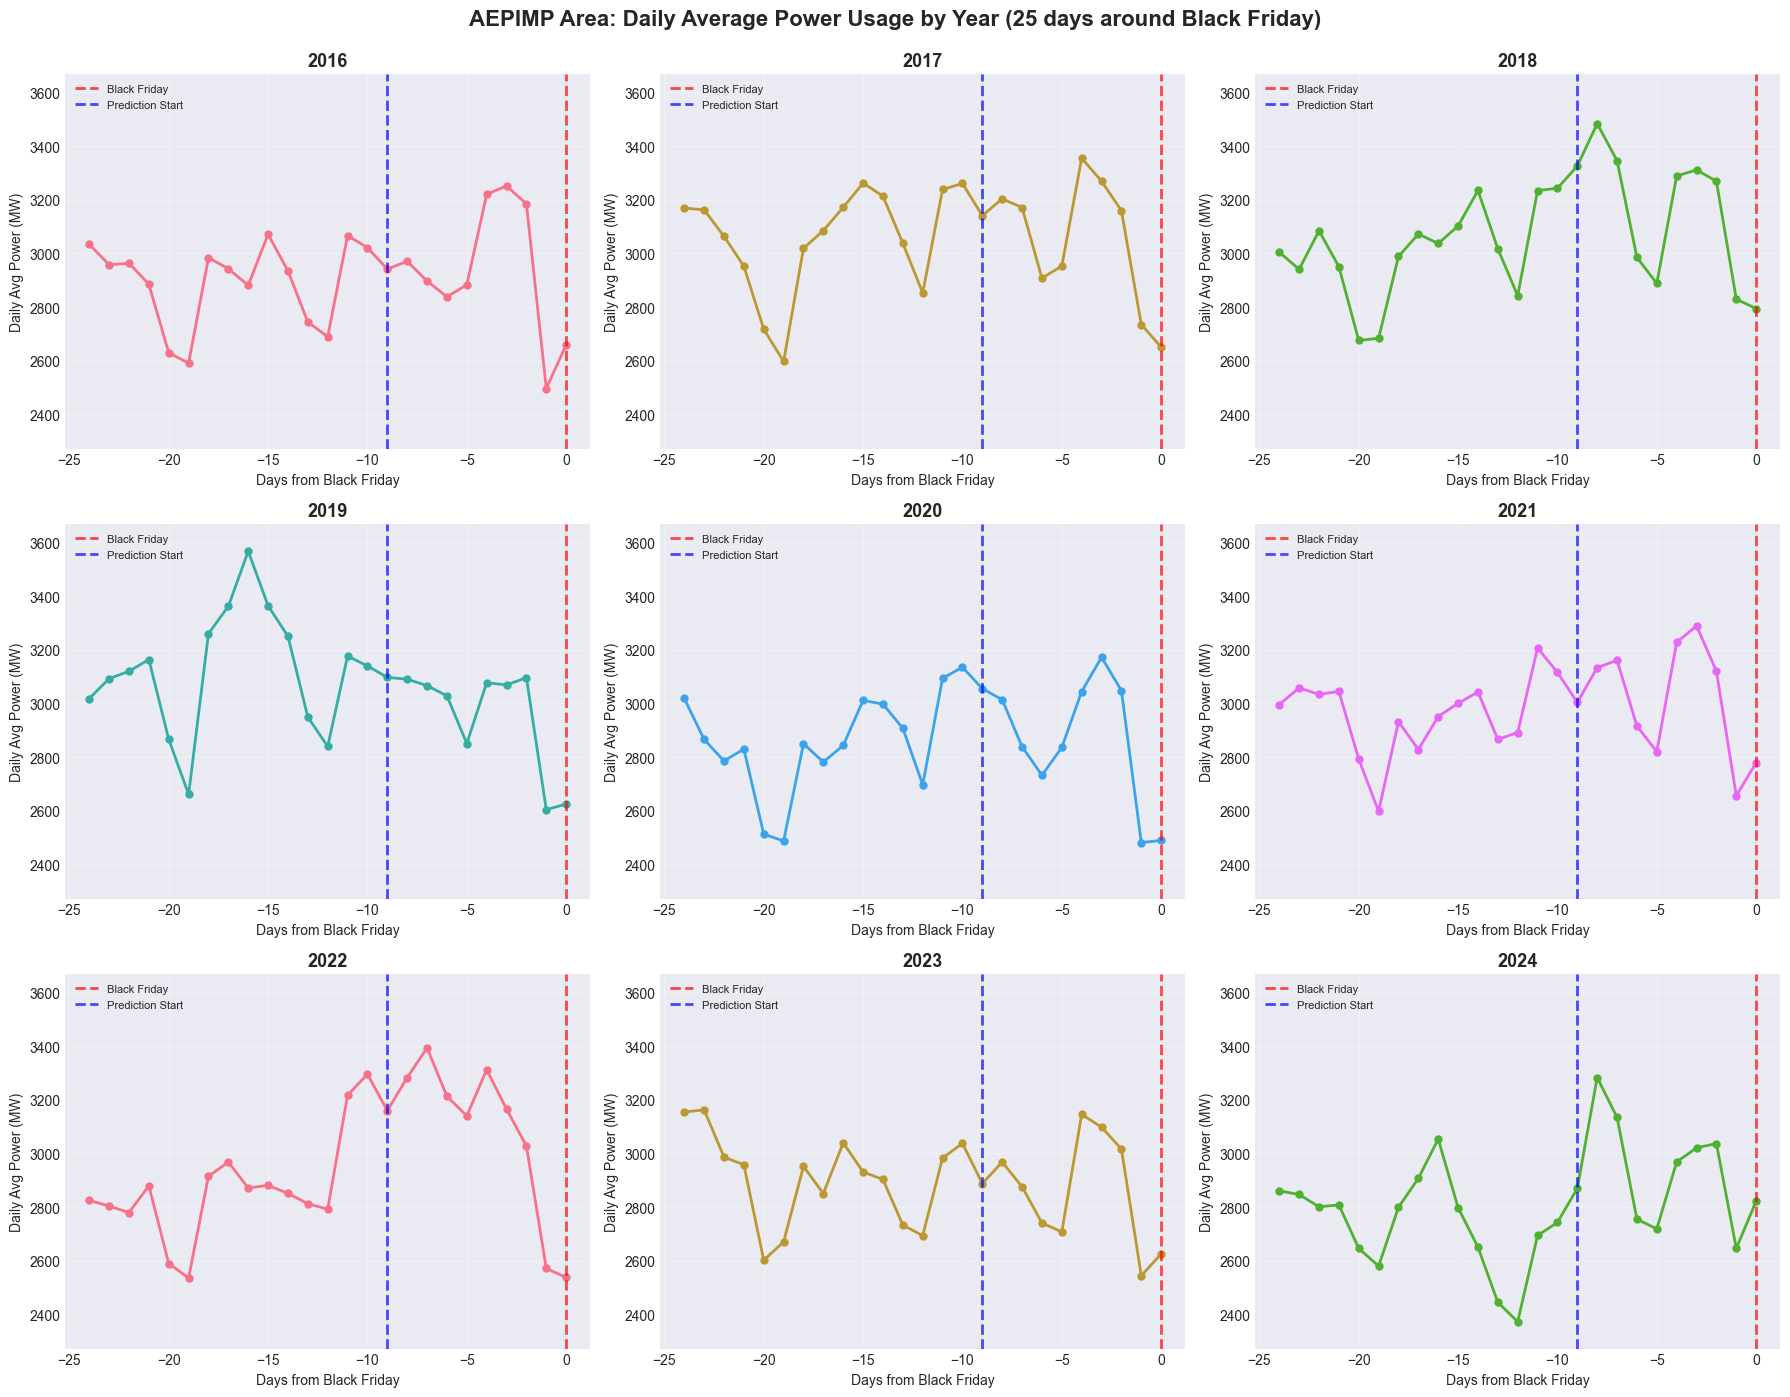


Total data for AEPIMP: 5,406 rows

Data count by year:
year
2016    601
2017    601
2018    601
2019    600
2020    600
2021    601
2022    601
2023    601
2024    600
dtype: int64


In [54]:
# Visualize AEPIMP area
plot_daily_avg_by_year(combined_df, 'AEPIMP')

## Generate Plots for All Load Areas

In [55]:
# Get all unique load areas
all_load_areas = sorted(combined_df['load_area'].unique())
print(f"Total load areas: {len(all_load_areas)}")
print(f"Load areas: {all_load_areas}")

Total load areas: 31
Load areas: ['AE', 'AECO', 'AEPAPT', 'AEPIMP', 'AEPKPT', 'AEPOPT', 'AP', 'BC', 'CE', 'DAY', 'DEOK', 'DOM', 'DPLCO', 'DUQ', 'EASTON', 'EKPC', 'JC', 'ME', 'OE', 'OVEC', 'PAPWR', 'PE', 'PEPCO', 'PLCO', 'PN', 'PS', 'RECO', 'RTO', 'SMECO', 'UGI', 'VMEU']



Processing: AE


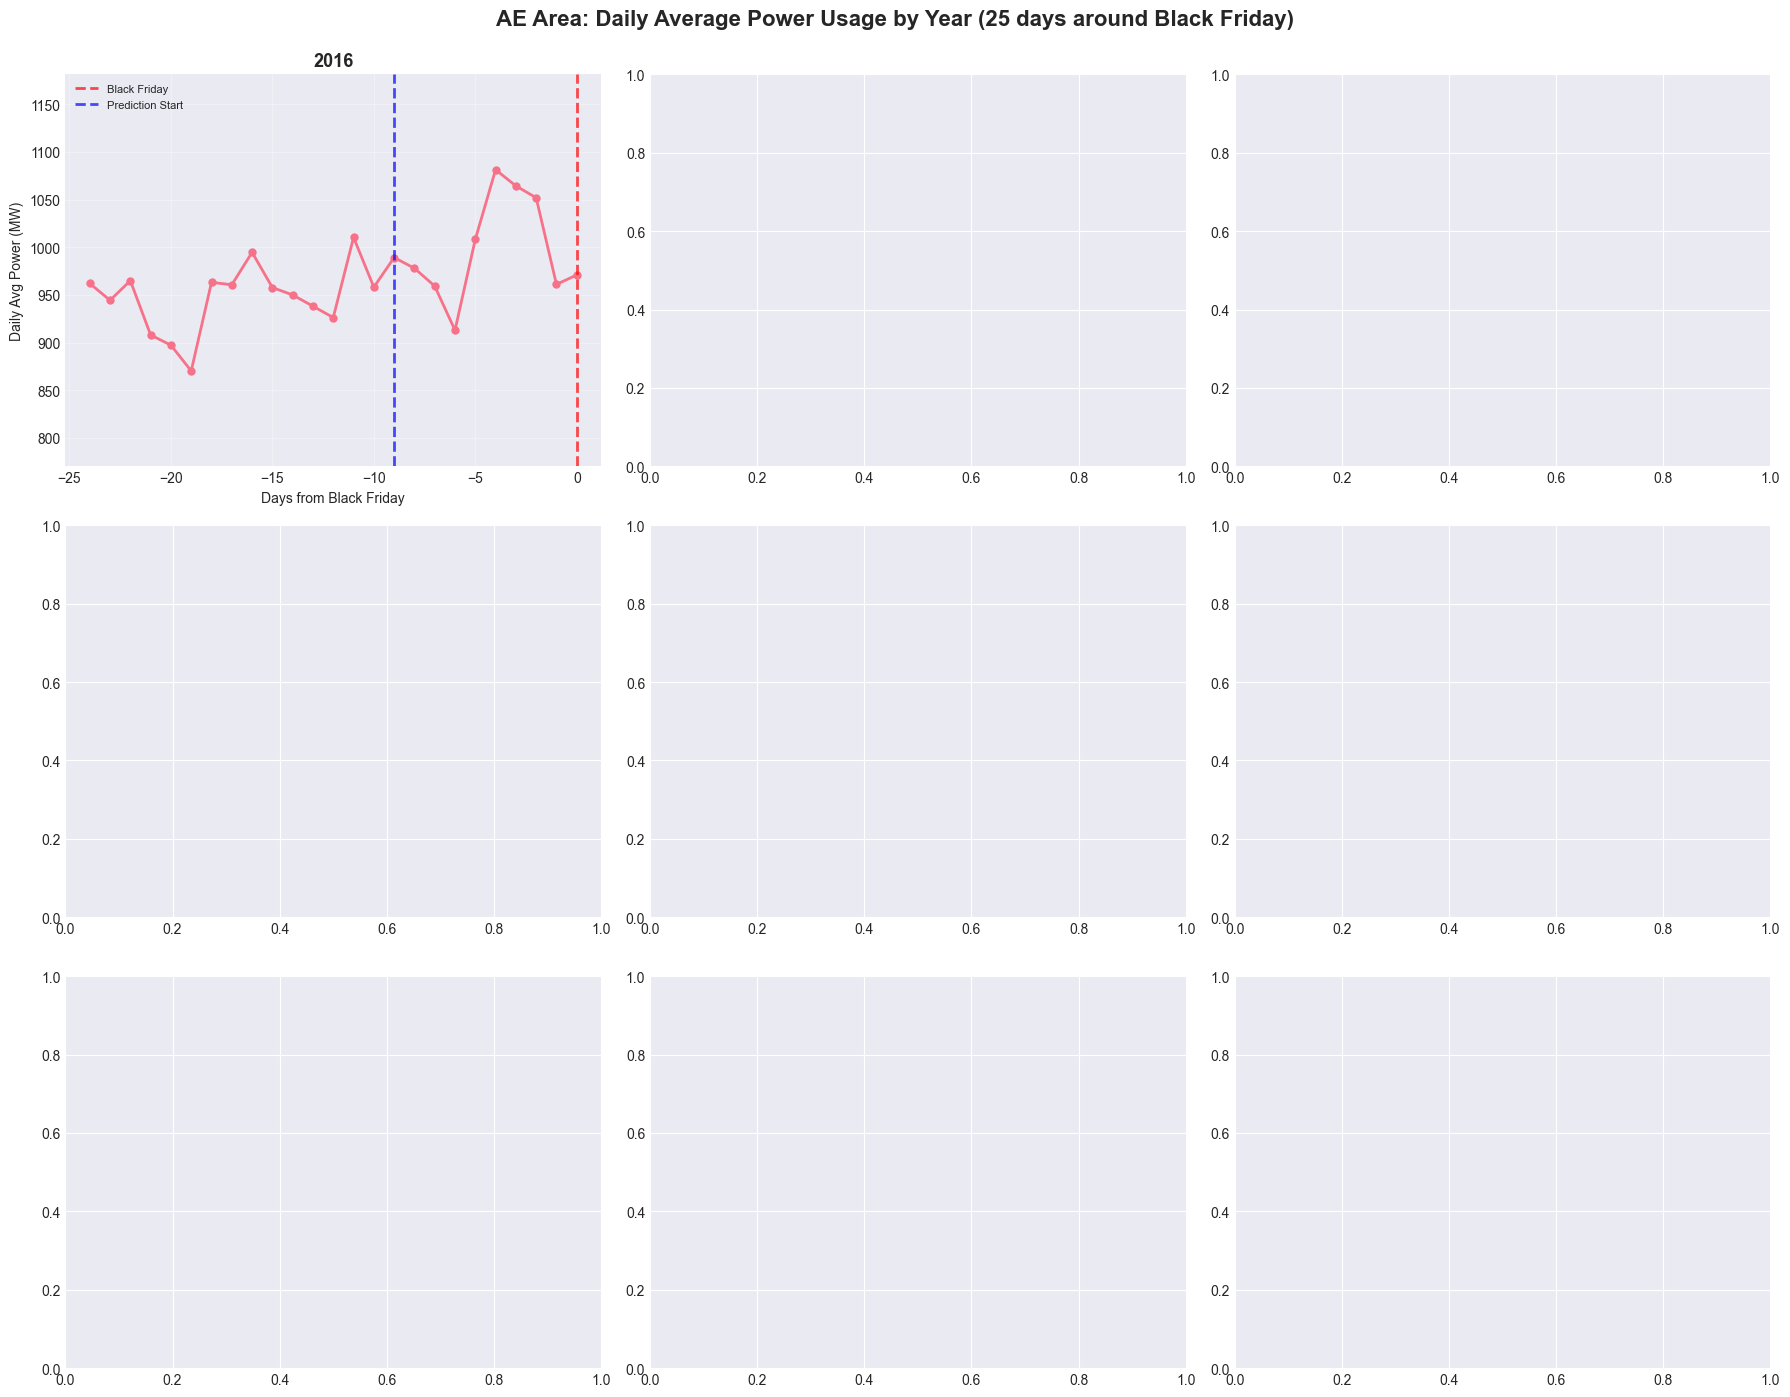


Total data for AE: 601 rows

Data count by year:
year
2016    601
dtype: int64

Processing: AECO


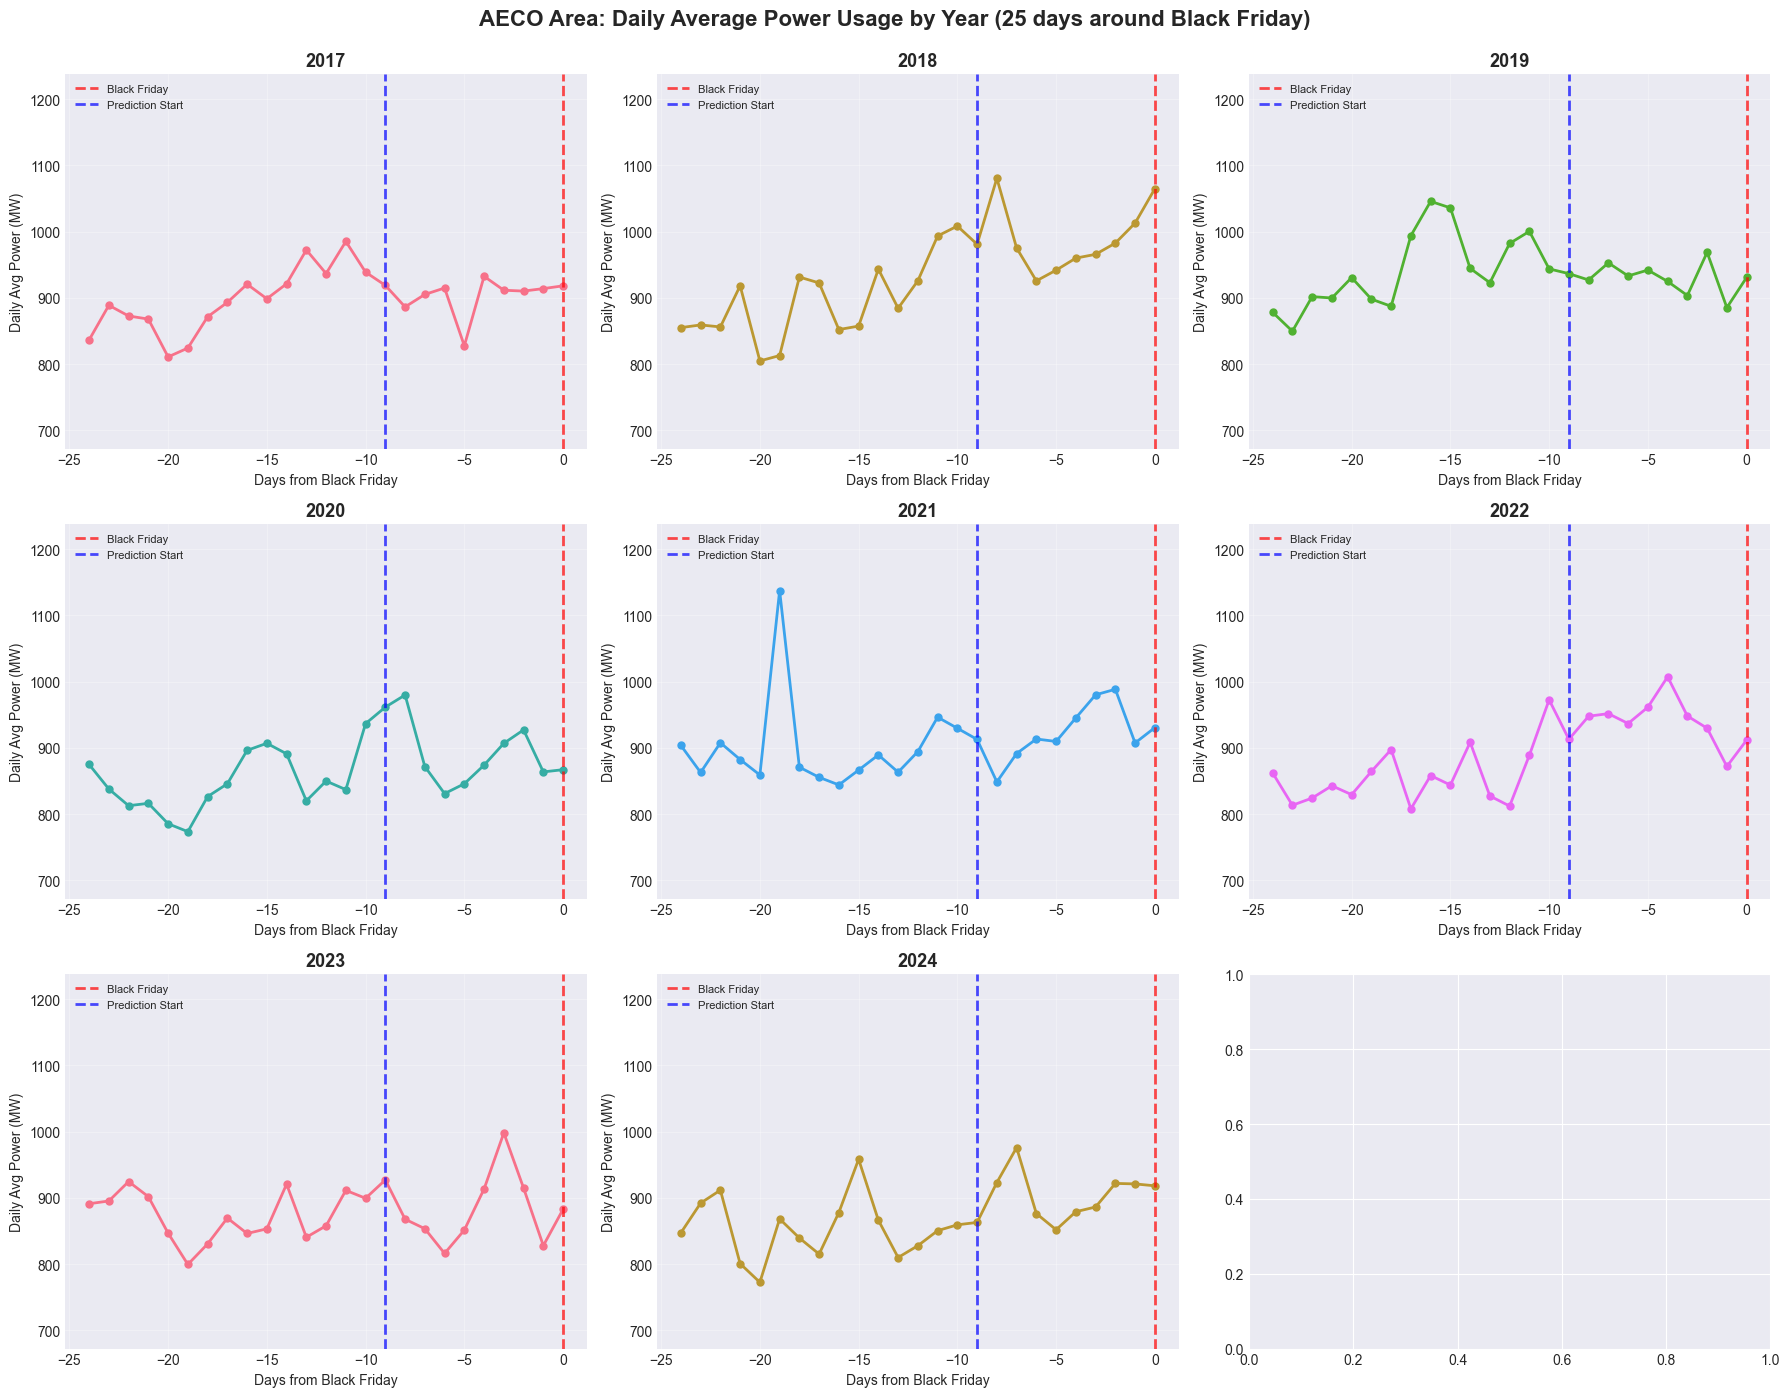


Total data for AECO: 4,805 rows

Data count by year:
year
2017    601
2018    601
2019    600
2020    600
2021    601
2022    601
2023    601
2024    600
dtype: int64

Processing: AEPAPT


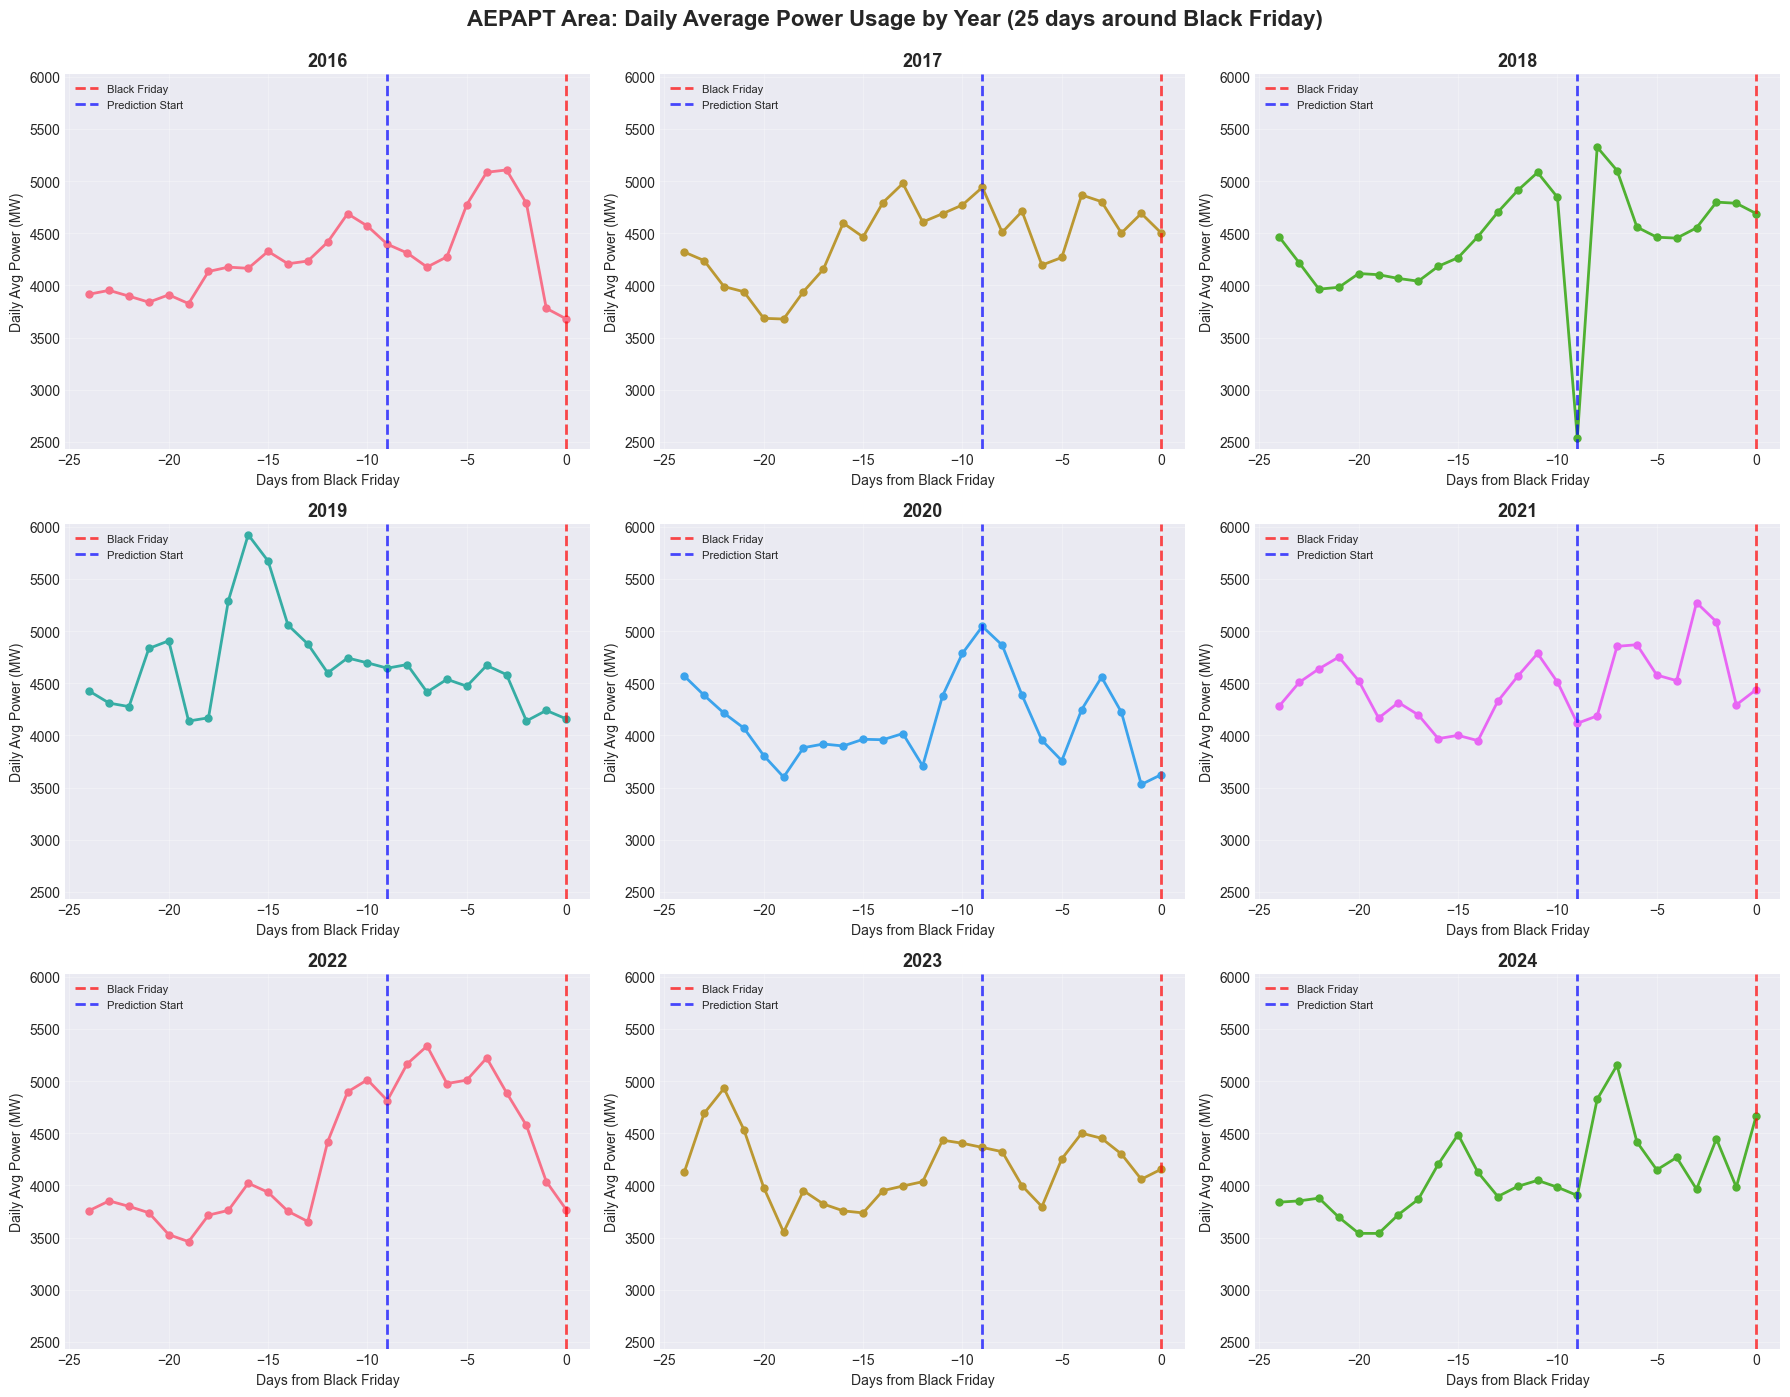


Total data for AEPAPT: 5,406 rows

Data count by year:
year
2016    601
2017    601
2018    601
2019    600
2020    600
2021    601
2022    601
2023    601
2024    600
dtype: int64

Processing: AEPIMP


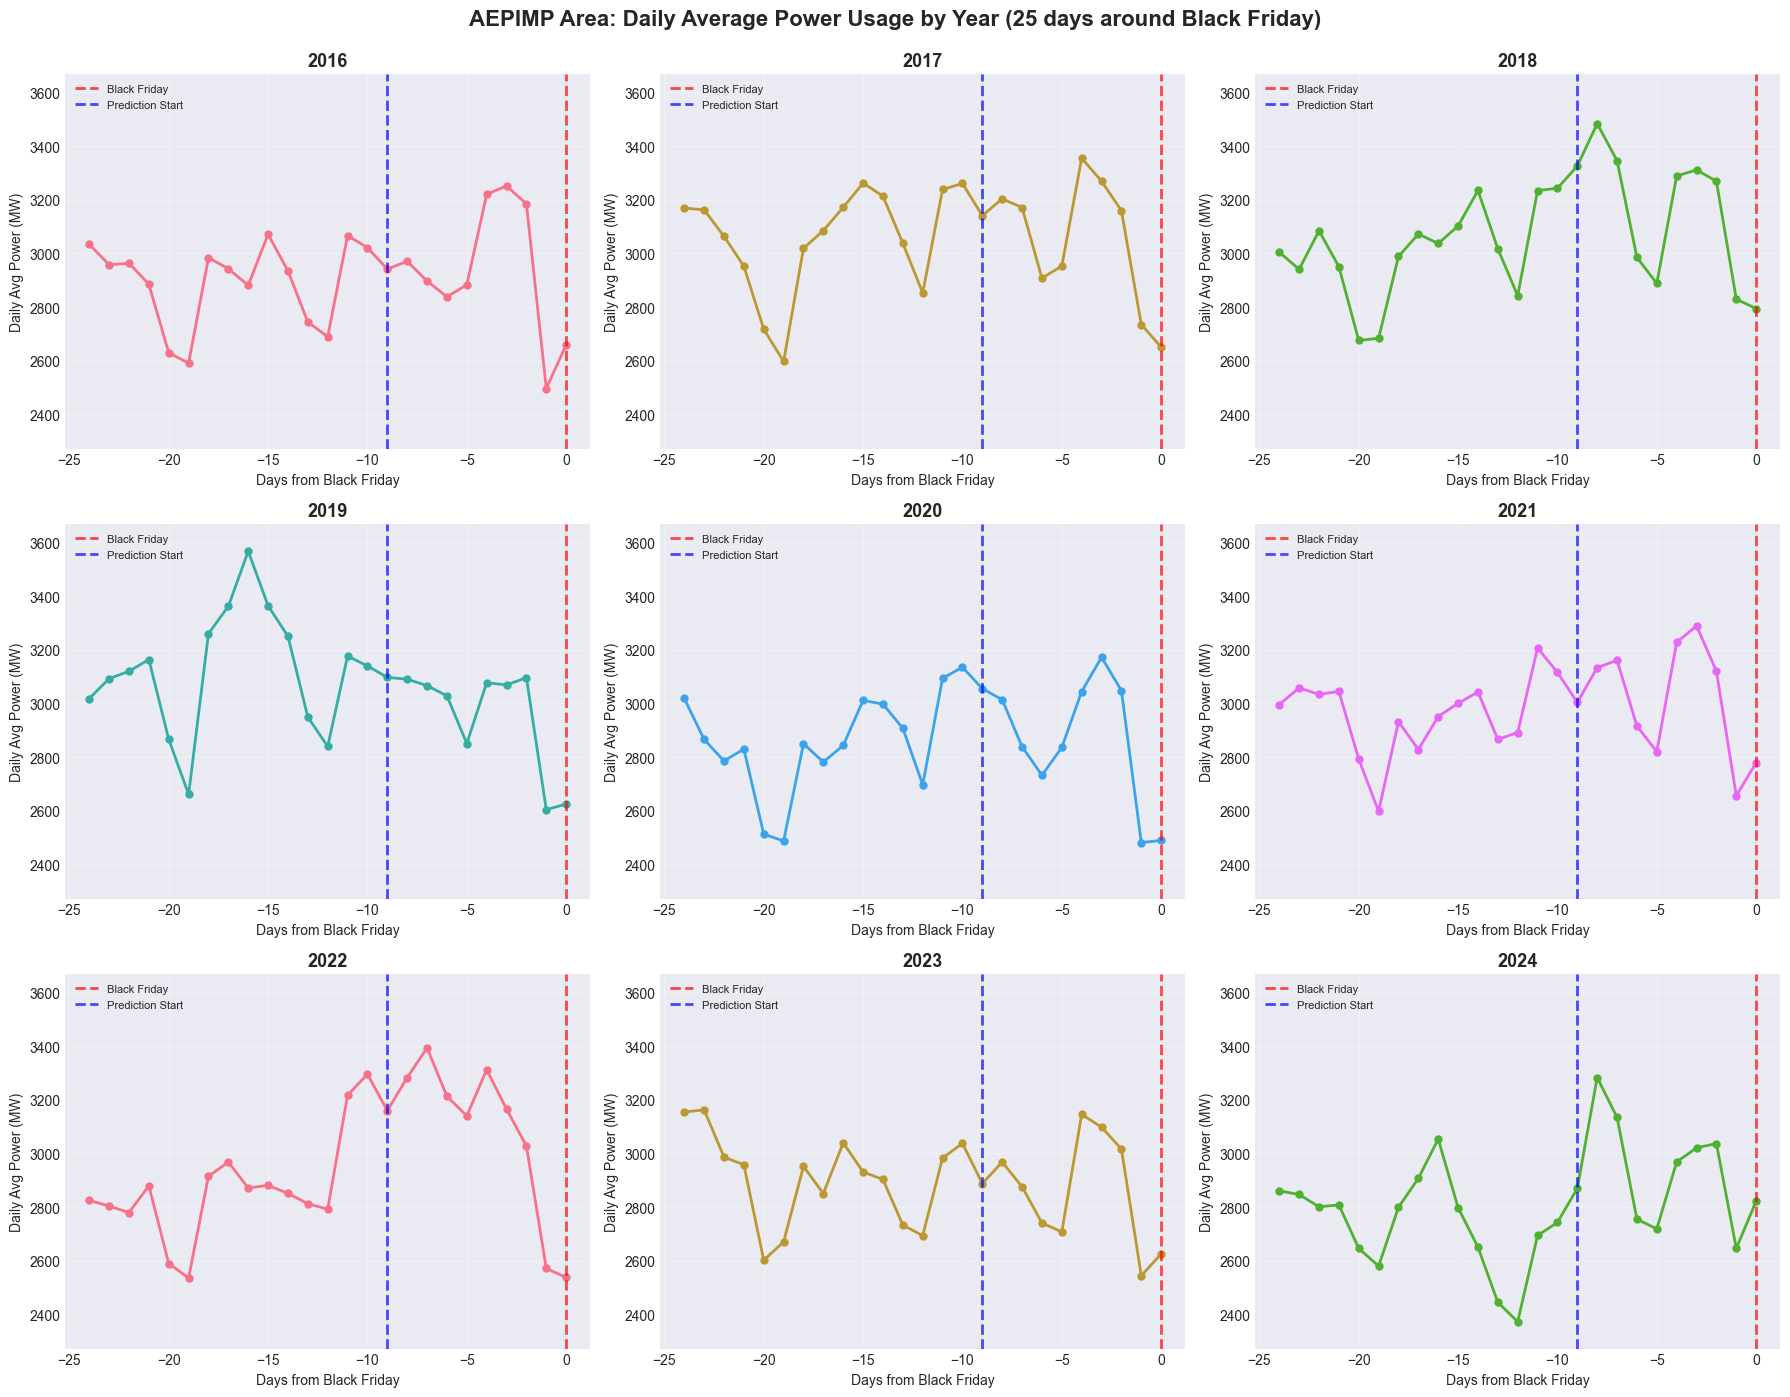


Total data for AEPIMP: 5,406 rows

Data count by year:
year
2016    601
2017    601
2018    601
2019    600
2020    600
2021    601
2022    601
2023    601
2024    600
dtype: int64

Processing: AEPKPT


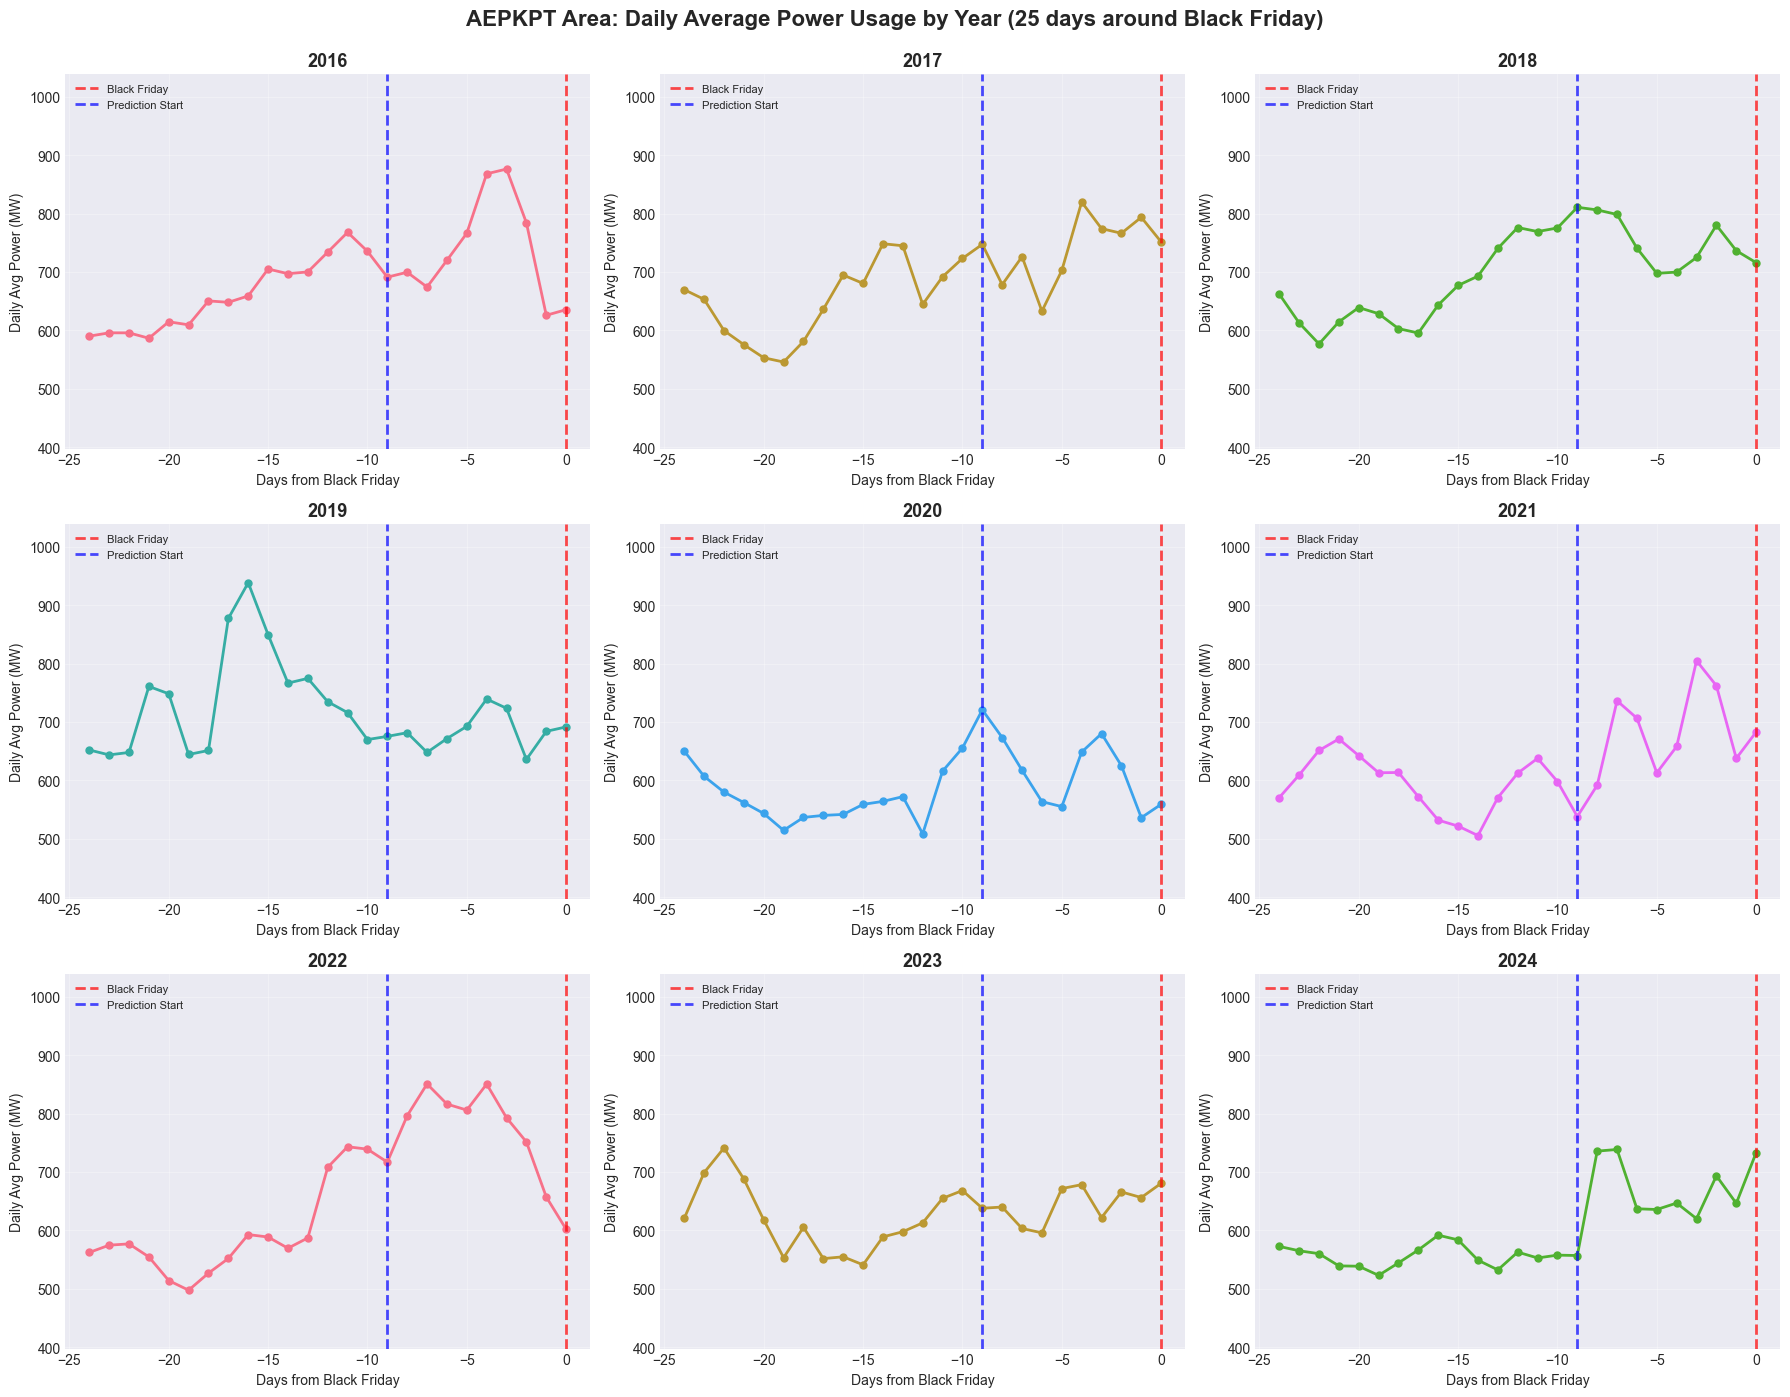


Total data for AEPKPT: 5,406 rows

Data count by year:
year
2016    601
2017    601
2018    601
2019    600
2020    600
2021    601
2022    601
2023    601
2024    600
dtype: int64

Processing: AEPOPT


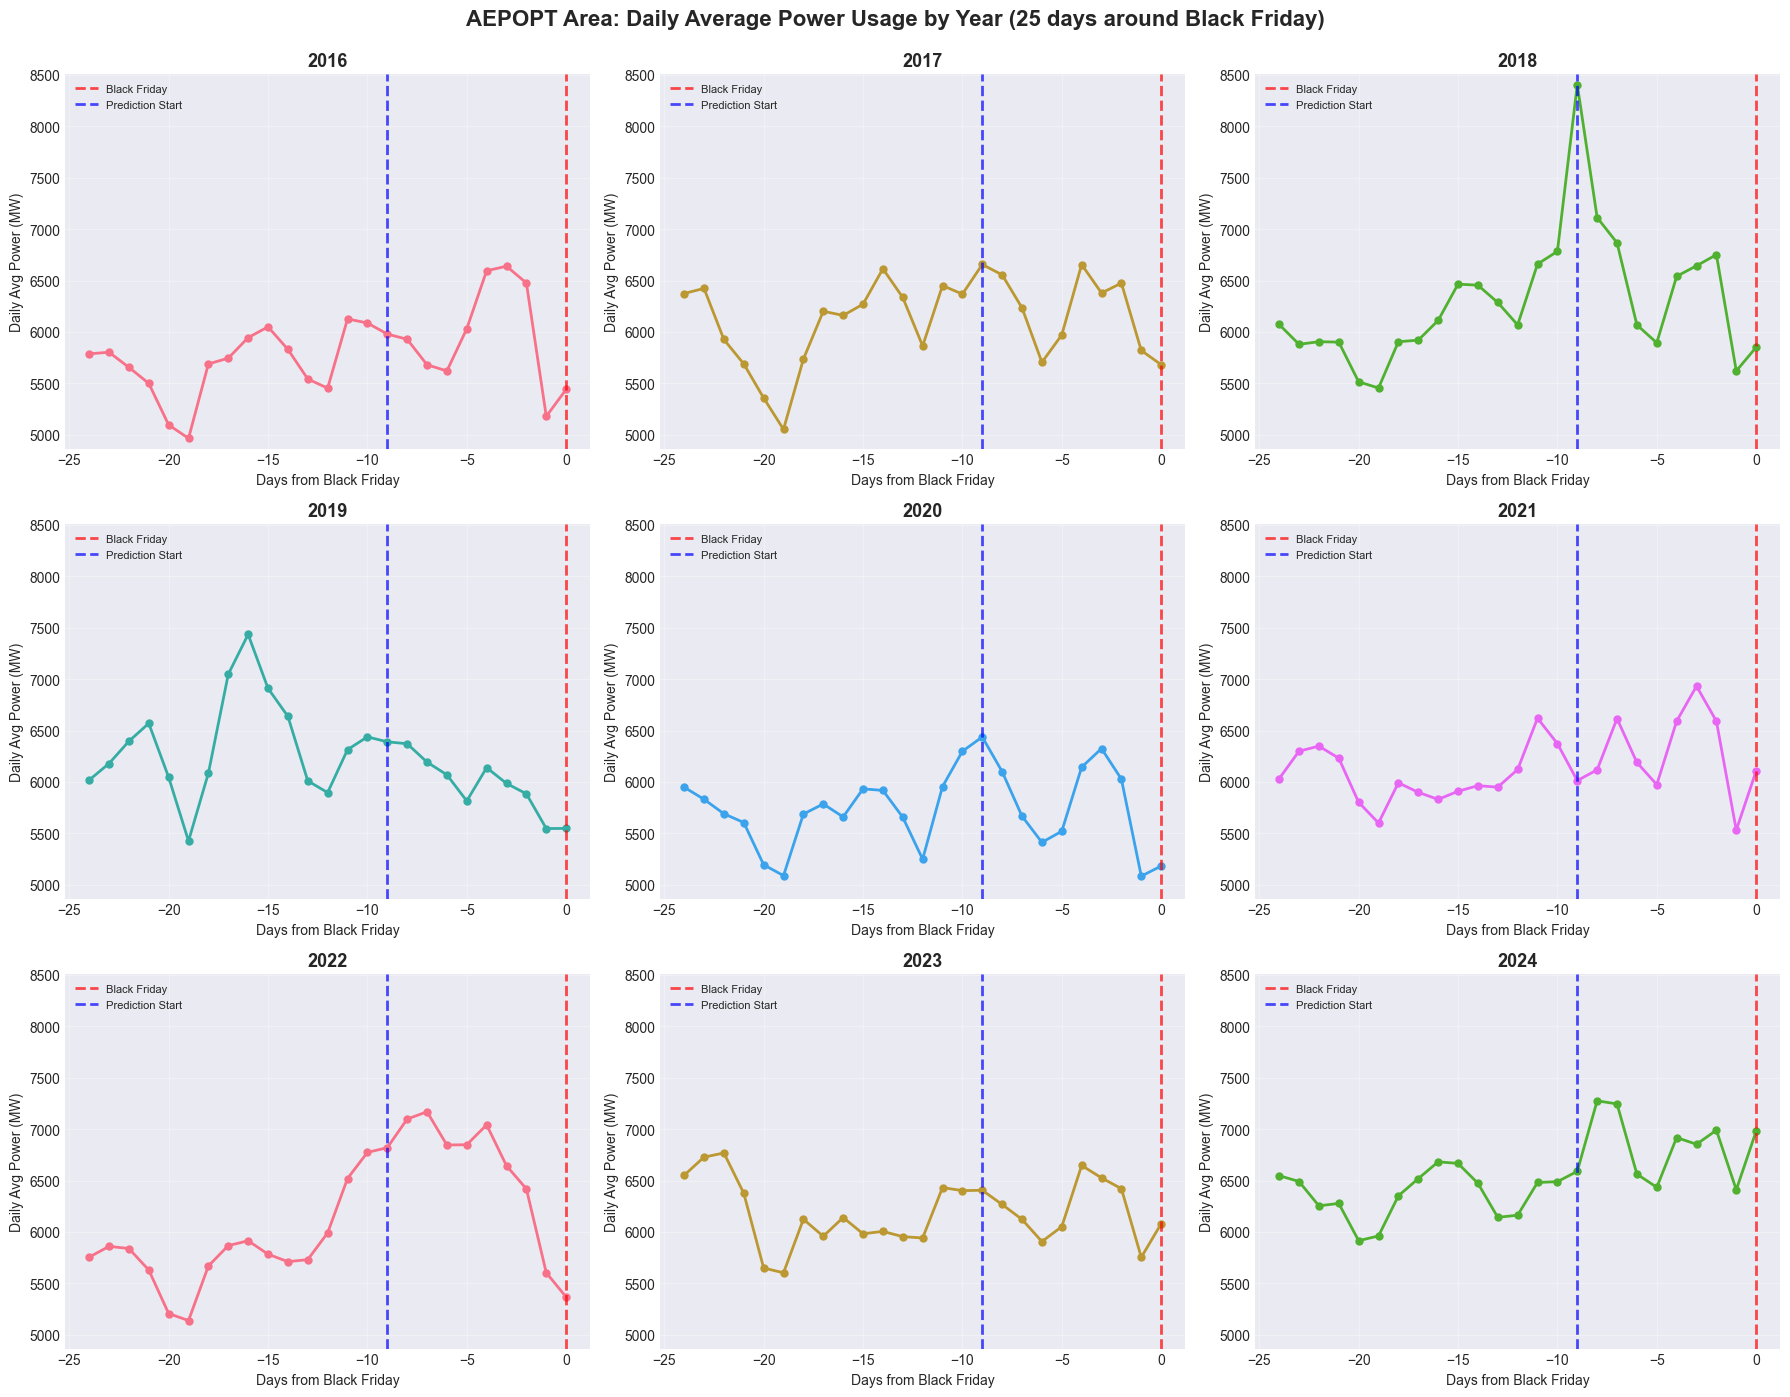


Total data for AEPOPT: 5,406 rows

Data count by year:
year
2016    601
2017    601
2018    601
2019    600
2020    600
2021    601
2022    601
2023    601
2024    600
dtype: int64

Processing: AP


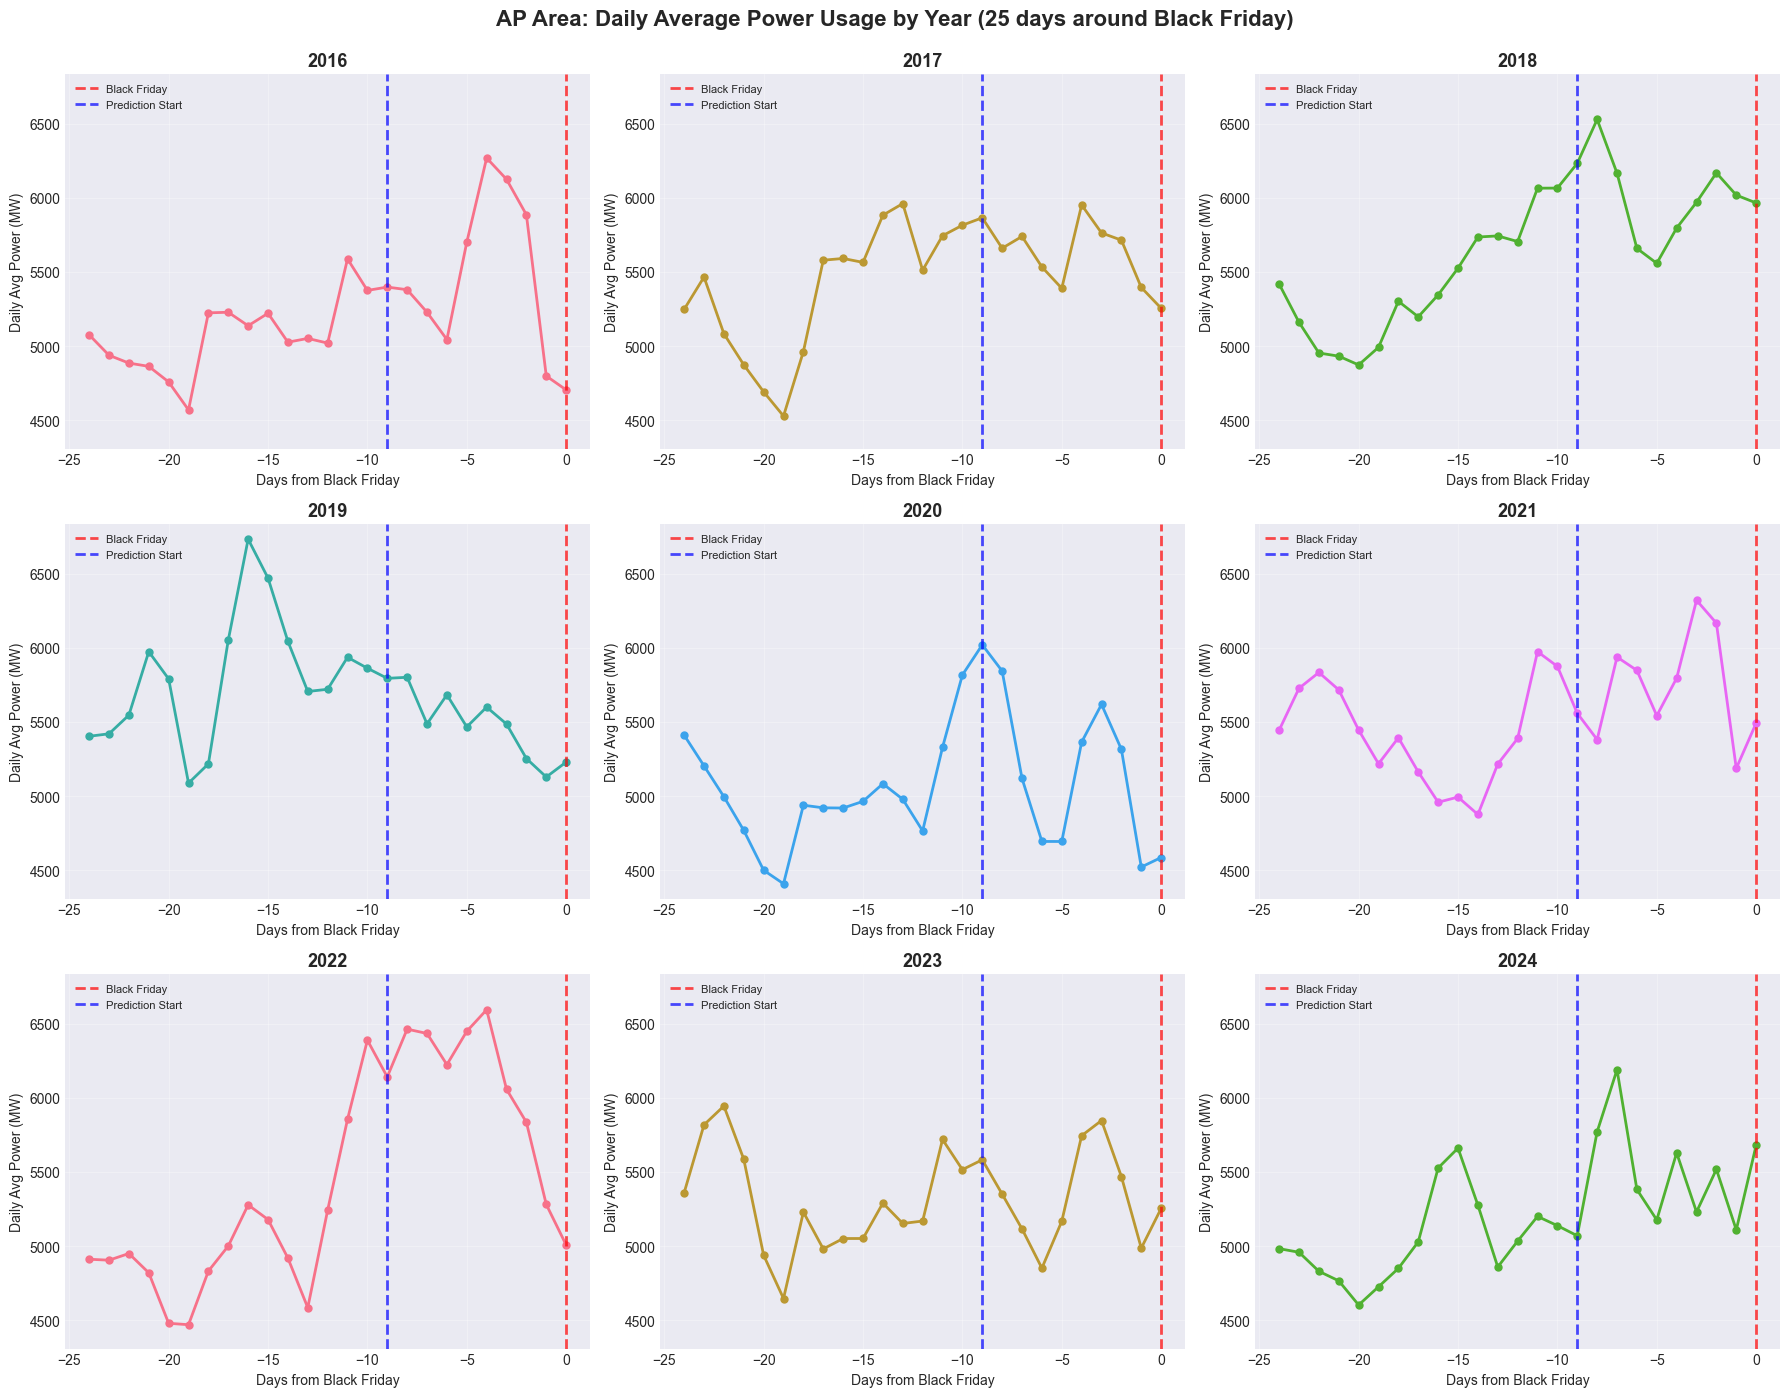


Total data for AP: 5,406 rows

Data count by year:
year
2016    601
2017    601
2018    601
2019    600
2020    600
2021    601
2022    601
2023    601
2024    600
dtype: int64

Processing: BC


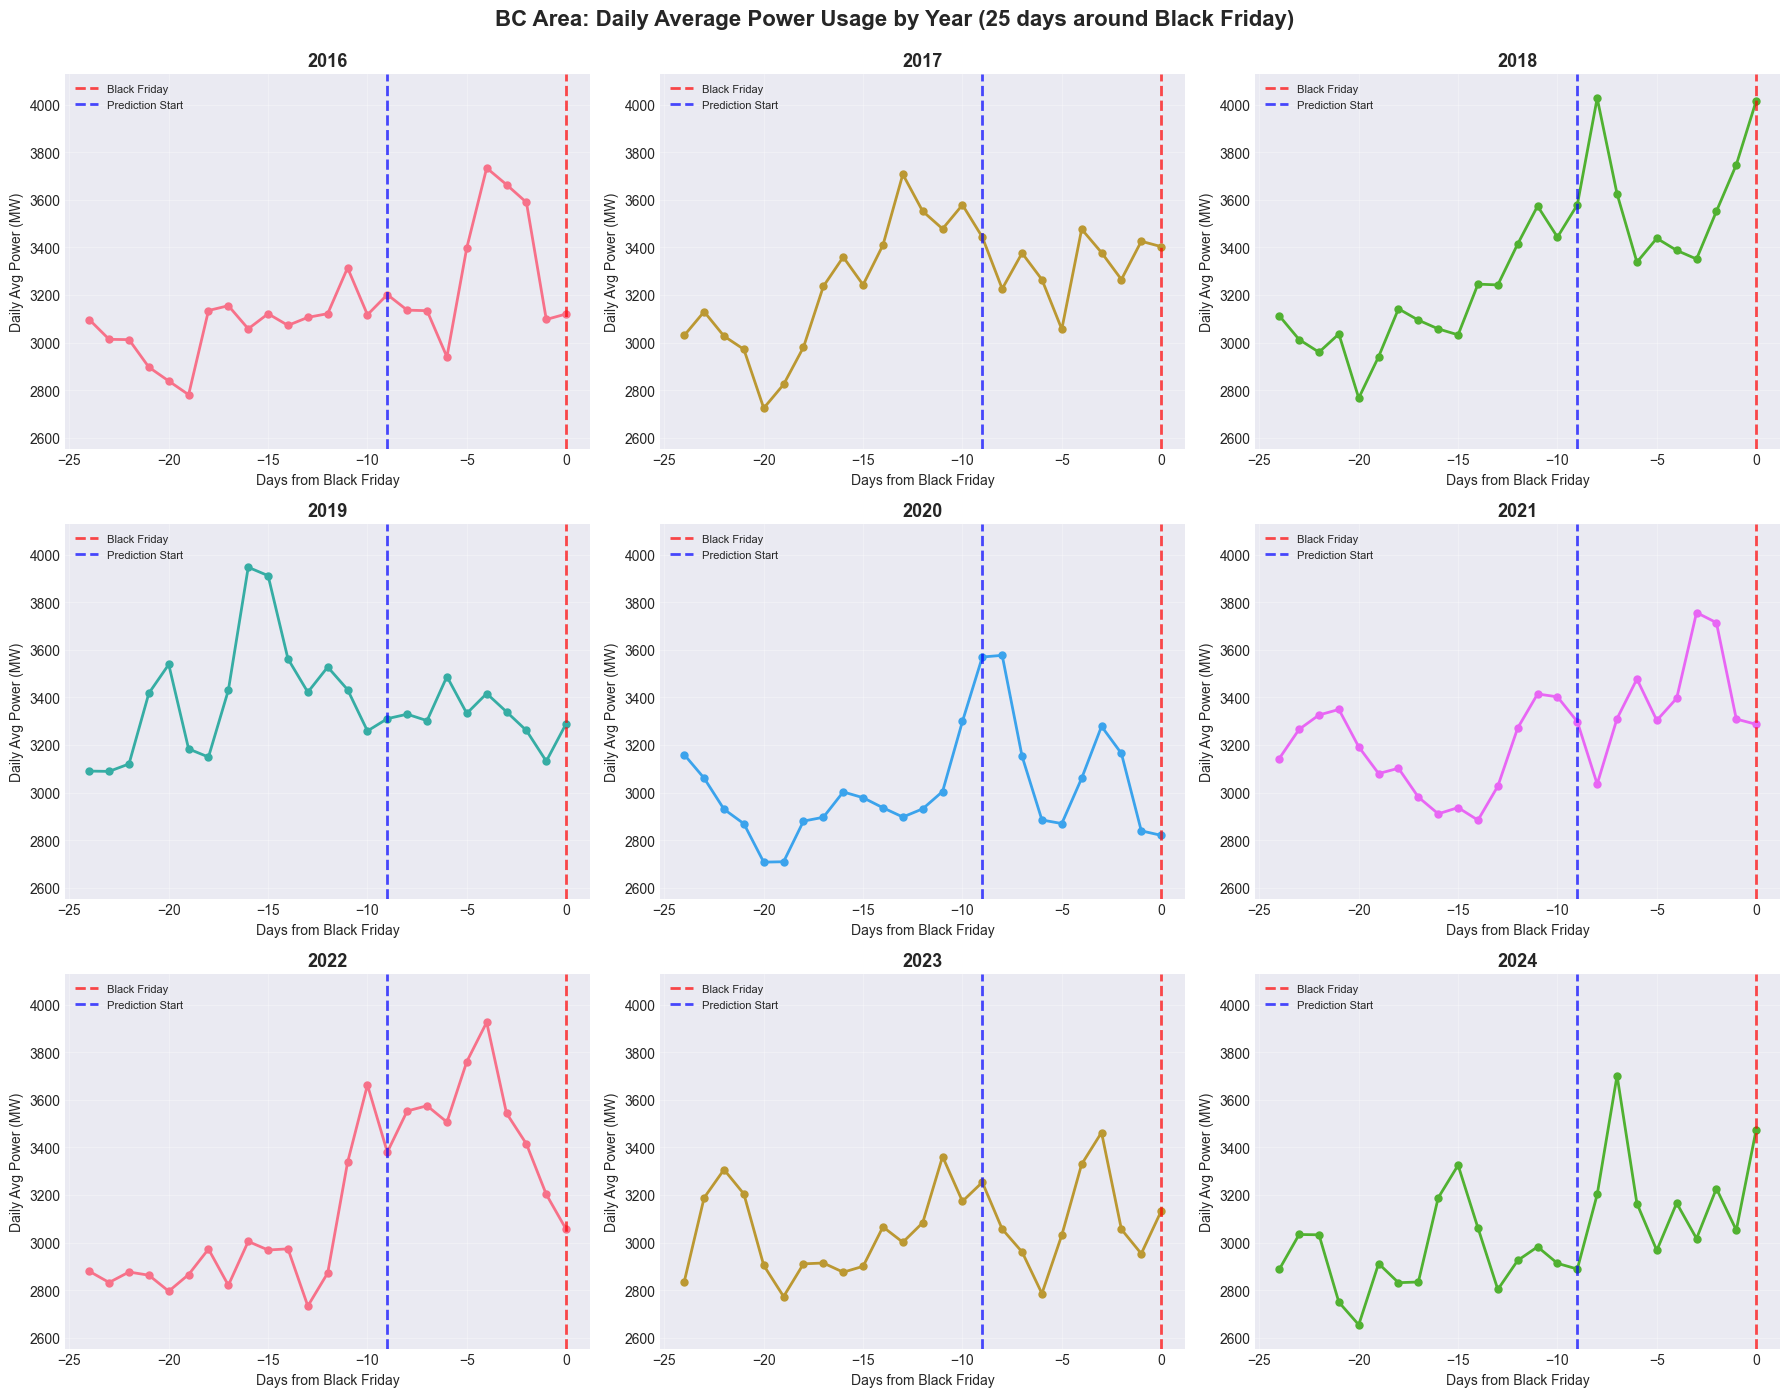


Total data for BC: 5,406 rows

Data count by year:
year
2016    601
2017    601
2018    601
2019    600
2020    600
2021    601
2022    601
2023    601
2024    600
dtype: int64

Processing: CE


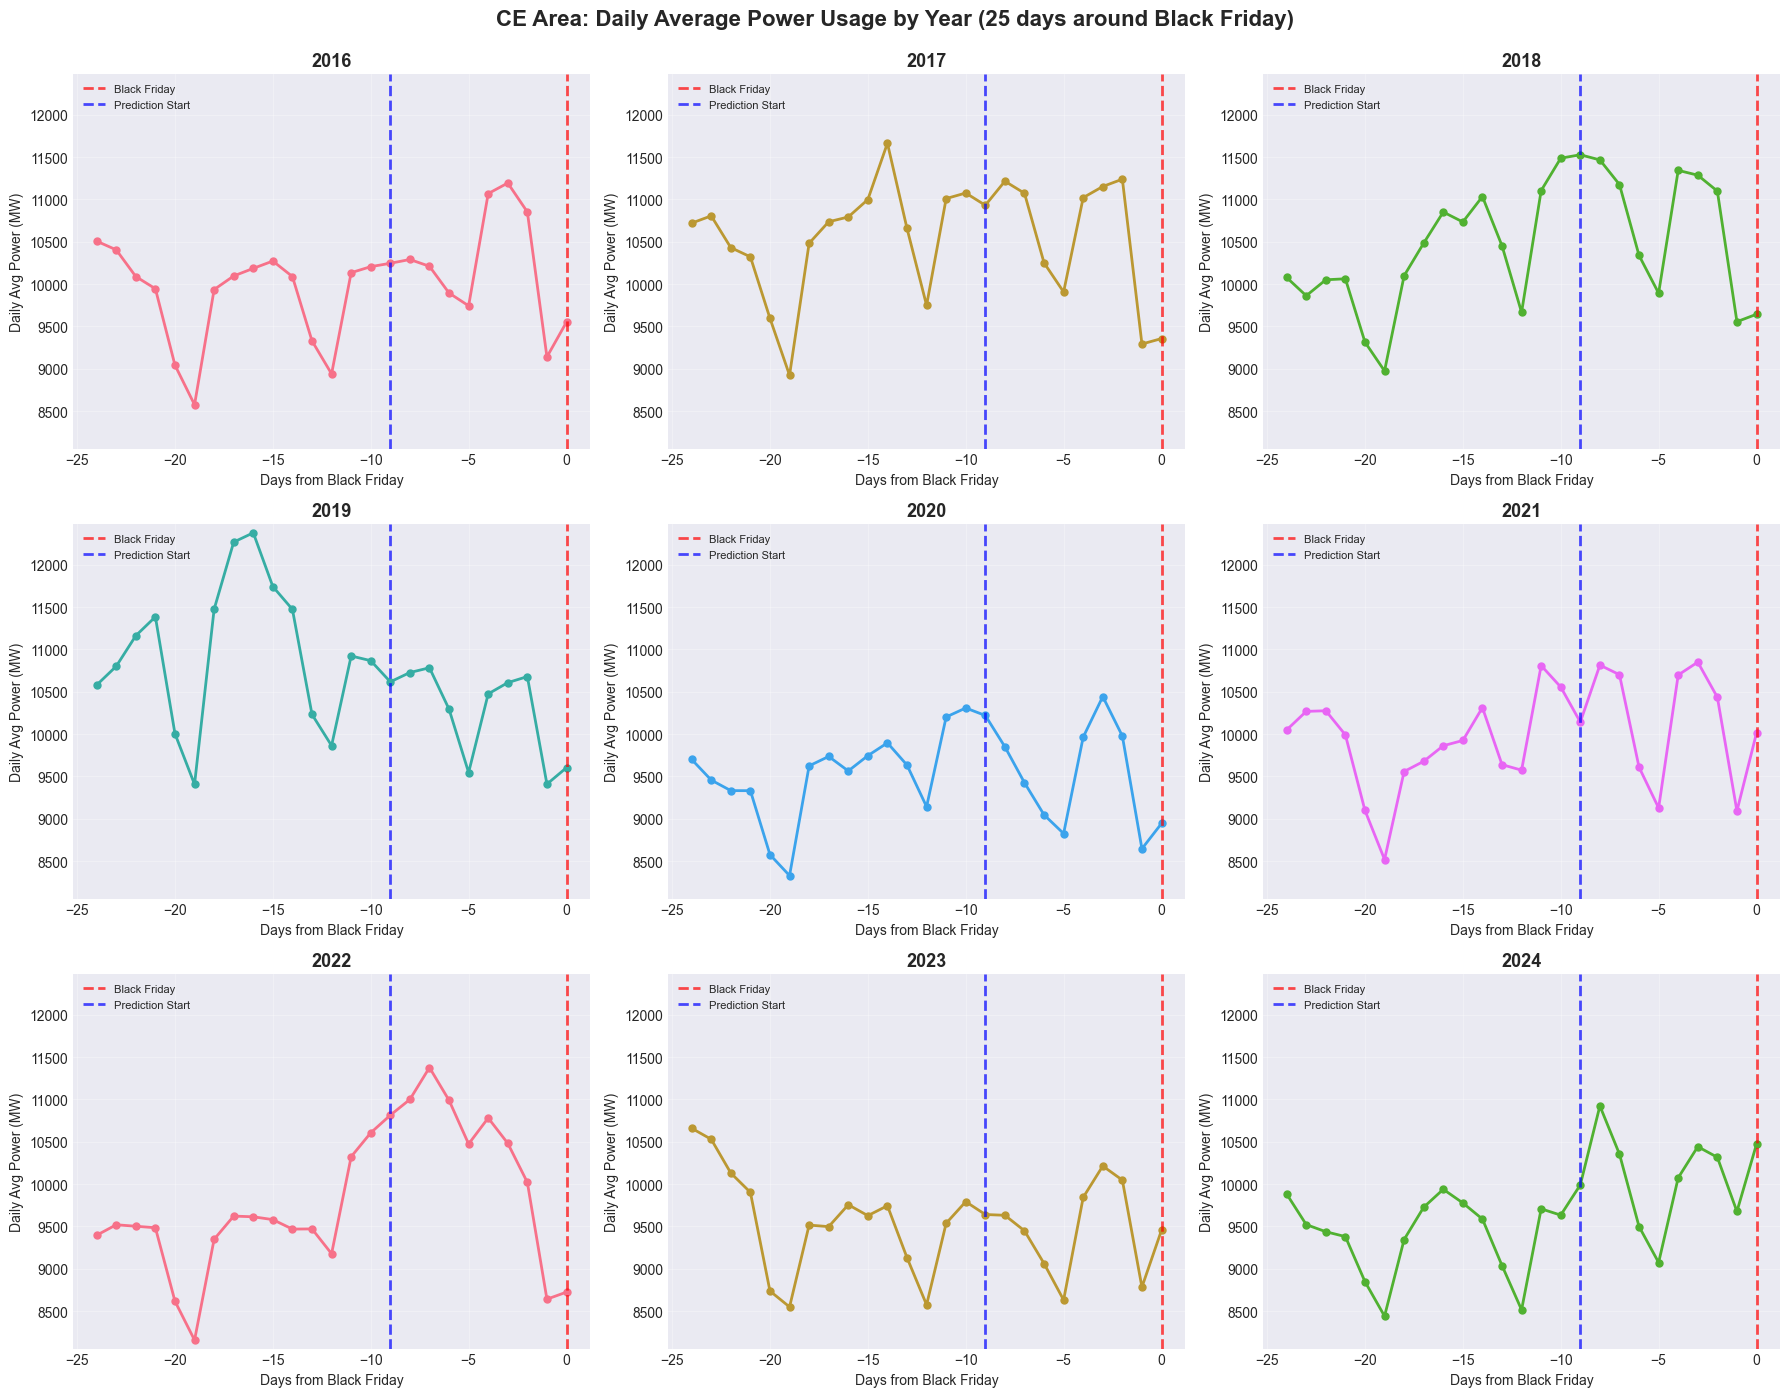


Total data for CE: 5,406 rows

Data count by year:
year
2016    601
2017    601
2018    601
2019    600
2020    600
2021    601
2022    601
2023    601
2024    600
dtype: int64

Processing: DAY


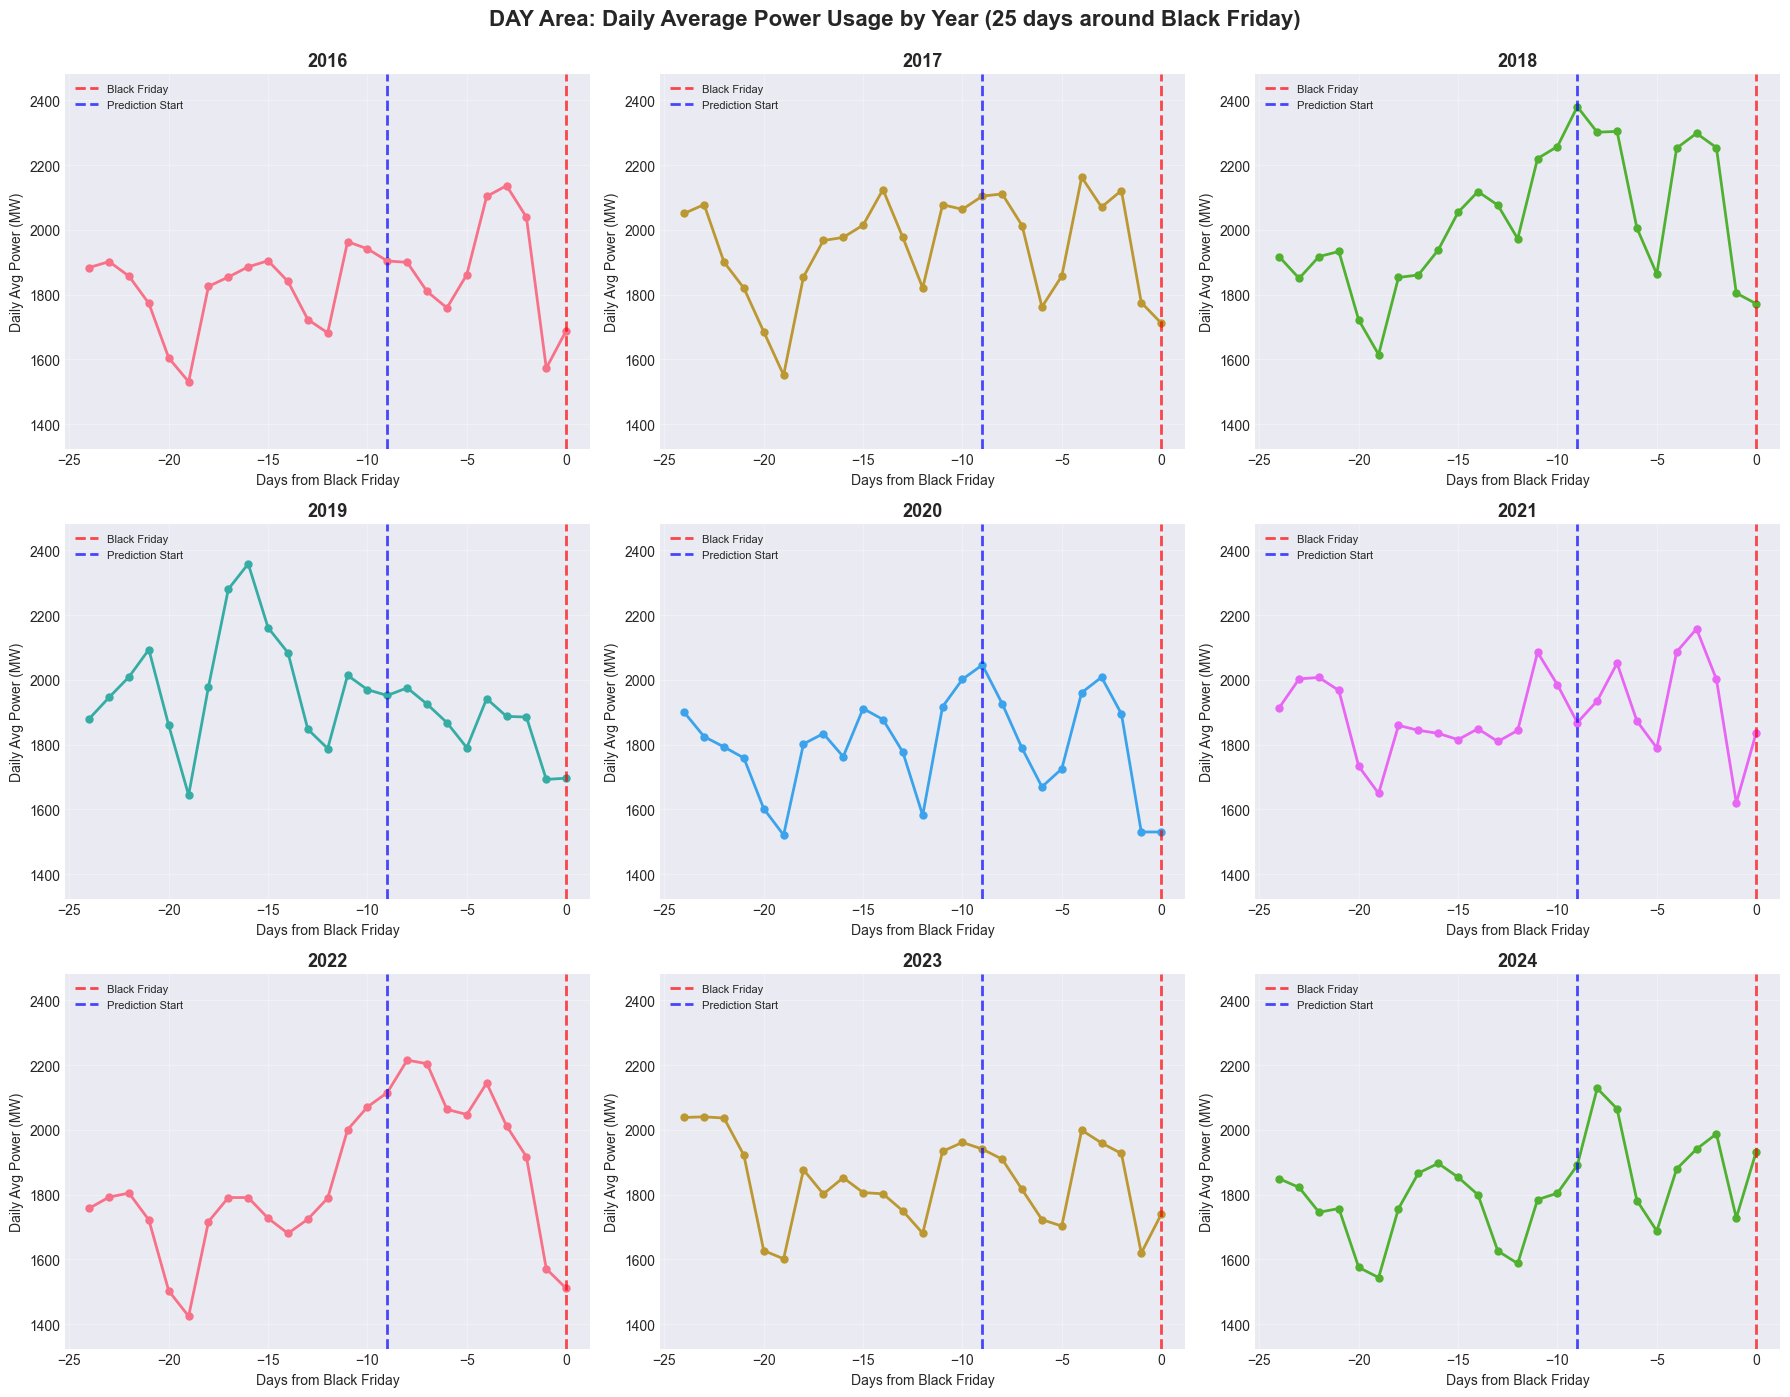


Total data for DAY: 5,406 rows

Data count by year:
year
2016    601
2017    601
2018    601
2019    600
2020    600
2021    601
2022    601
2023    601
2024    600
dtype: int64

Processing: DEOK


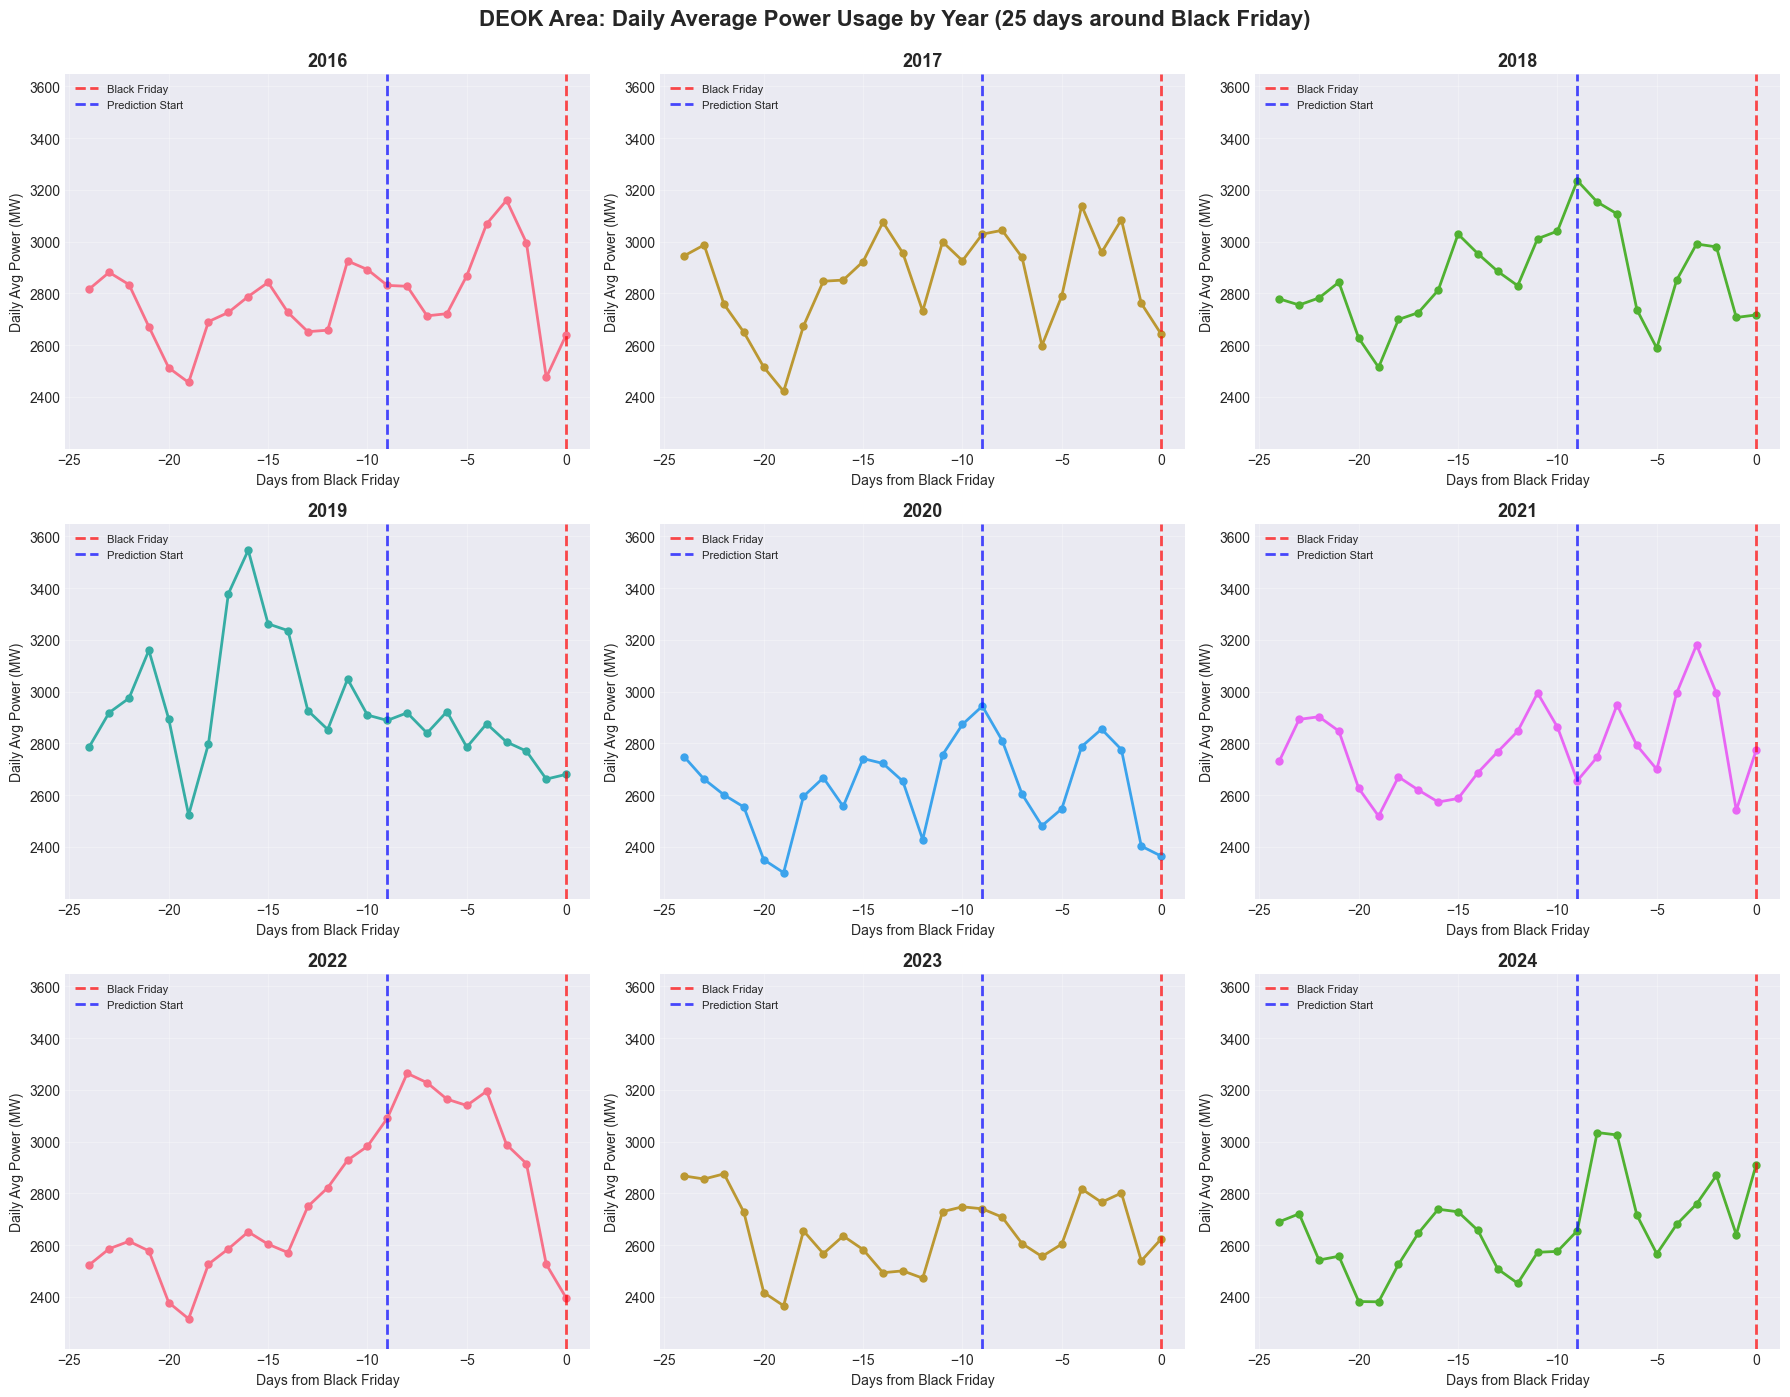


Total data for DEOK: 5,406 rows

Data count by year:
year
2016    601
2017    601
2018    601
2019    600
2020    600
2021    601
2022    601
2023    601
2024    600
dtype: int64

Processing: DOM


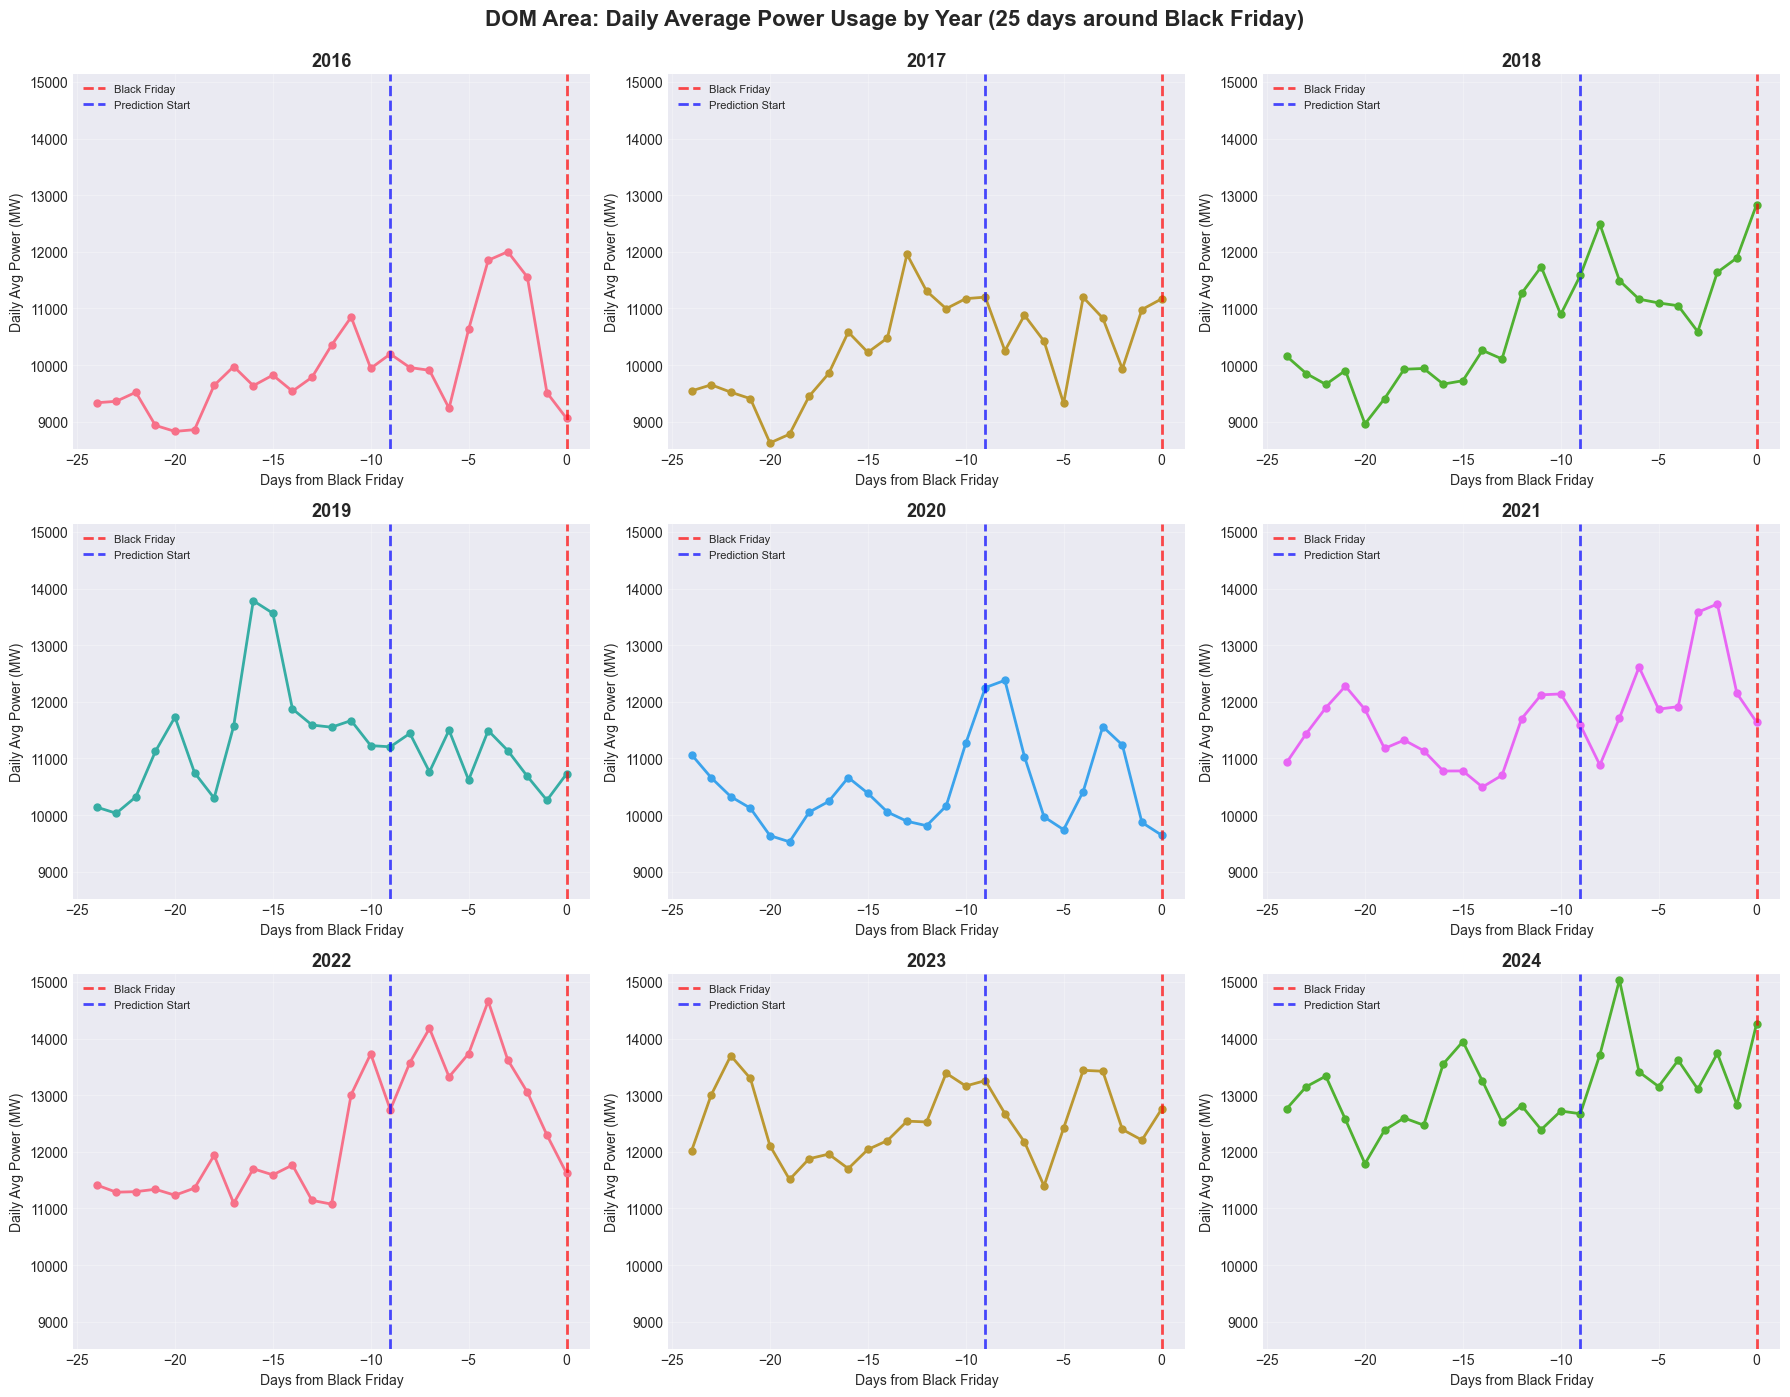


Total data for DOM: 5,406 rows

Data count by year:
year
2016    601
2017    601
2018    601
2019    600
2020    600
2021    601
2022    601
2023    601
2024    600
dtype: int64

Processing: DPLCO


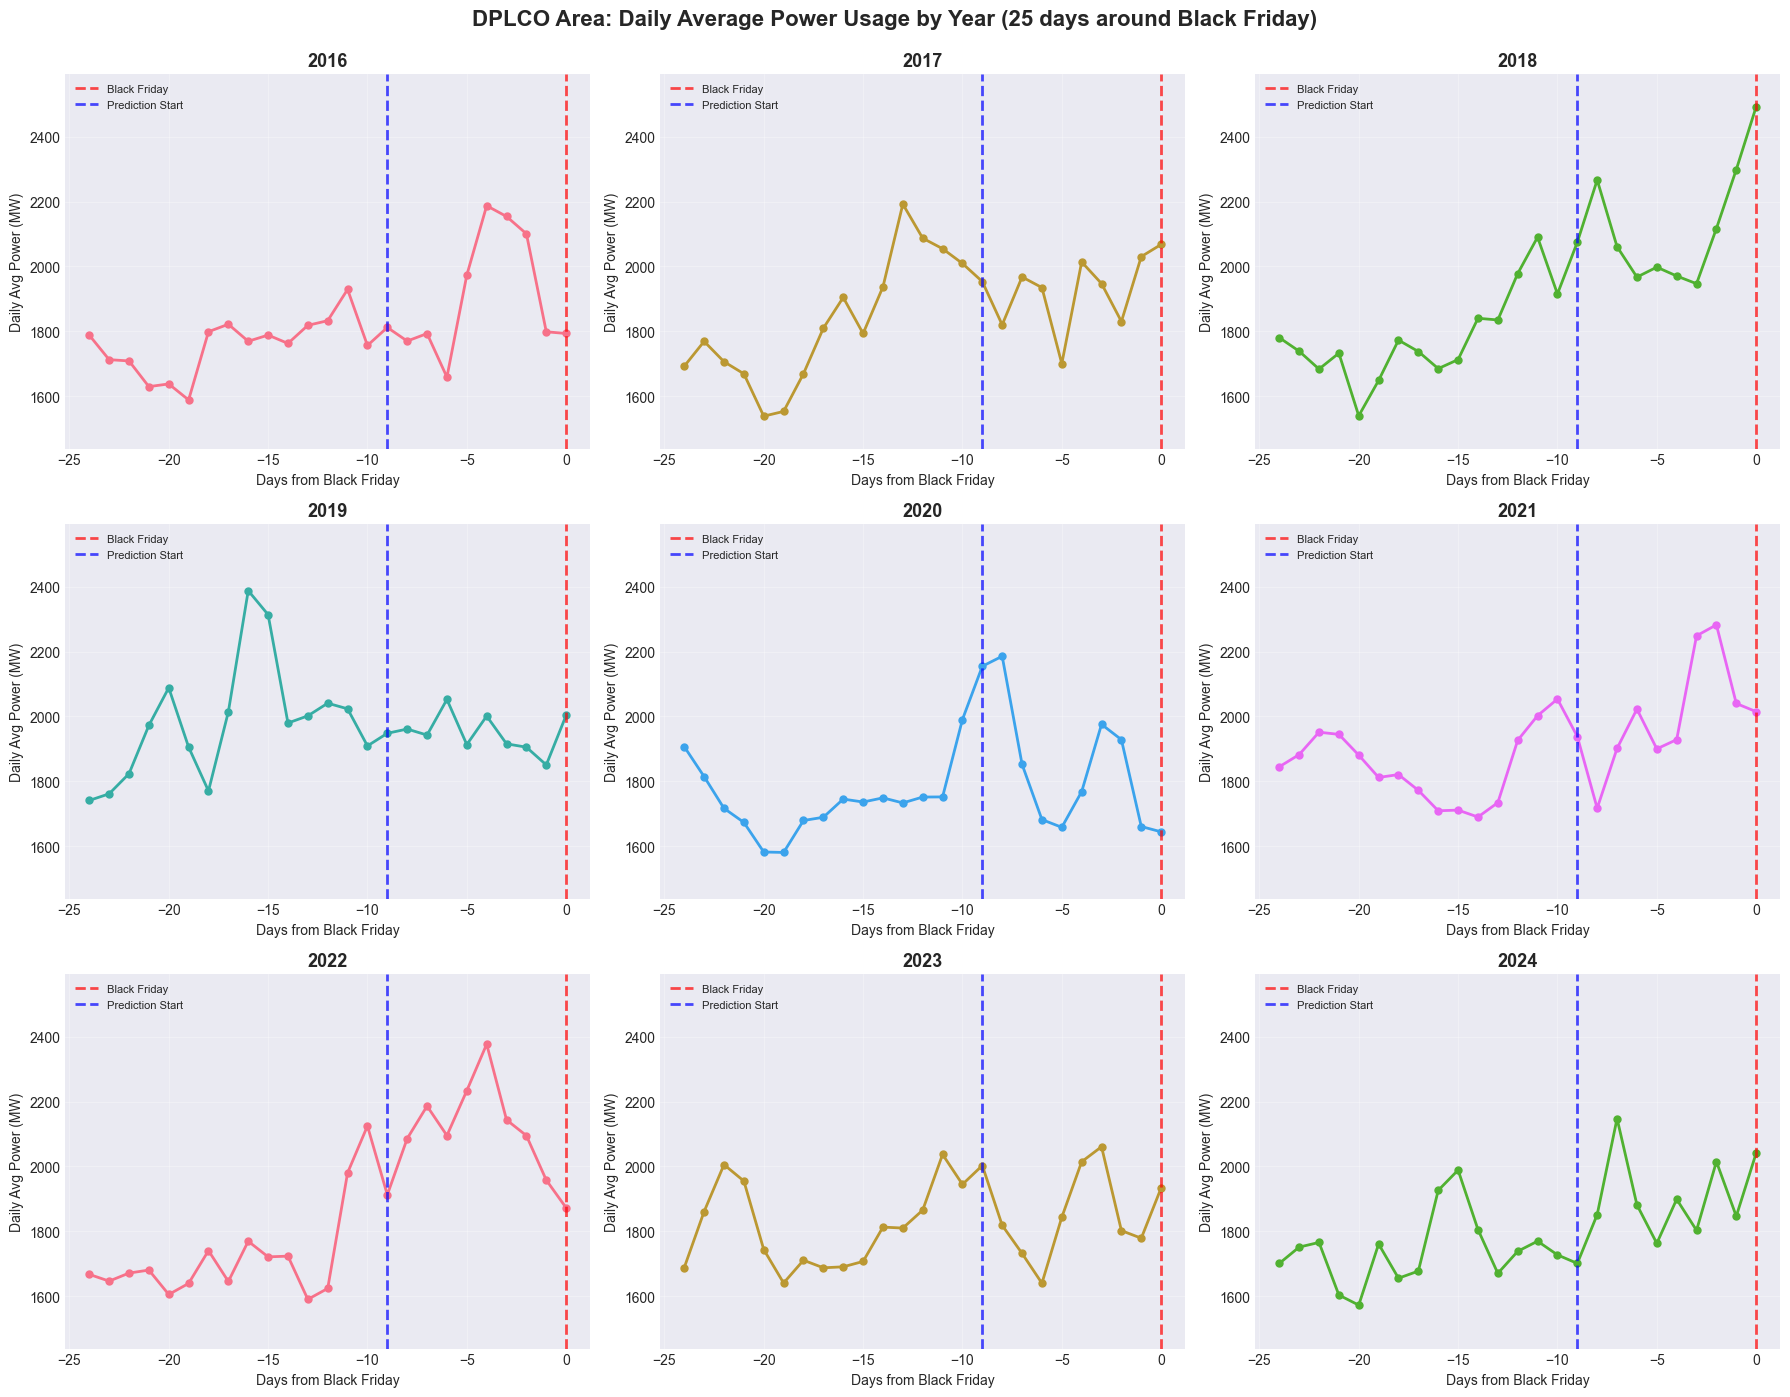


Total data for DPLCO: 5,406 rows

Data count by year:
year
2016    601
2017    601
2018    601
2019    600
2020    600
2021    601
2022    601
2023    601
2024    600
dtype: int64

Processing: DUQ


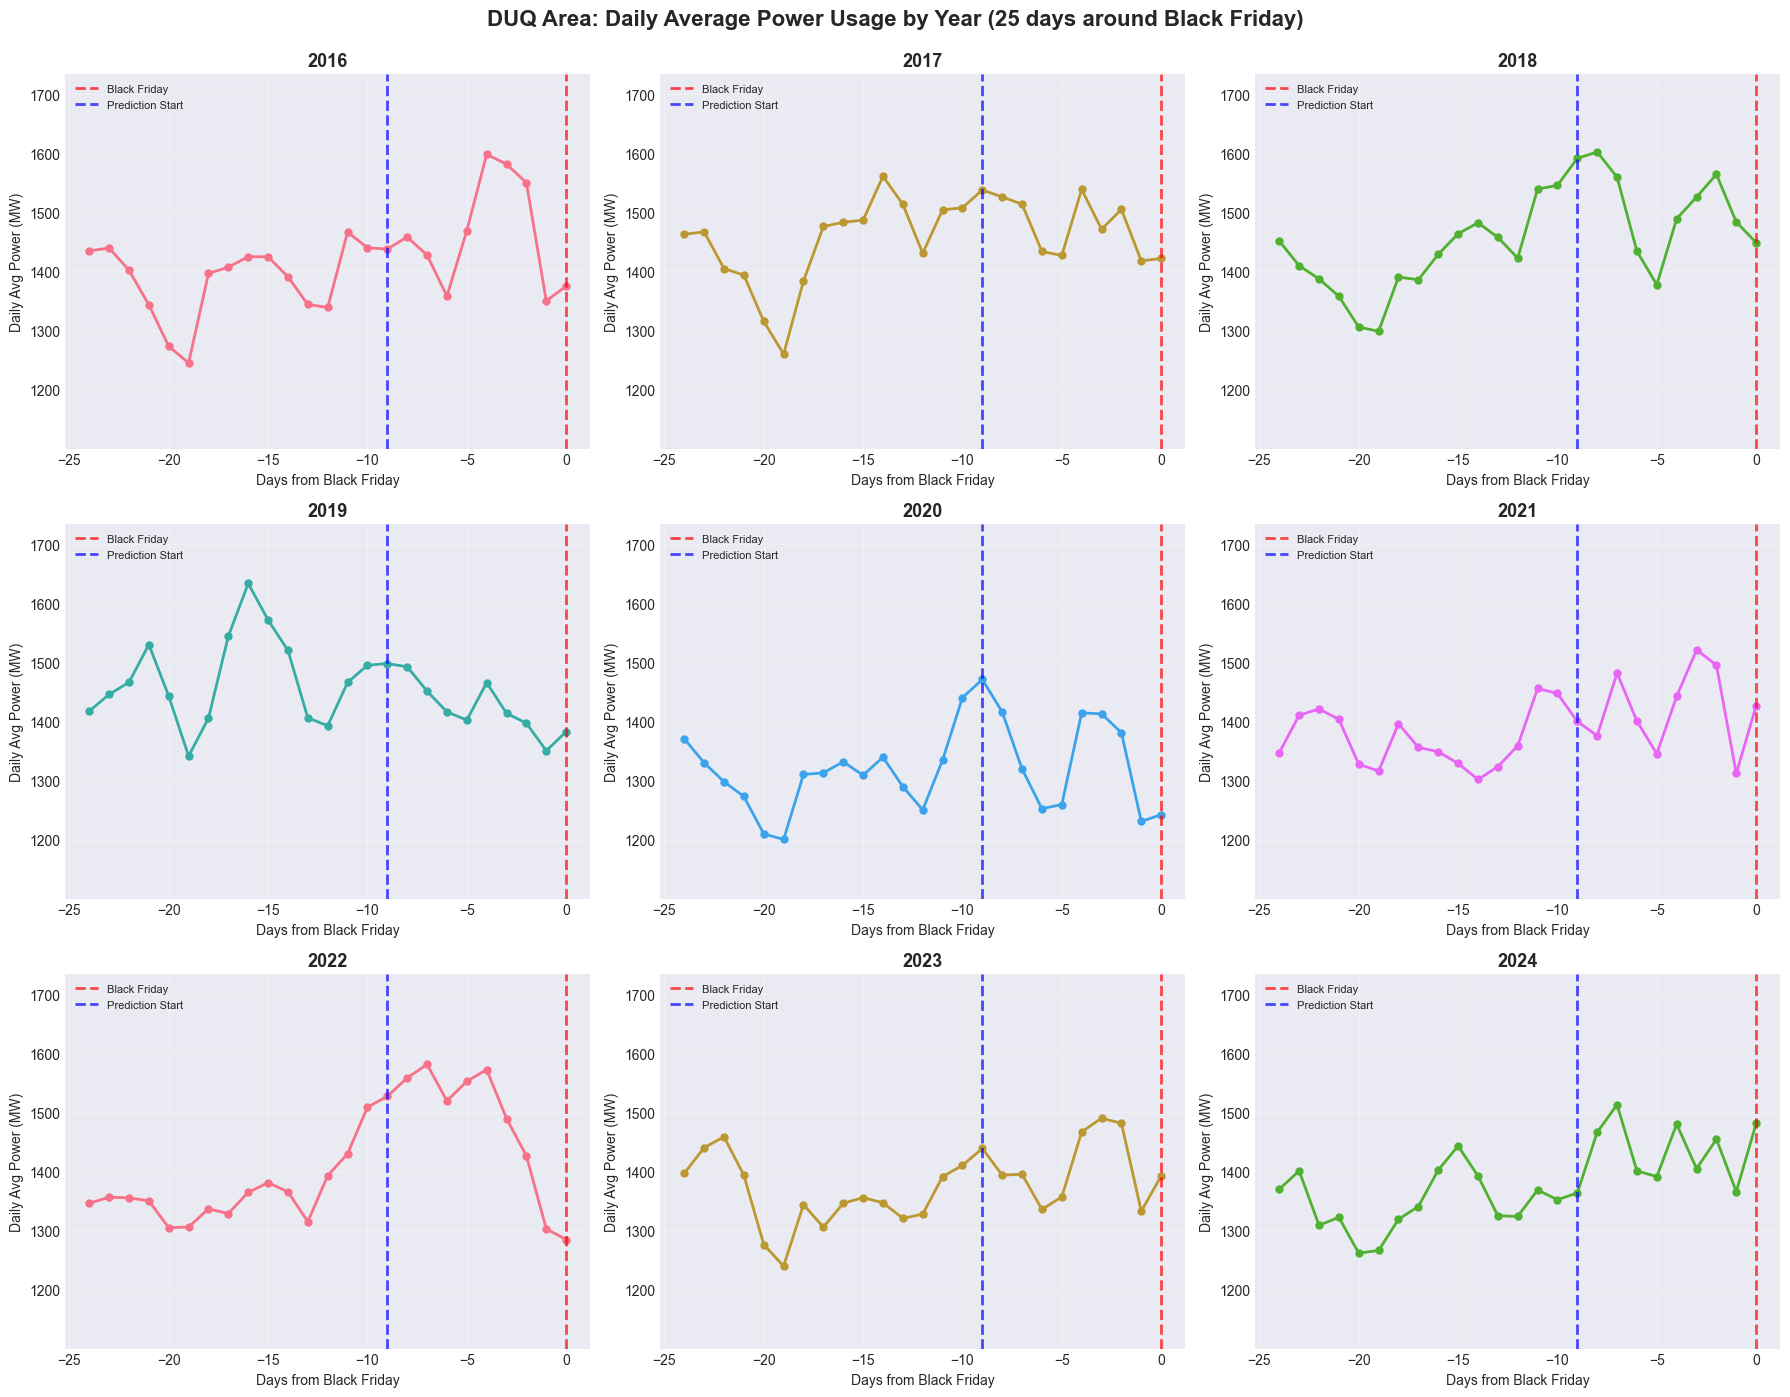


Total data for DUQ: 5,406 rows

Data count by year:
year
2016    601
2017    601
2018    601
2019    600
2020    600
2021    601
2022    601
2023    601
2024    600
dtype: int64

Processing: EASTON


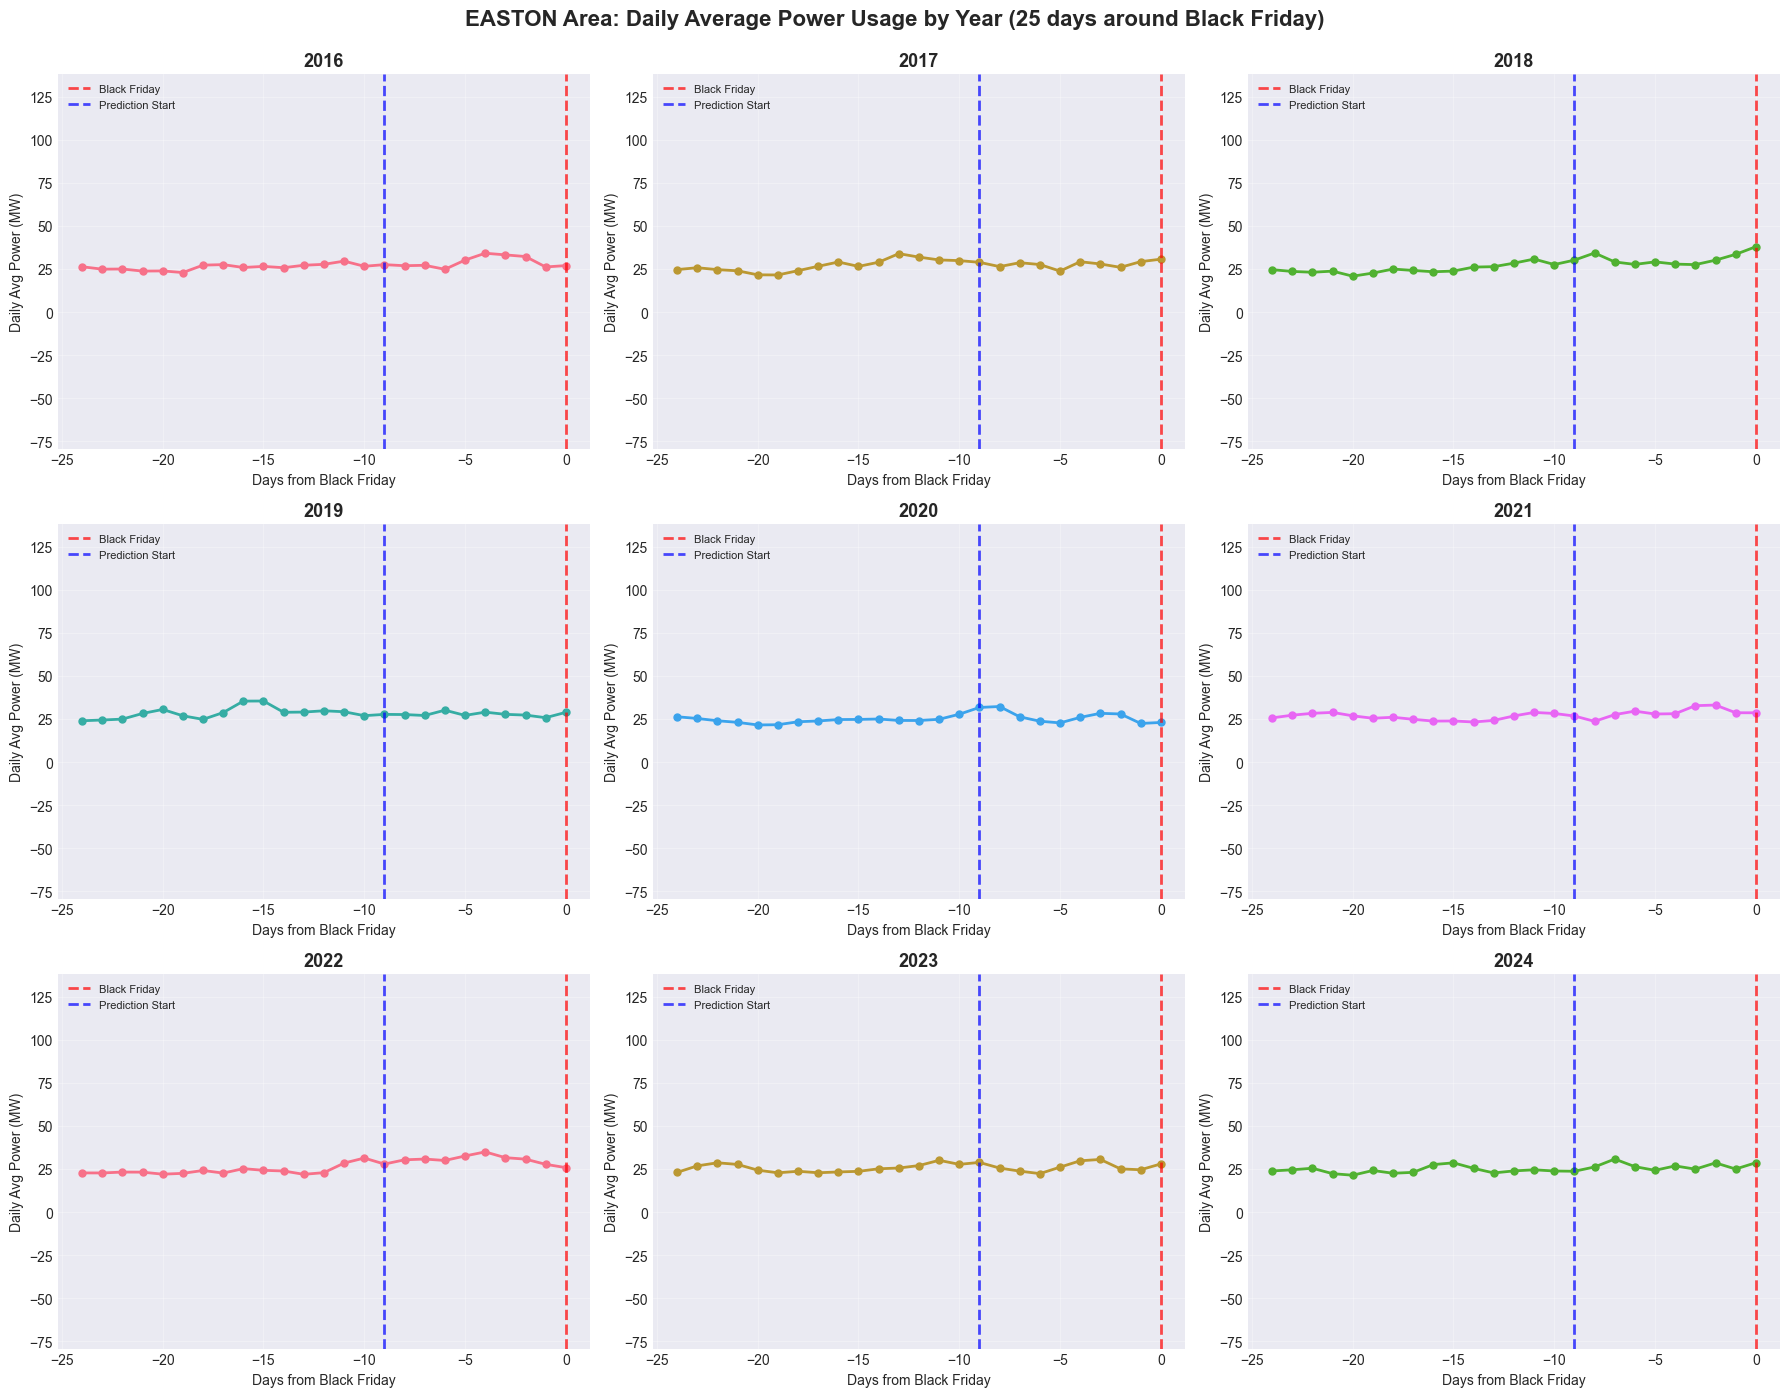


Total data for EASTON: 5,406 rows

Data count by year:
year
2016    601
2017    601
2018    601
2019    600
2020    600
2021    601
2022    601
2023    601
2024    600
dtype: int64

Processing: EKPC


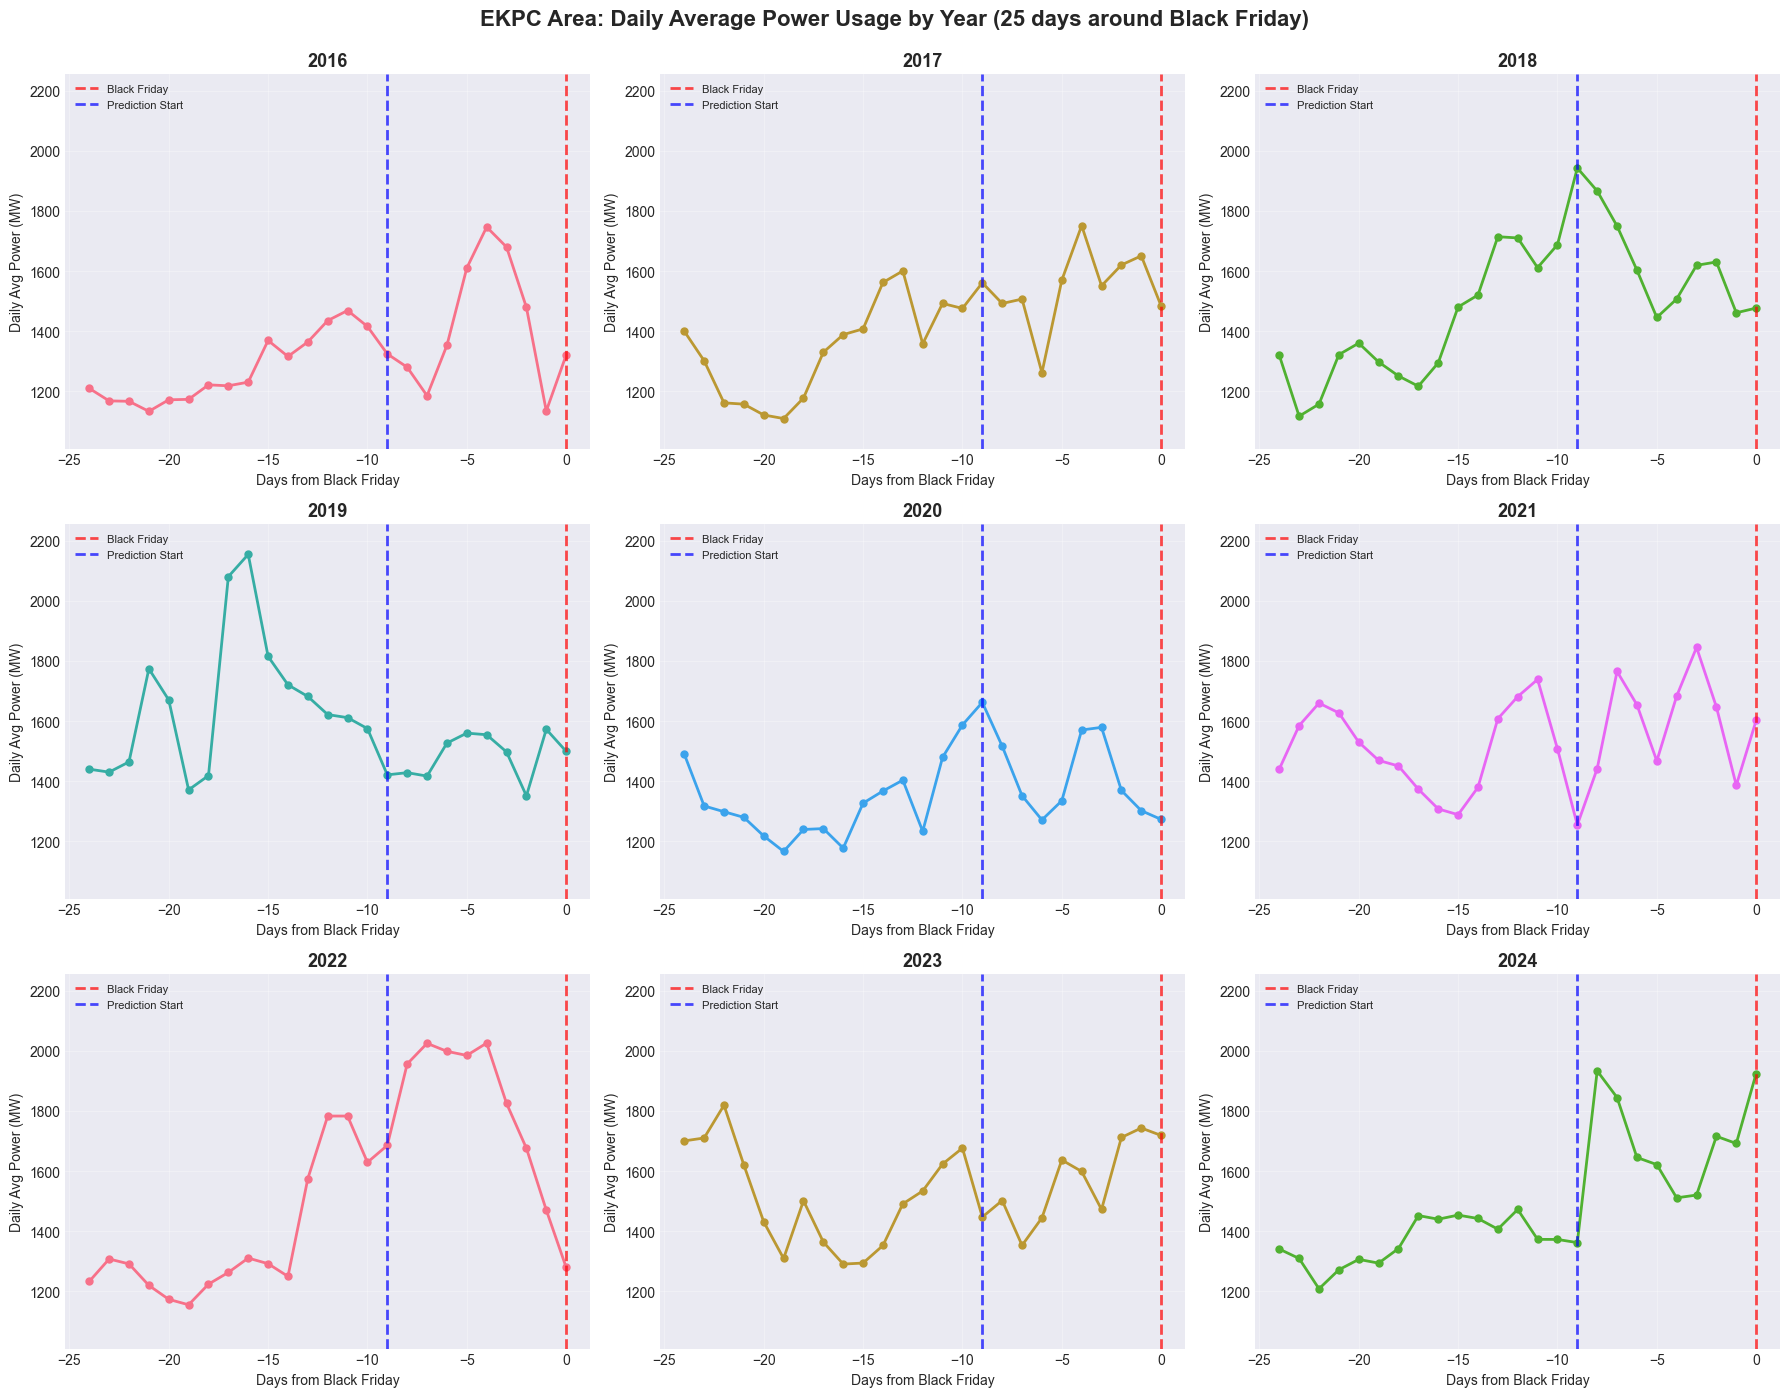


Total data for EKPC: 5,406 rows

Data count by year:
year
2016    601
2017    601
2018    601
2019    600
2020    600
2021    601
2022    601
2023    601
2024    600
dtype: int64

Processing: JC


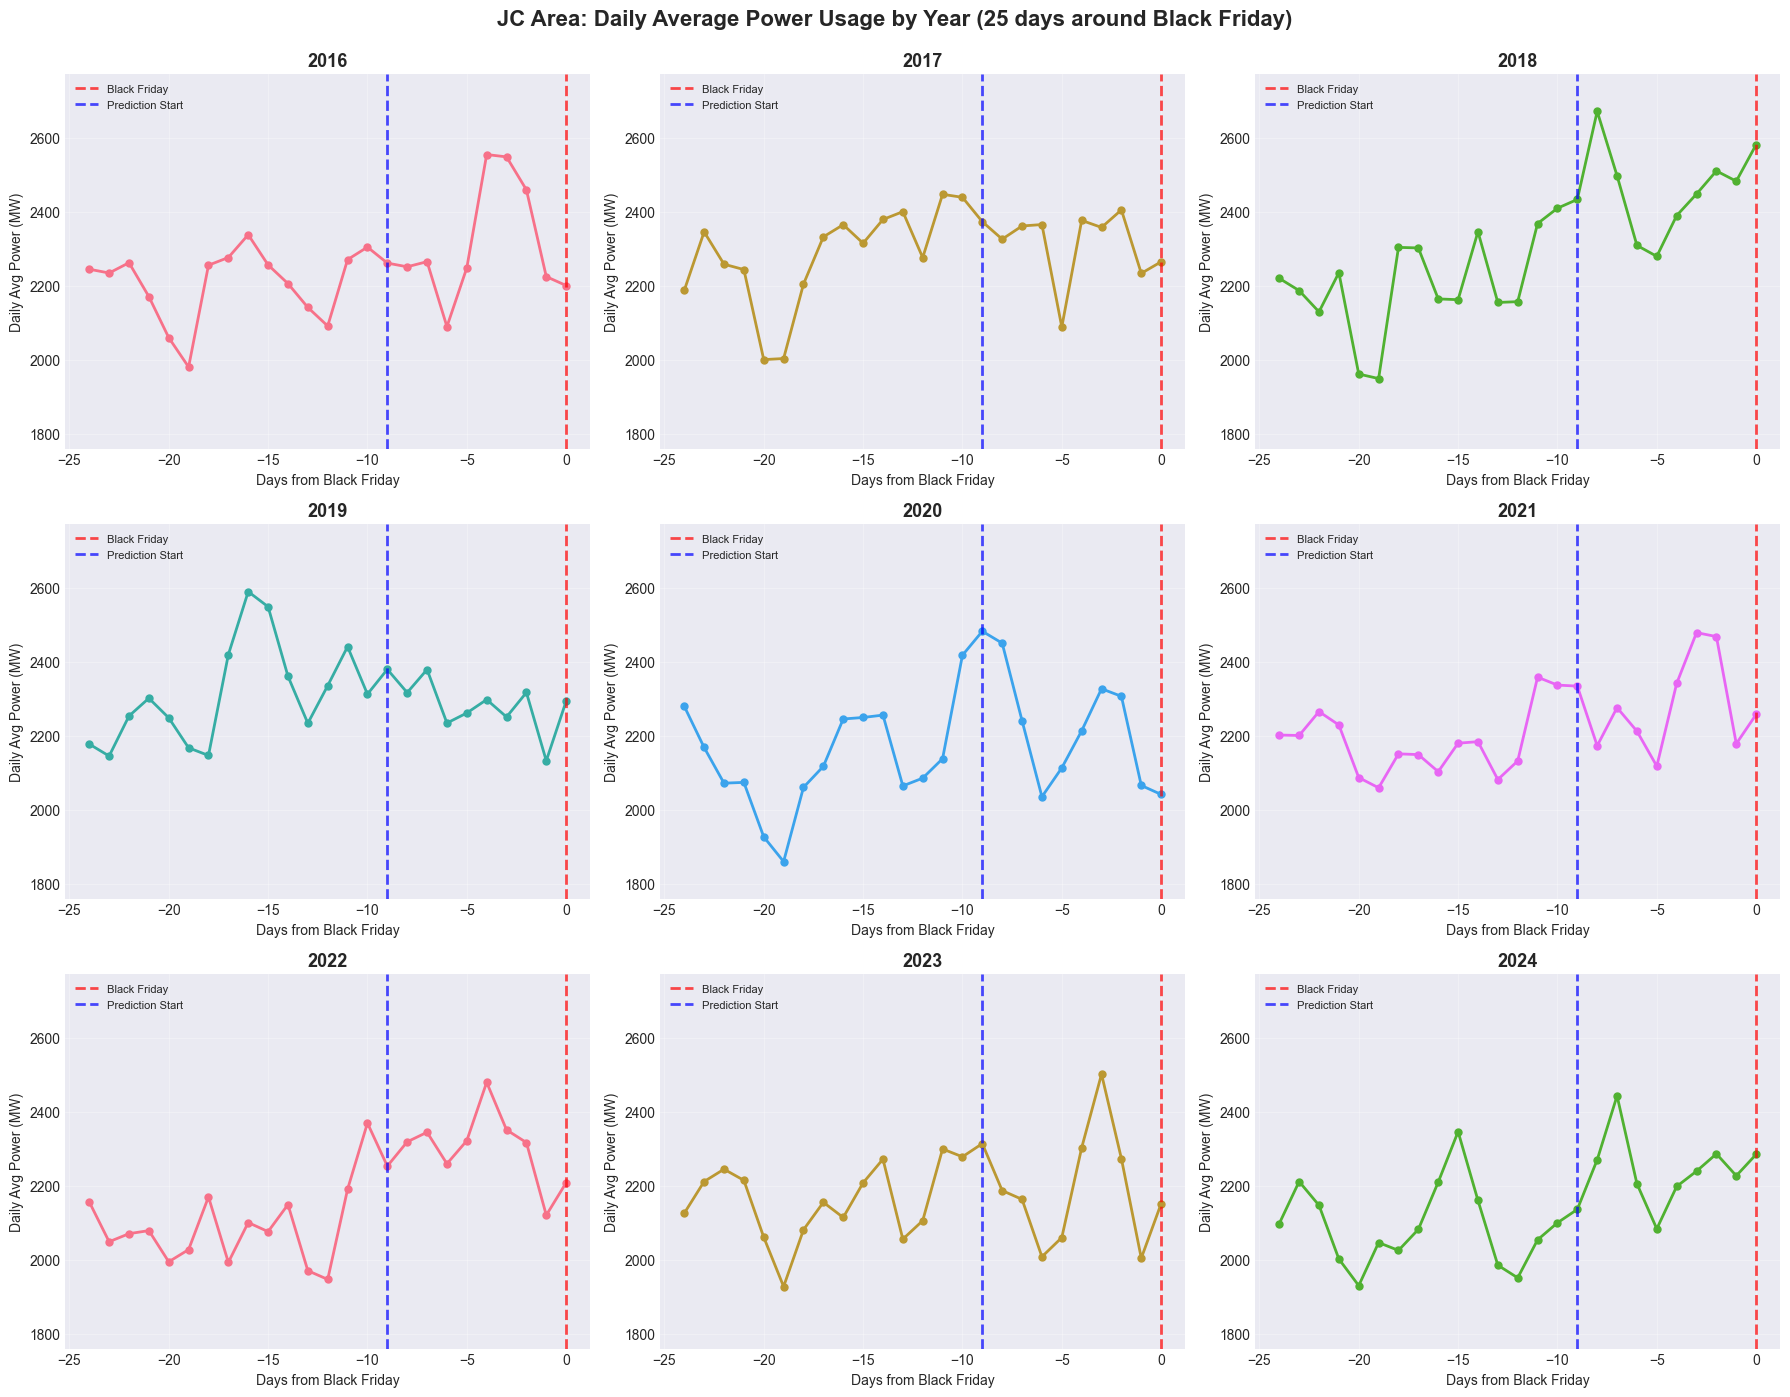


Total data for JC: 5,406 rows

Data count by year:
year
2016    601
2017    601
2018    601
2019    600
2020    600
2021    601
2022    601
2023    601
2024    600
dtype: int64

Processing: ME


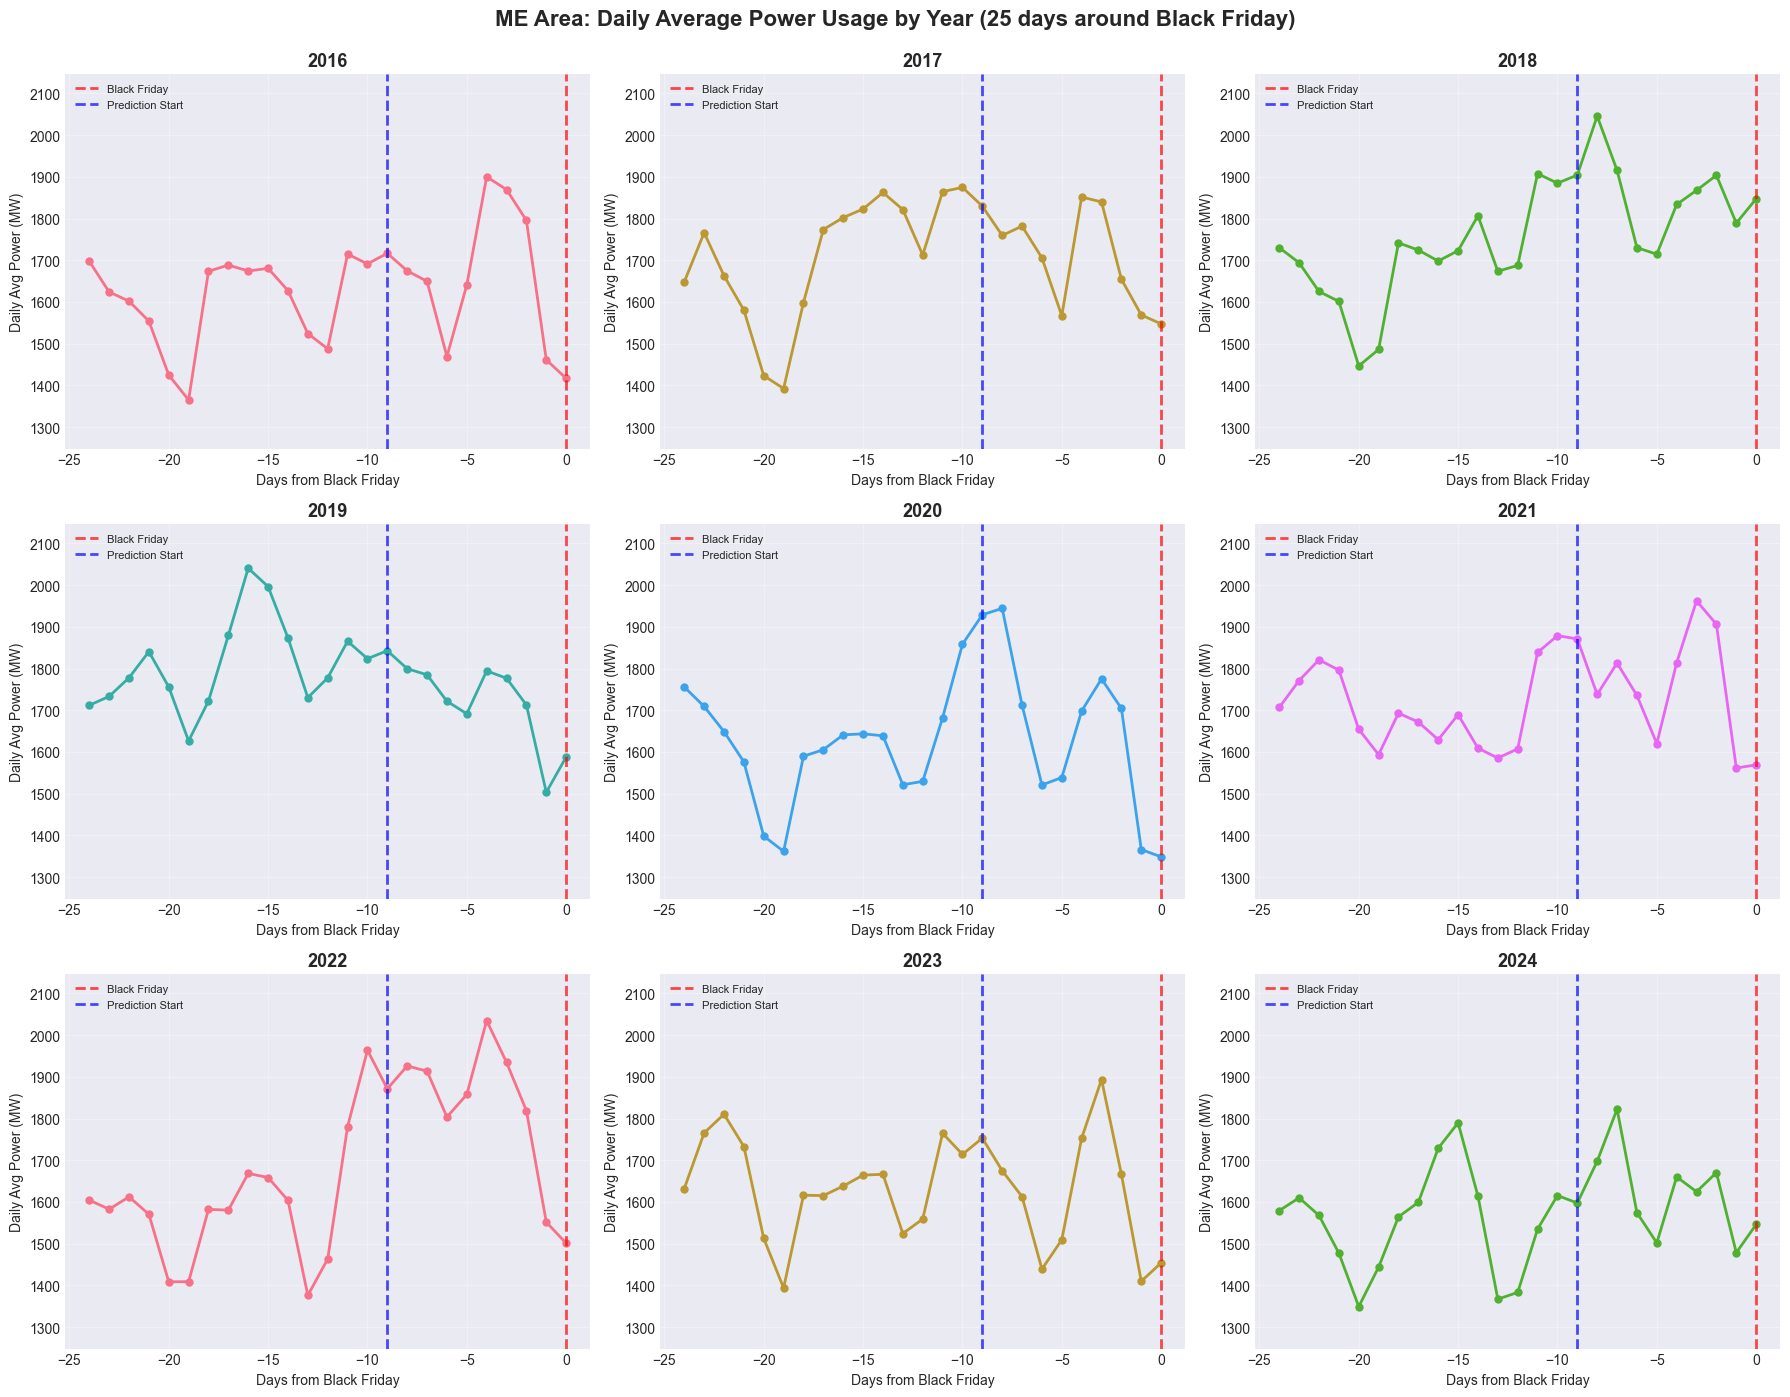


Total data for ME: 5,406 rows

Data count by year:
year
2016    601
2017    601
2018    601
2019    600
2020    600
2021    601
2022    601
2023    601
2024    600
dtype: int64

Processing: OE


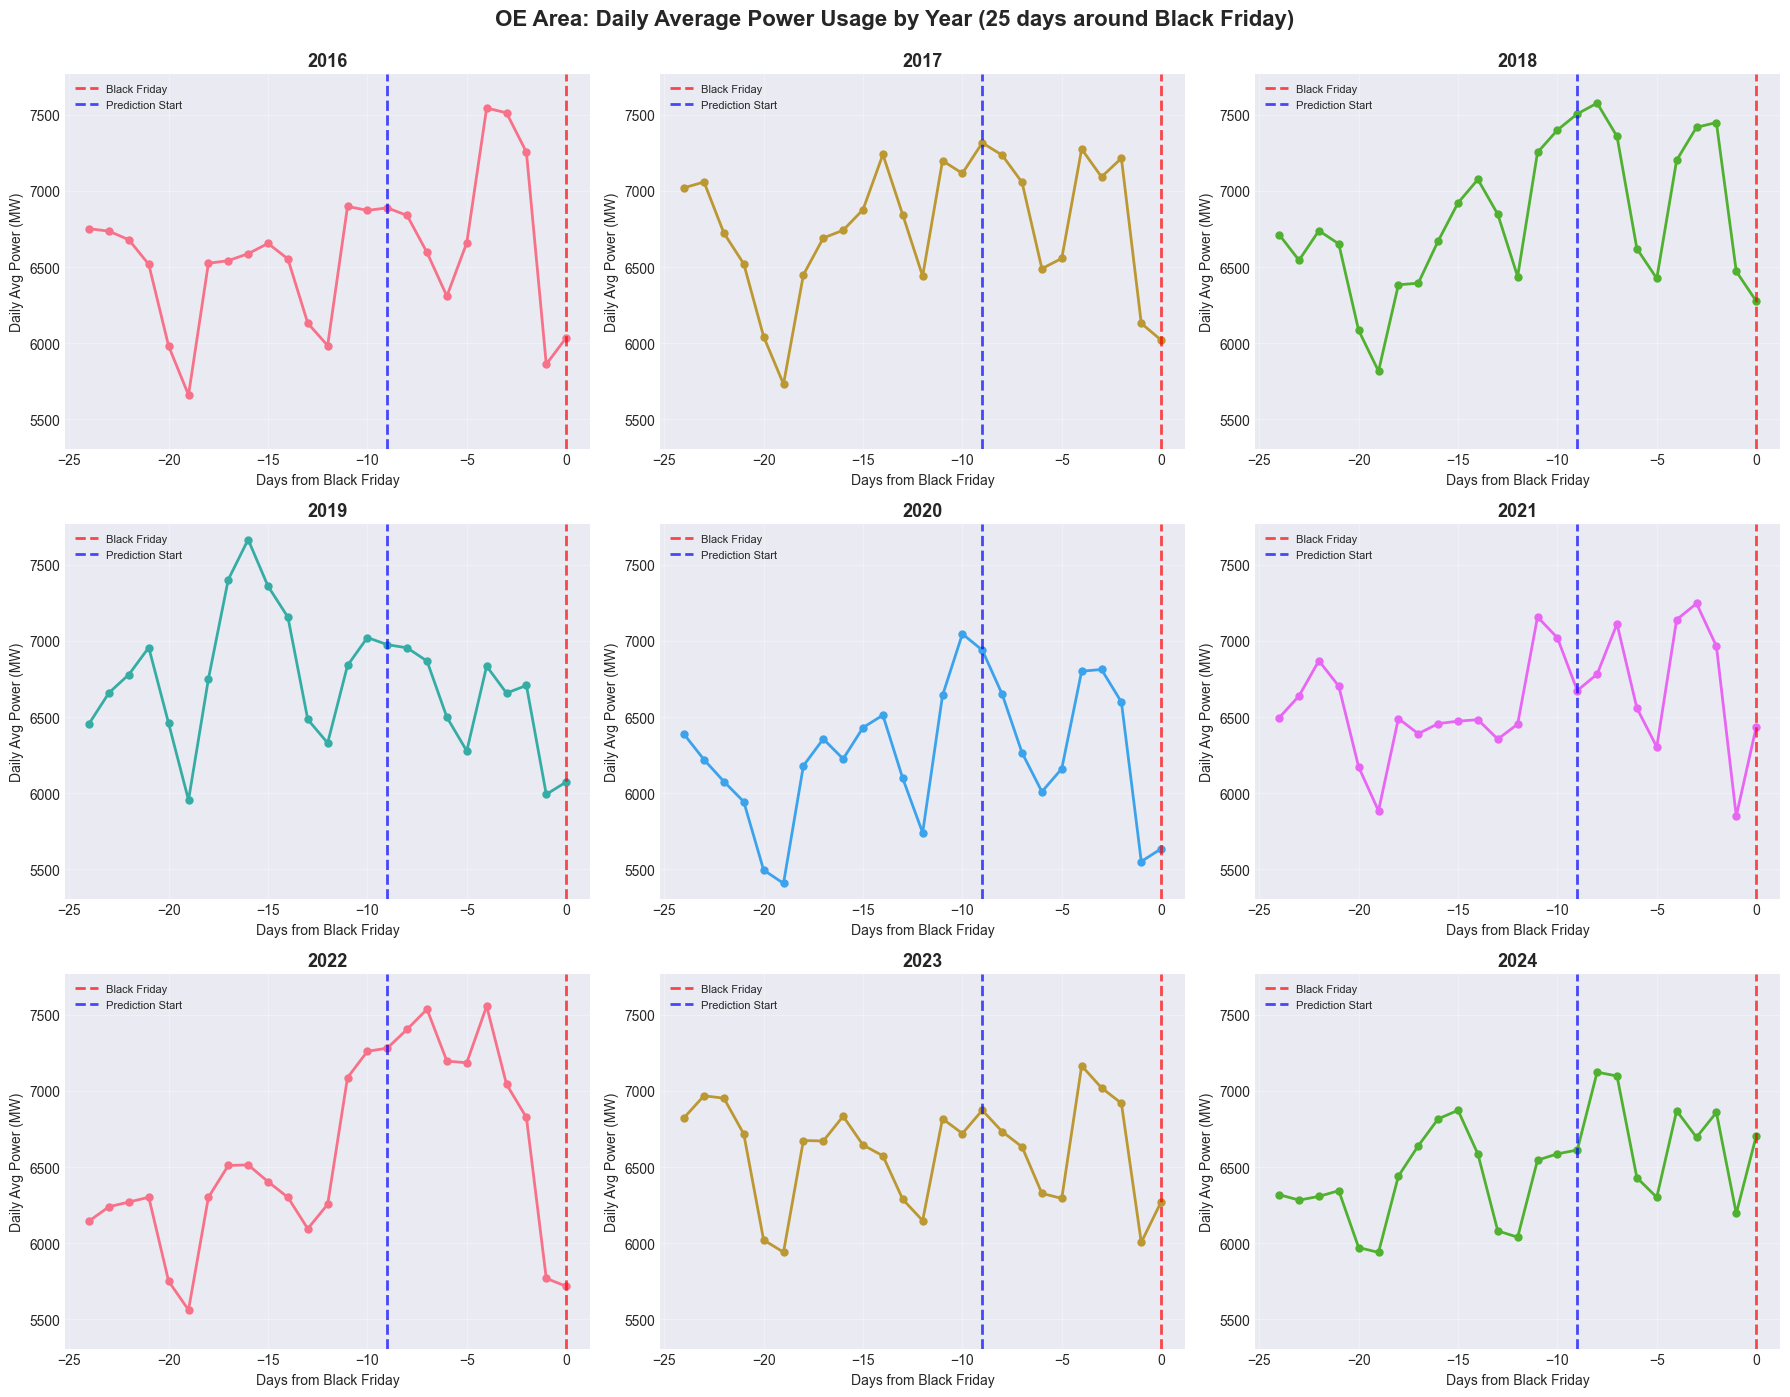


Total data for OE: 5,406 rows

Data count by year:
year
2016    601
2017    601
2018    601
2019    600
2020    600
2021    601
2022    601
2023    601
2024    600
dtype: int64

Processing: OVEC


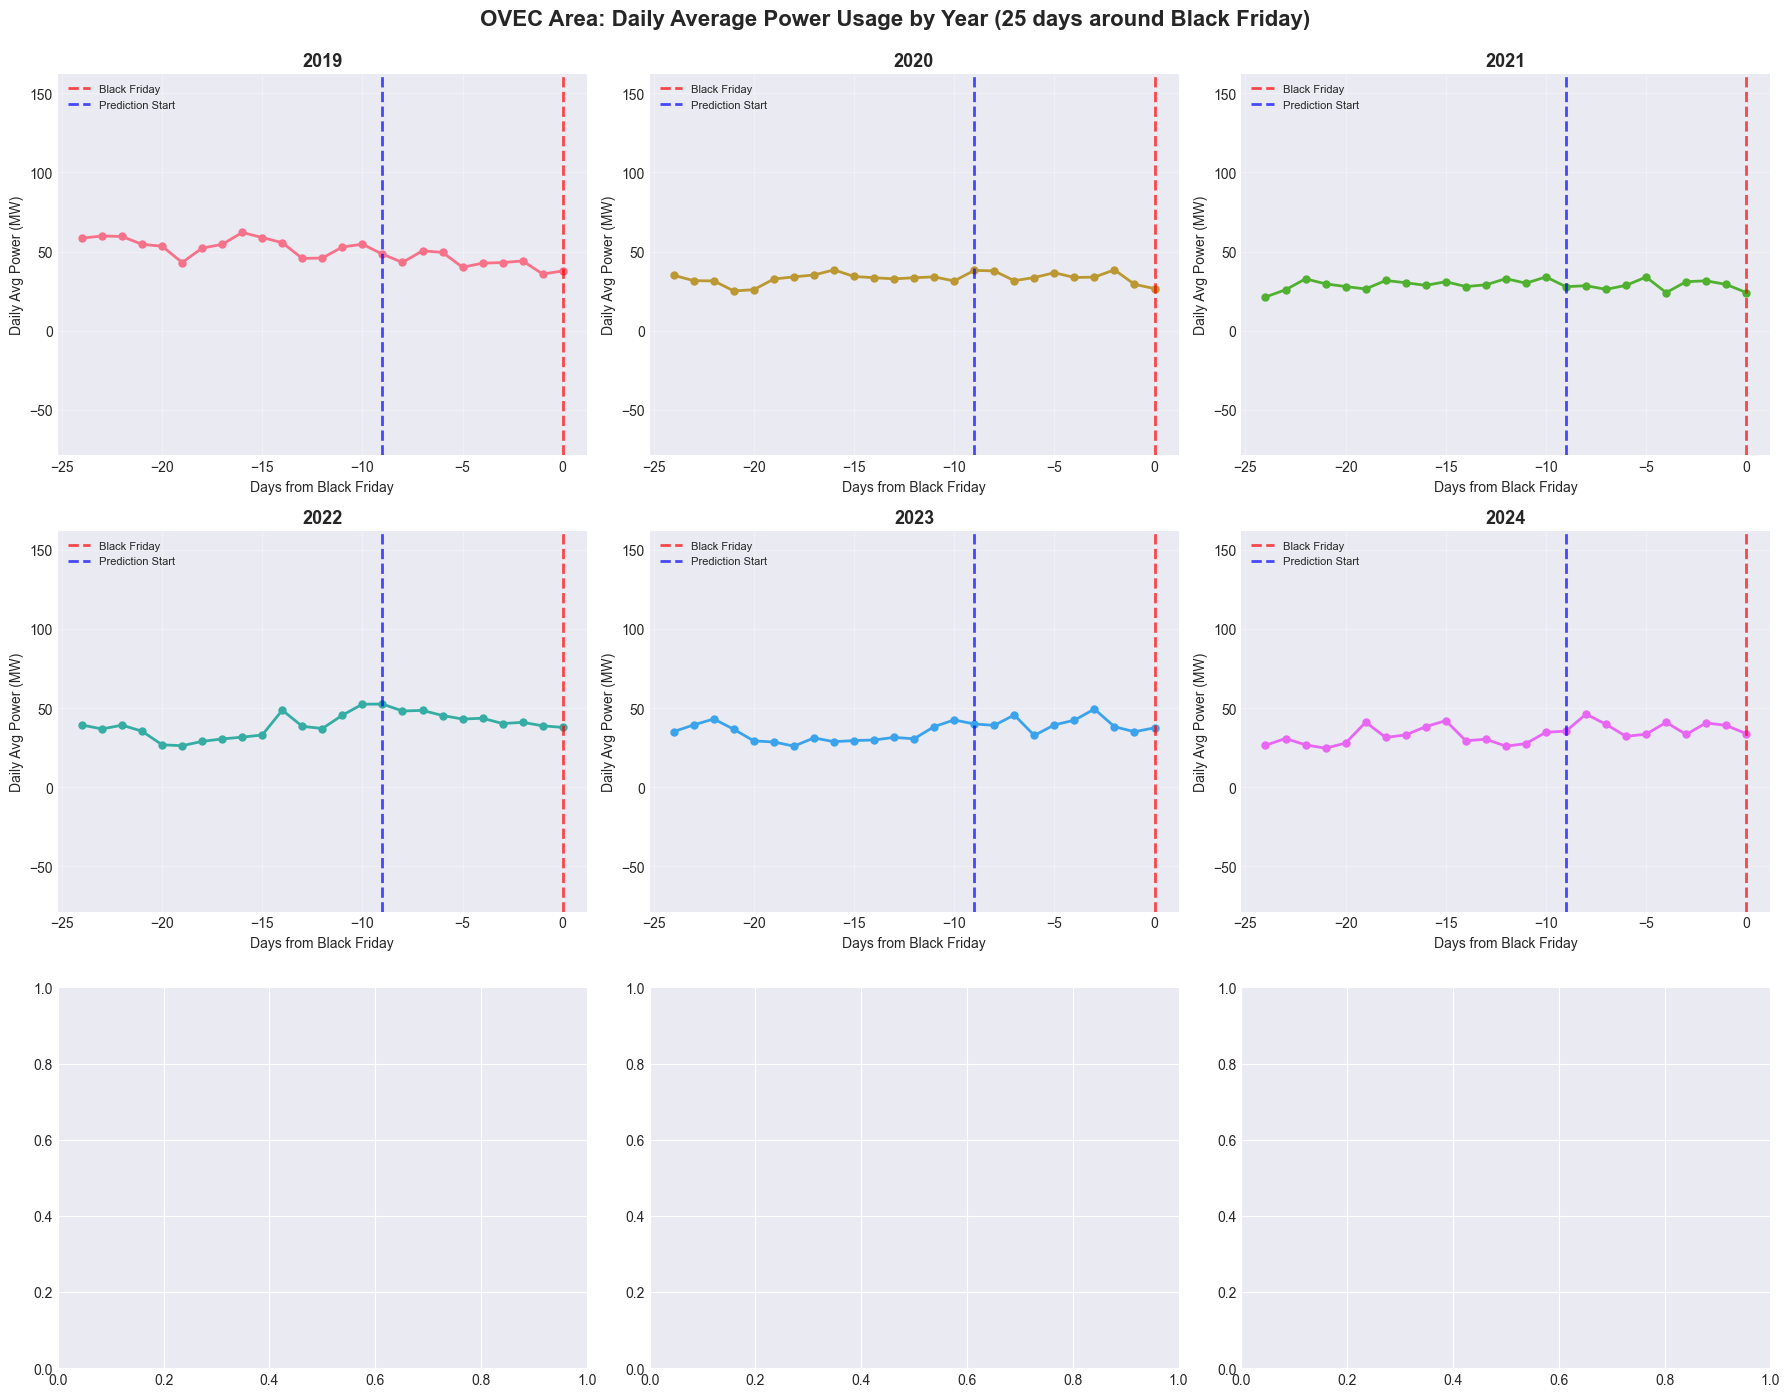


Total data for OVEC: 3,603 rows

Data count by year:
year
2019    600
2020    600
2021    601
2022    601
2023    601
2024    600
dtype: int64

Processing: PAPWR


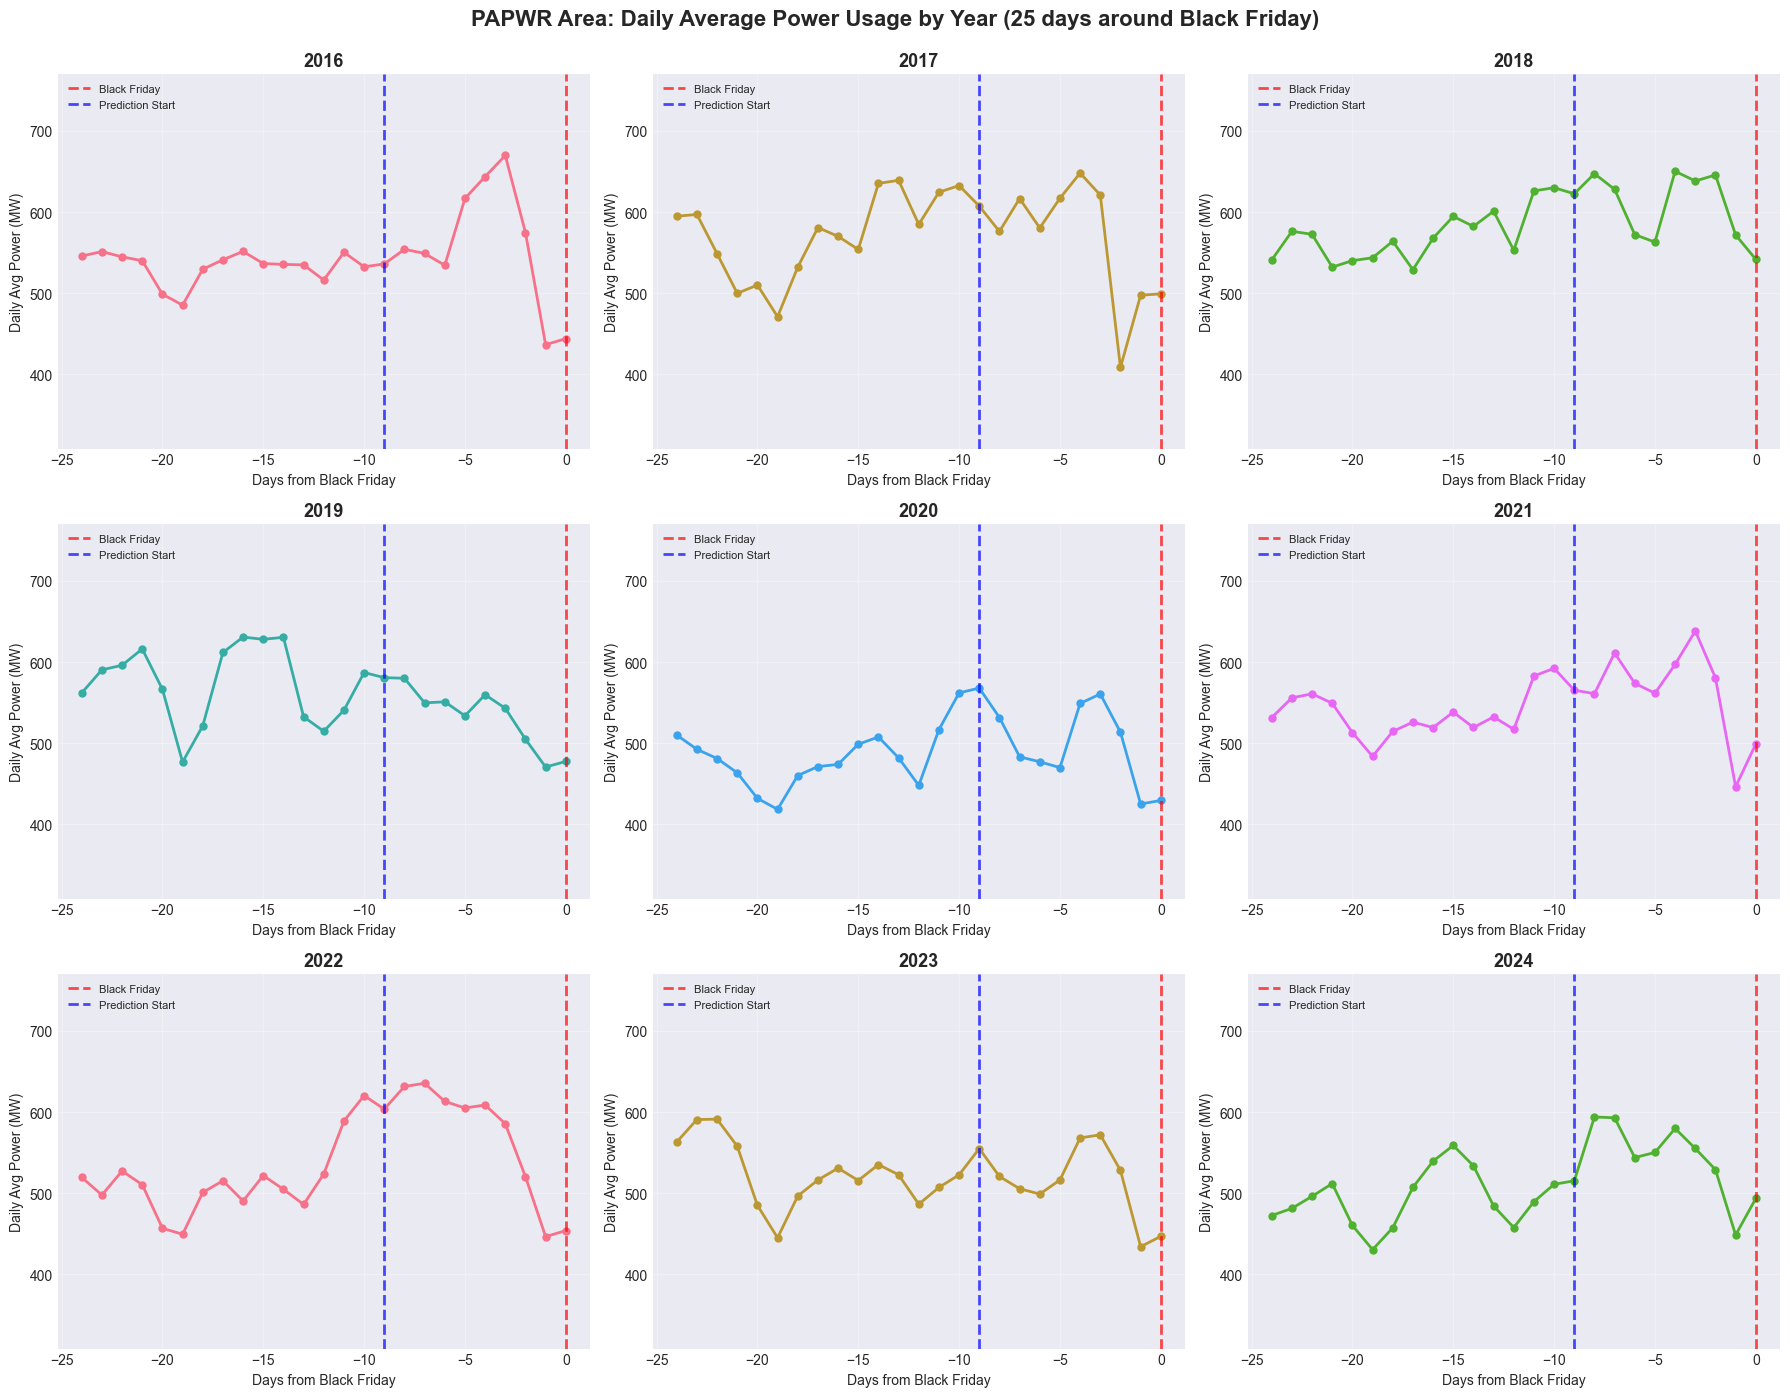


Total data for PAPWR: 5,406 rows

Data count by year:
year
2016    601
2017    601
2018    601
2019    600
2020    600
2021    601
2022    601
2023    601
2024    600
dtype: int64

Processing: PE


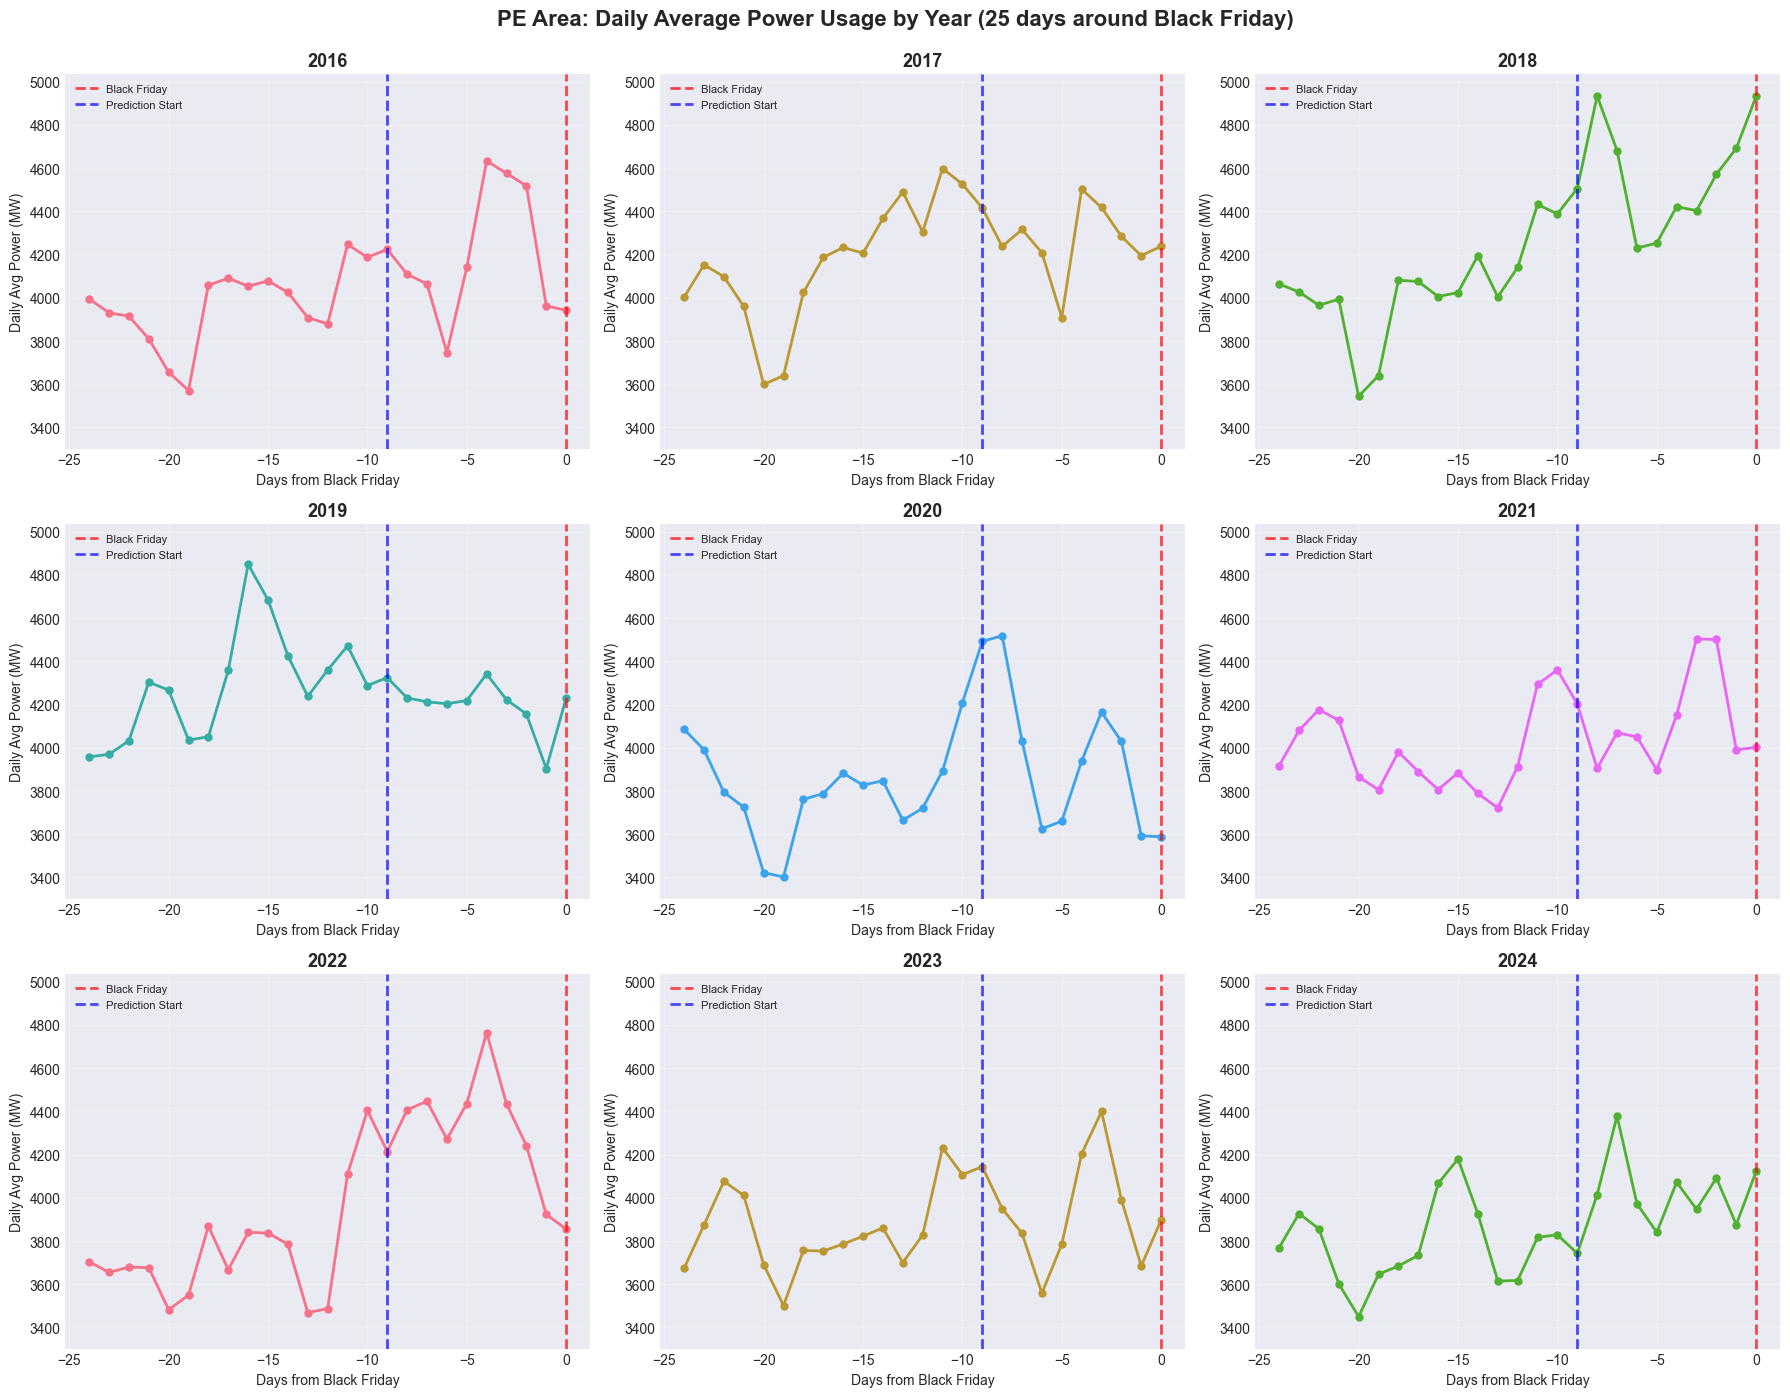


Total data for PE: 5,406 rows

Data count by year:
year
2016    601
2017    601
2018    601
2019    600
2020    600
2021    601
2022    601
2023    601
2024    600
dtype: int64

Processing: PEPCO


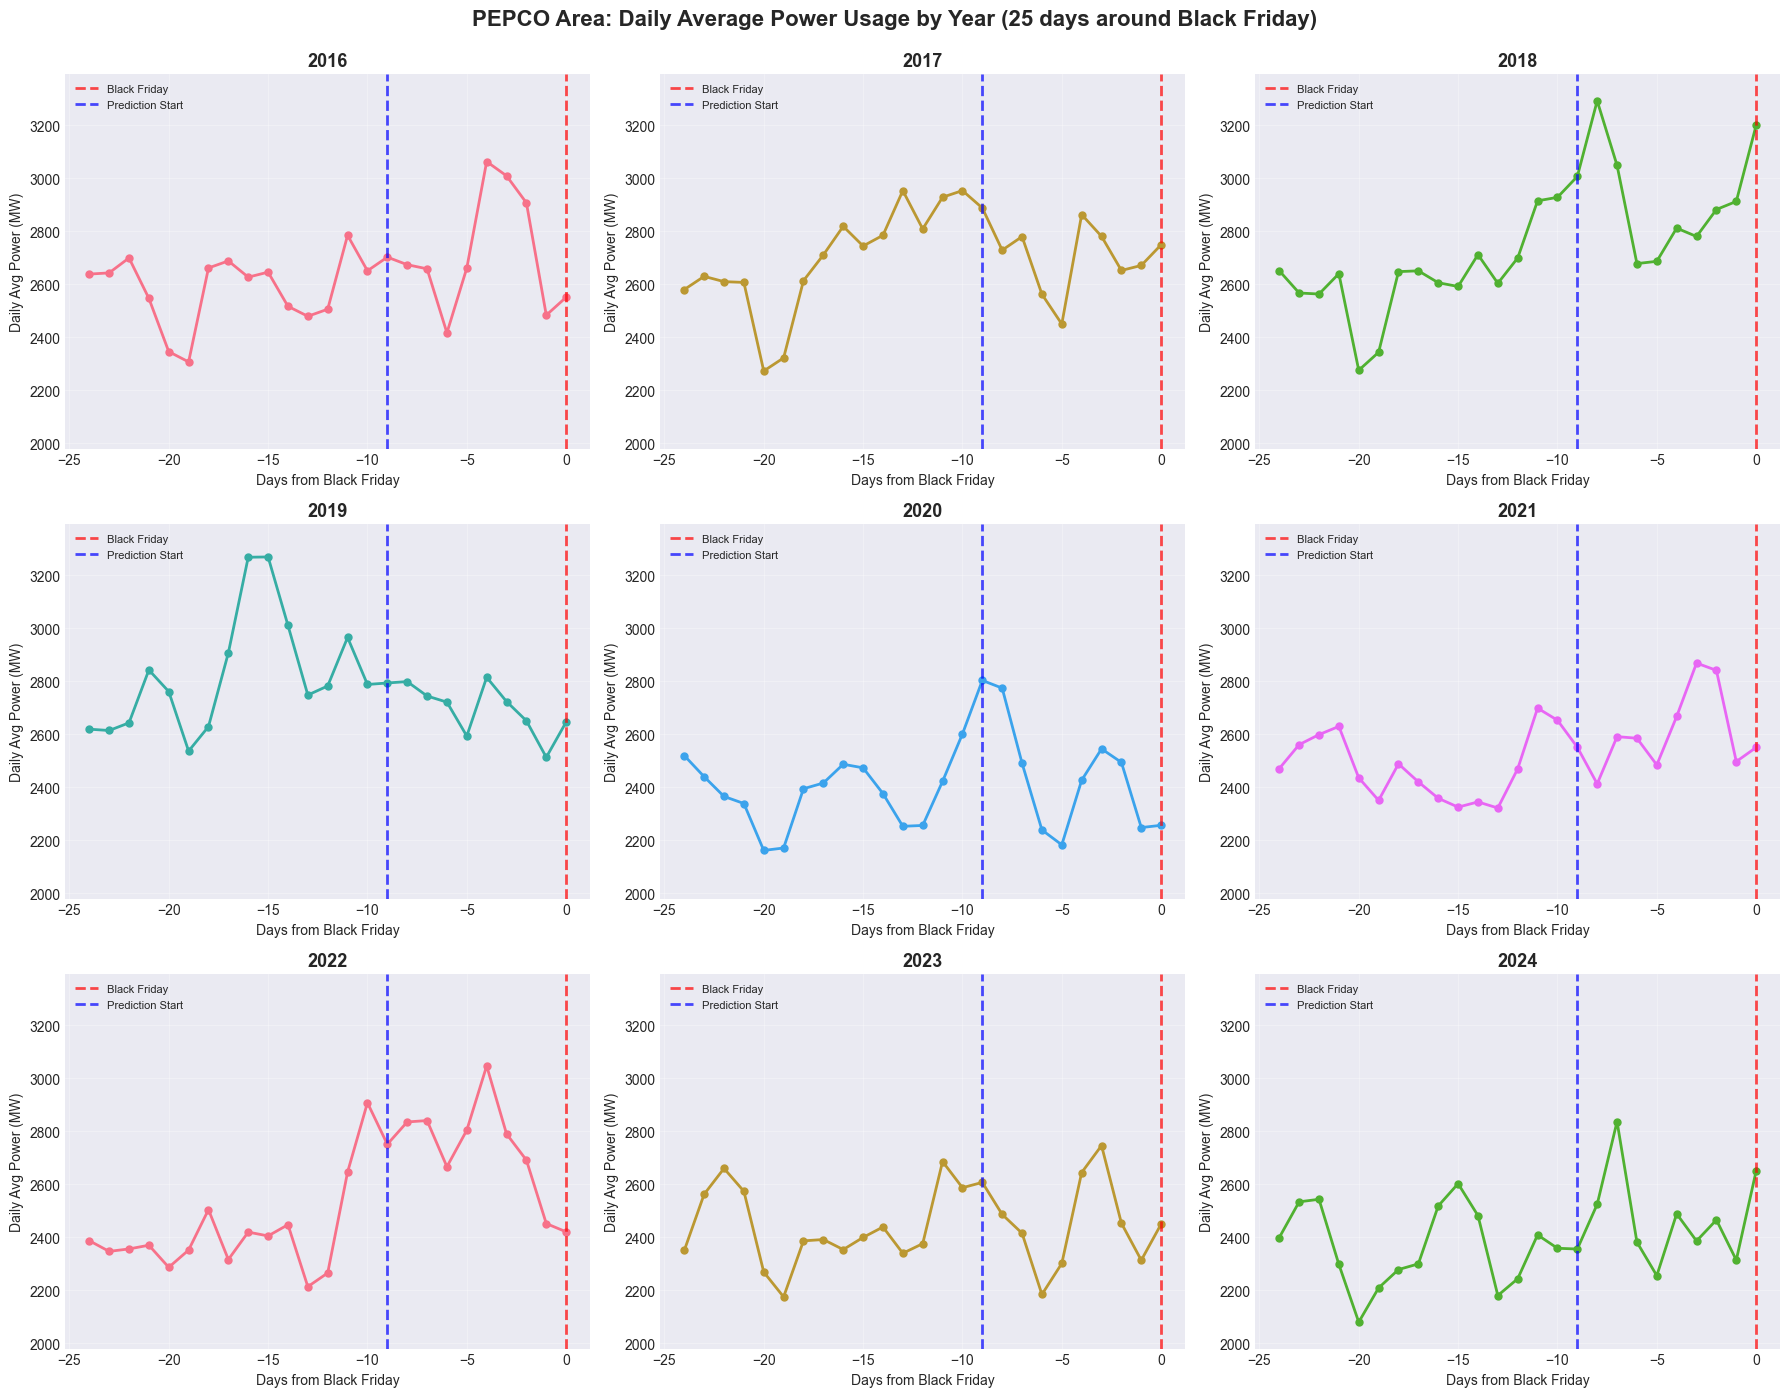


Total data for PEPCO: 5,406 rows

Data count by year:
year
2016    601
2017    601
2018    601
2019    600
2020    600
2021    601
2022    601
2023    601
2024    600
dtype: int64

Processing: PLCO


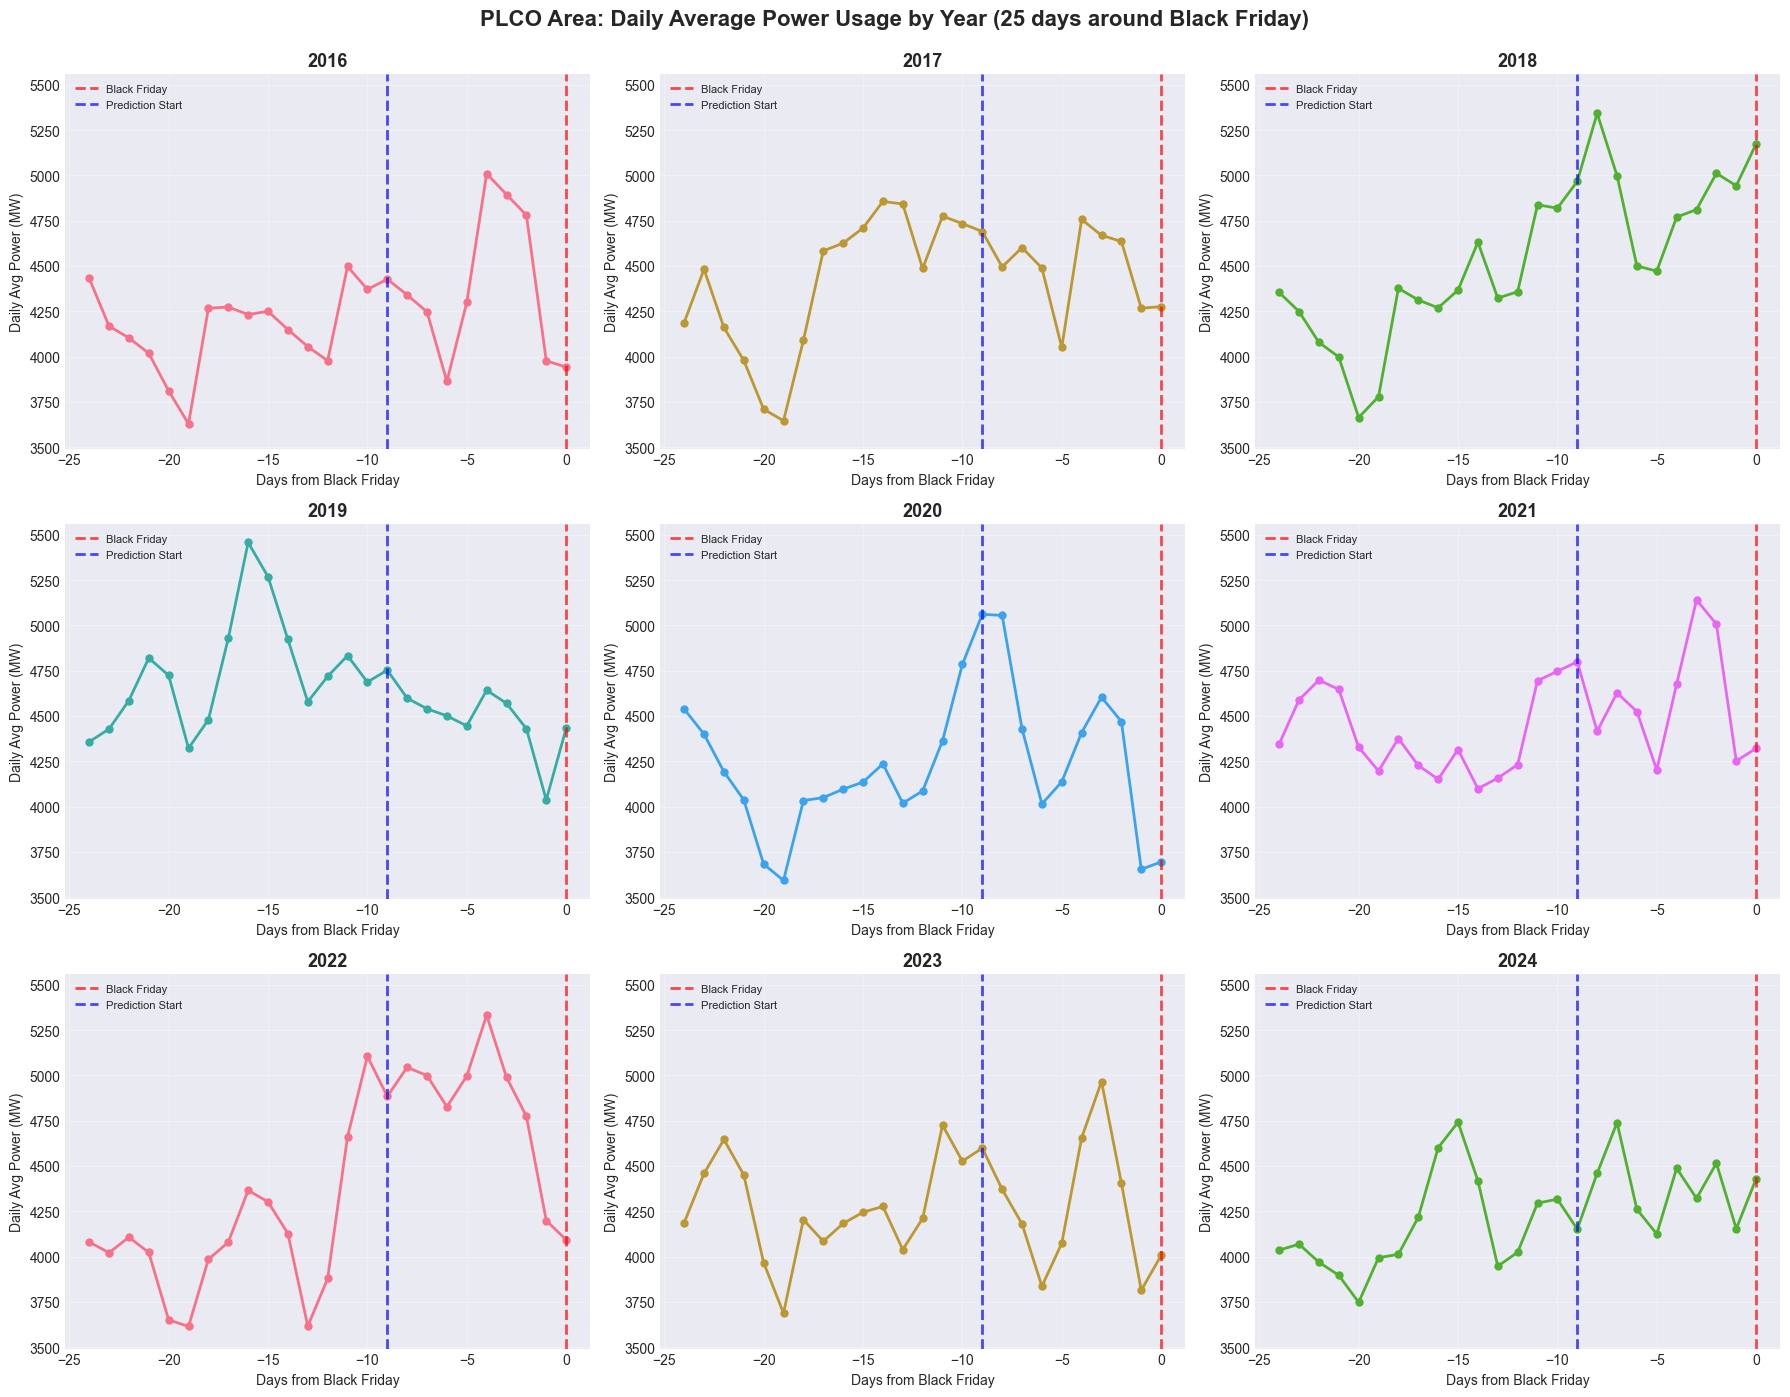


Total data for PLCO: 5,406 rows

Data count by year:
year
2016    601
2017    601
2018    601
2019    600
2020    600
2021    601
2022    601
2023    601
2024    600
dtype: int64

Processing: PN


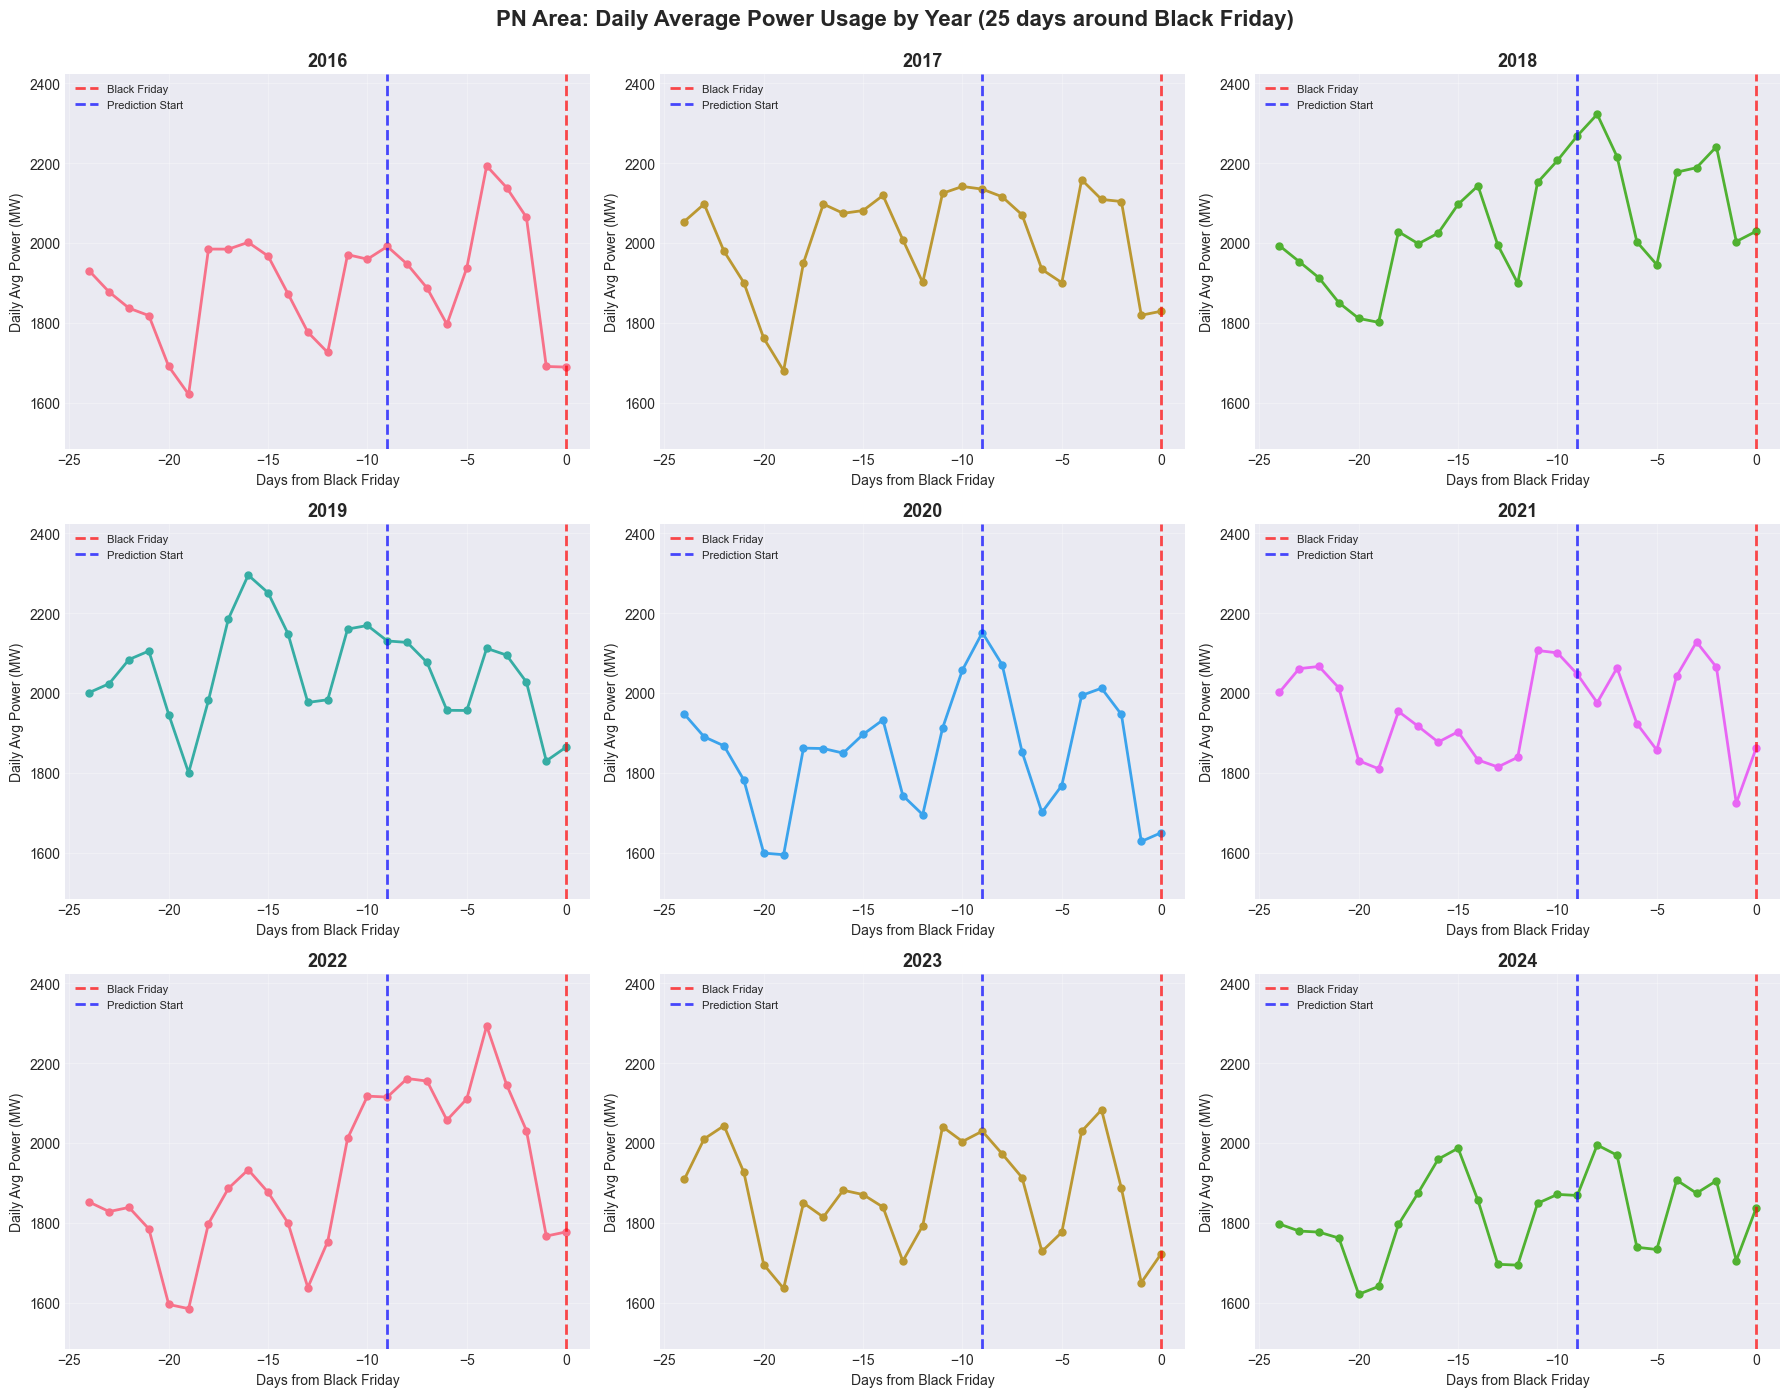


Total data for PN: 5,406 rows

Data count by year:
year
2016    601
2017    601
2018    601
2019    600
2020    600
2021    601
2022    601
2023    601
2024    600
dtype: int64

Processing: PS


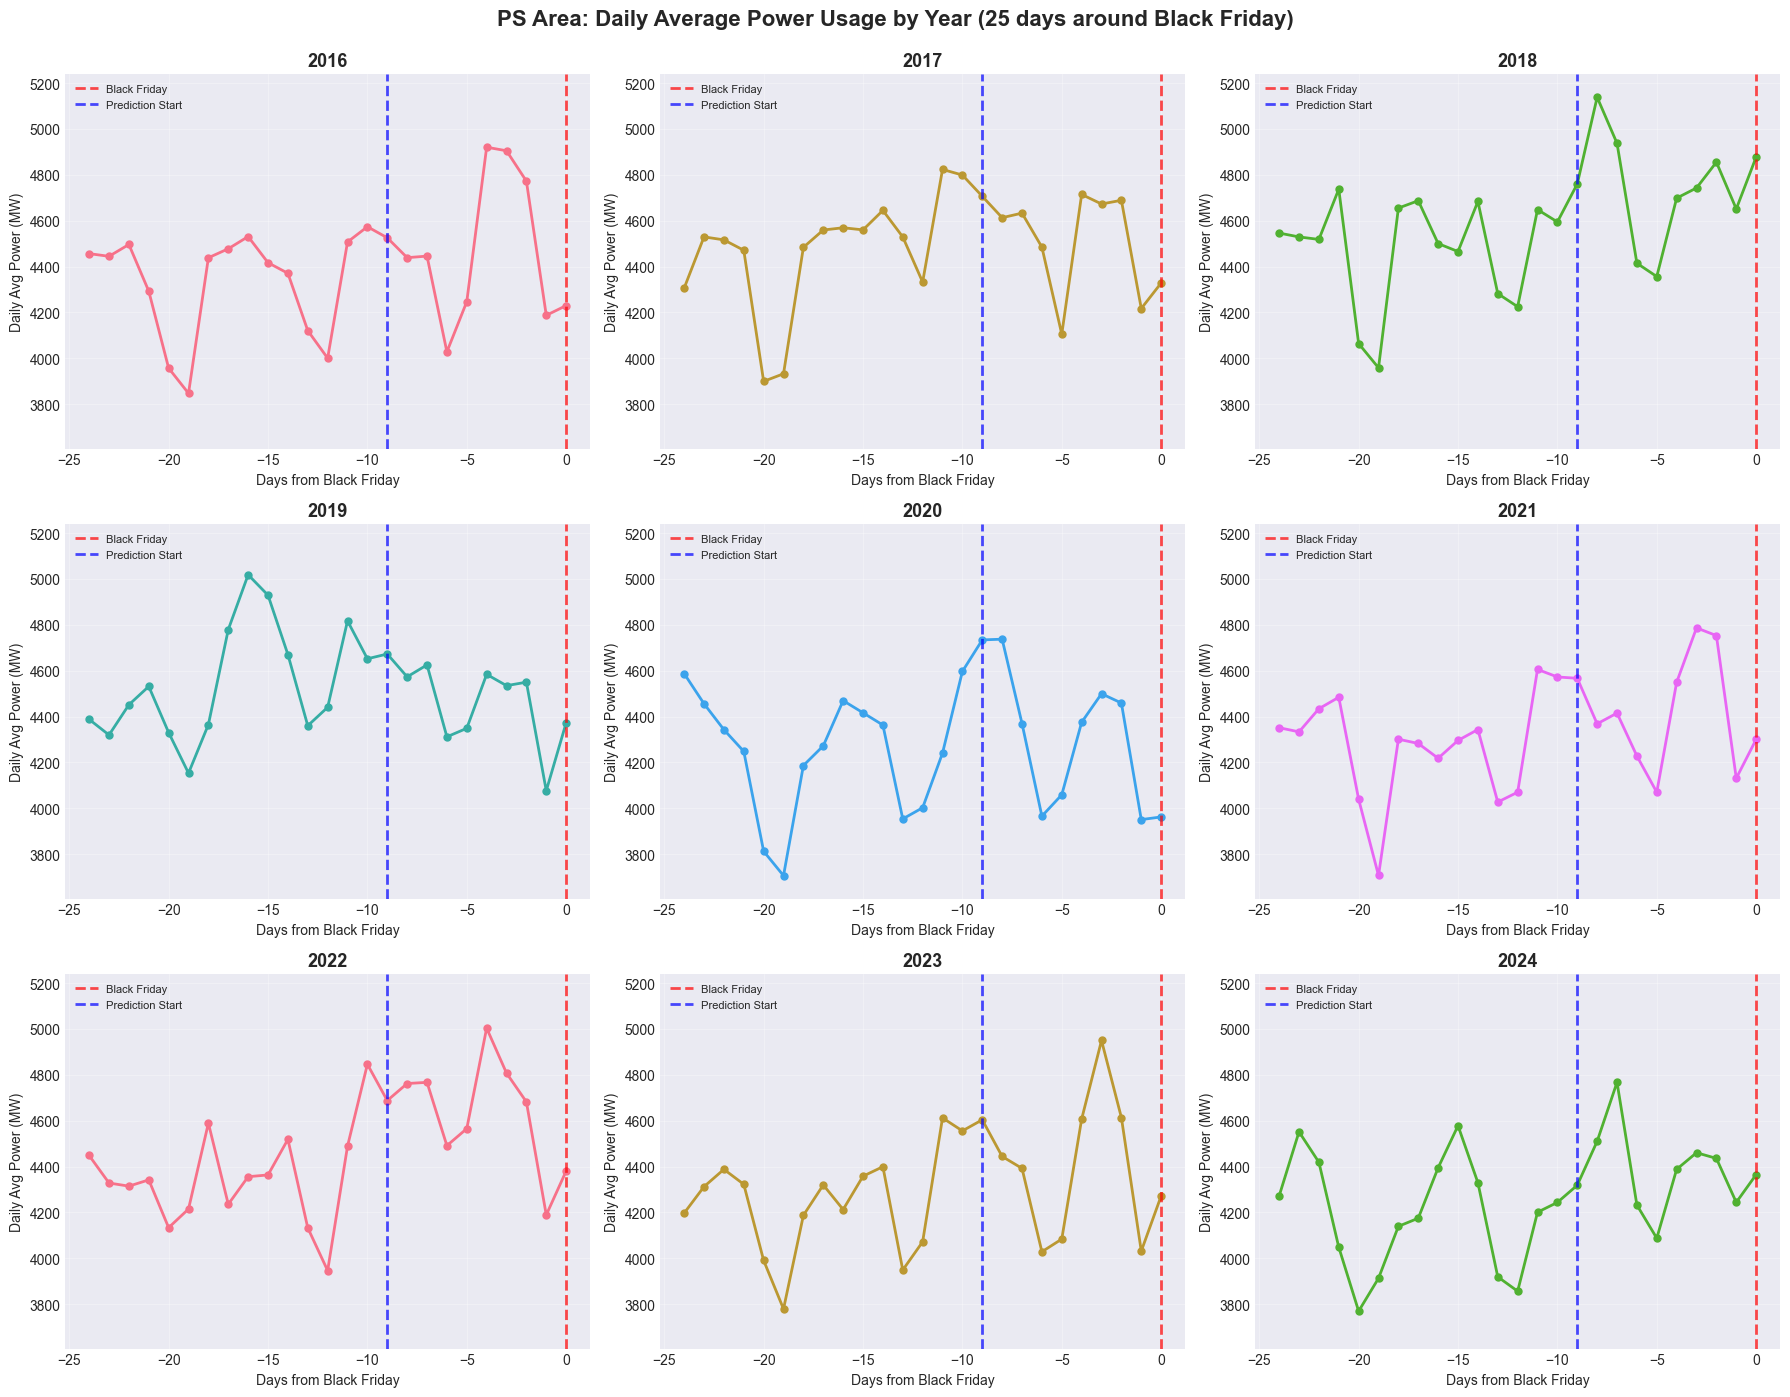


Total data for PS: 5,406 rows

Data count by year:
year
2016    601
2017    601
2018    601
2019    600
2020    600
2021    601
2022    601
2023    601
2024    600
dtype: int64

Processing: RECO


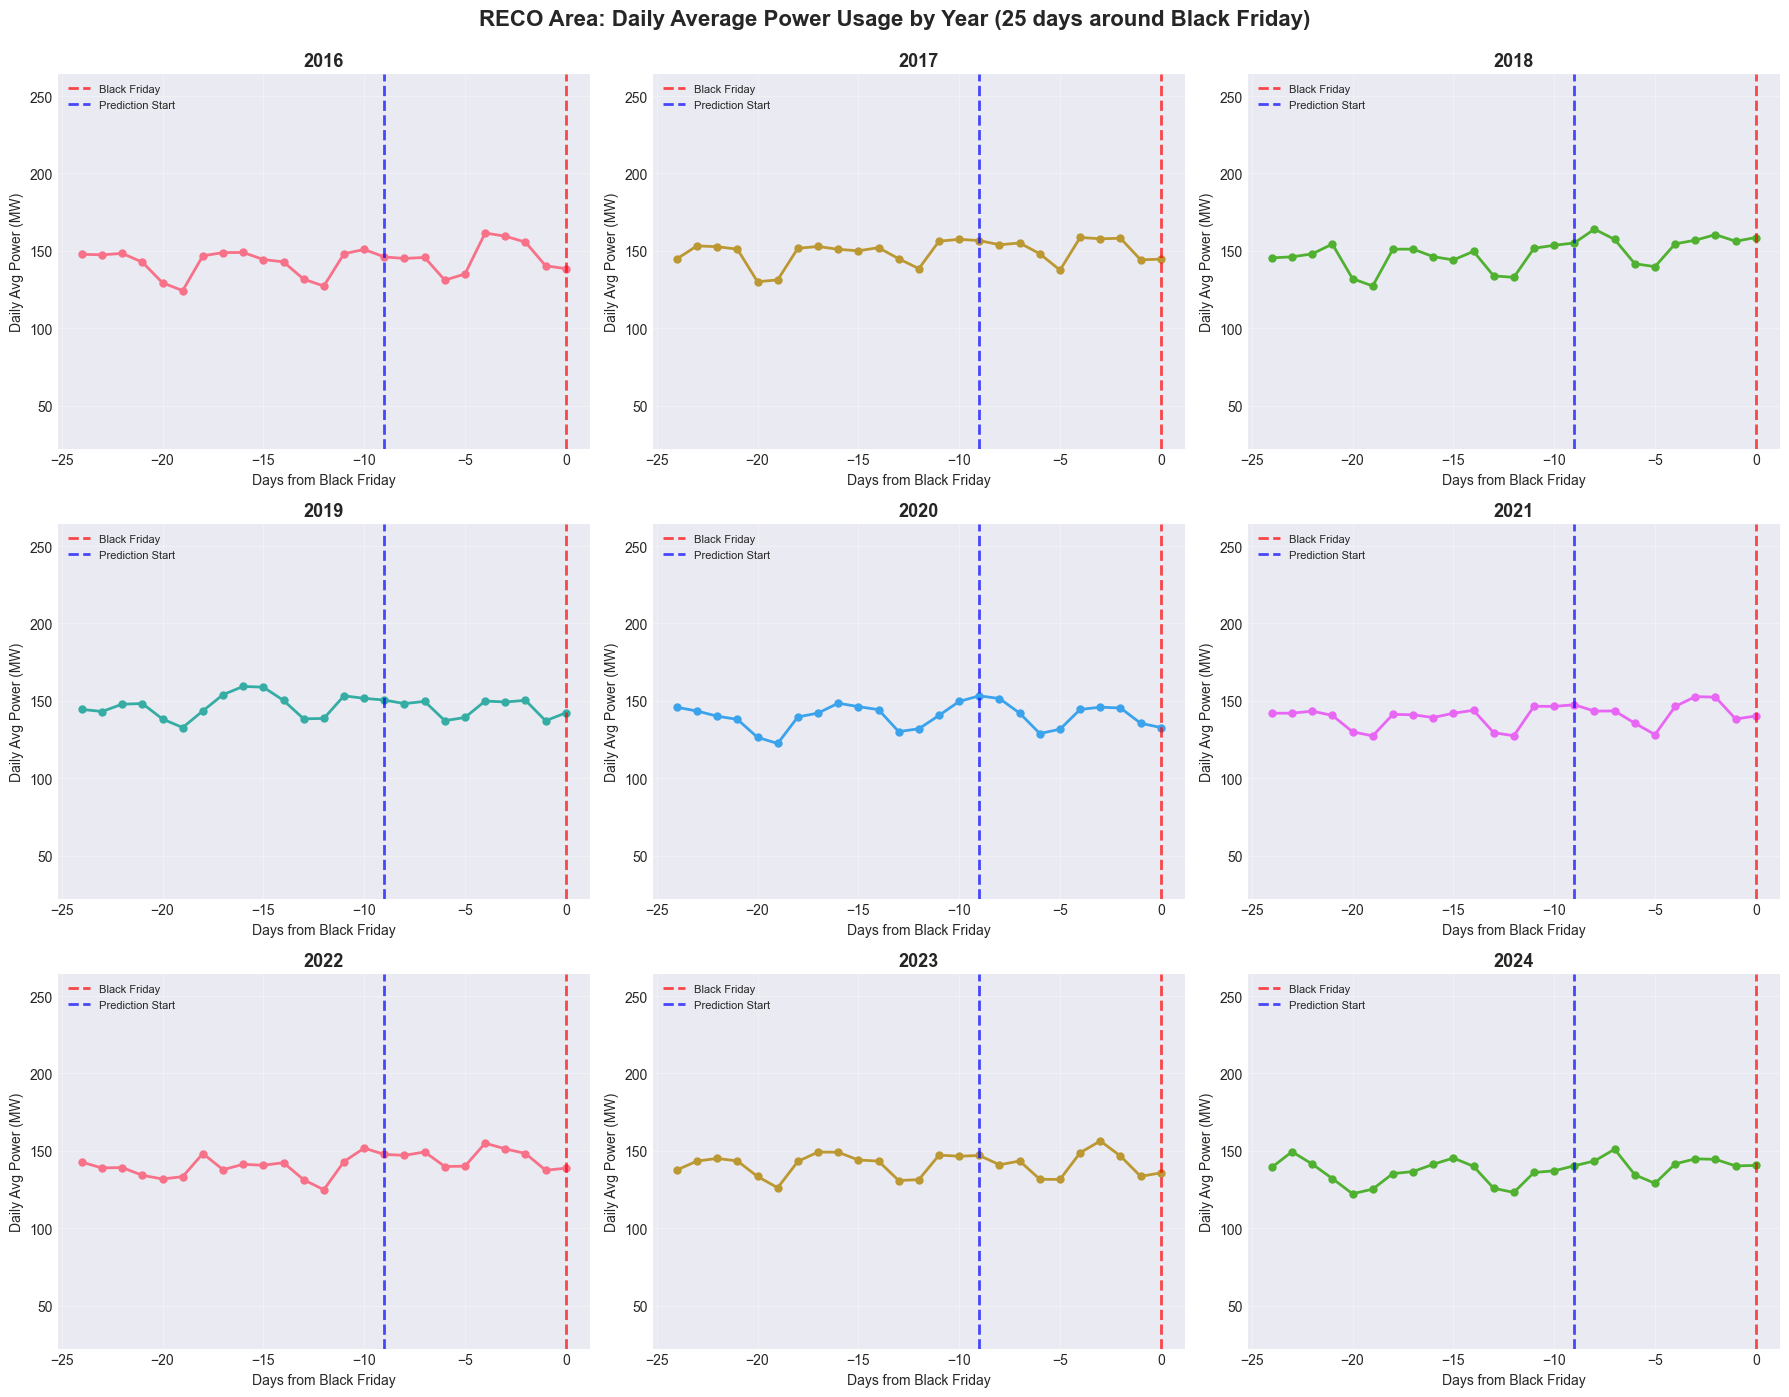


Total data for RECO: 5,406 rows

Data count by year:
year
2016    601
2017    601
2018    601
2019    600
2020    600
2021    601
2022    601
2023    601
2024    600
dtype: int64

Processing: RTO


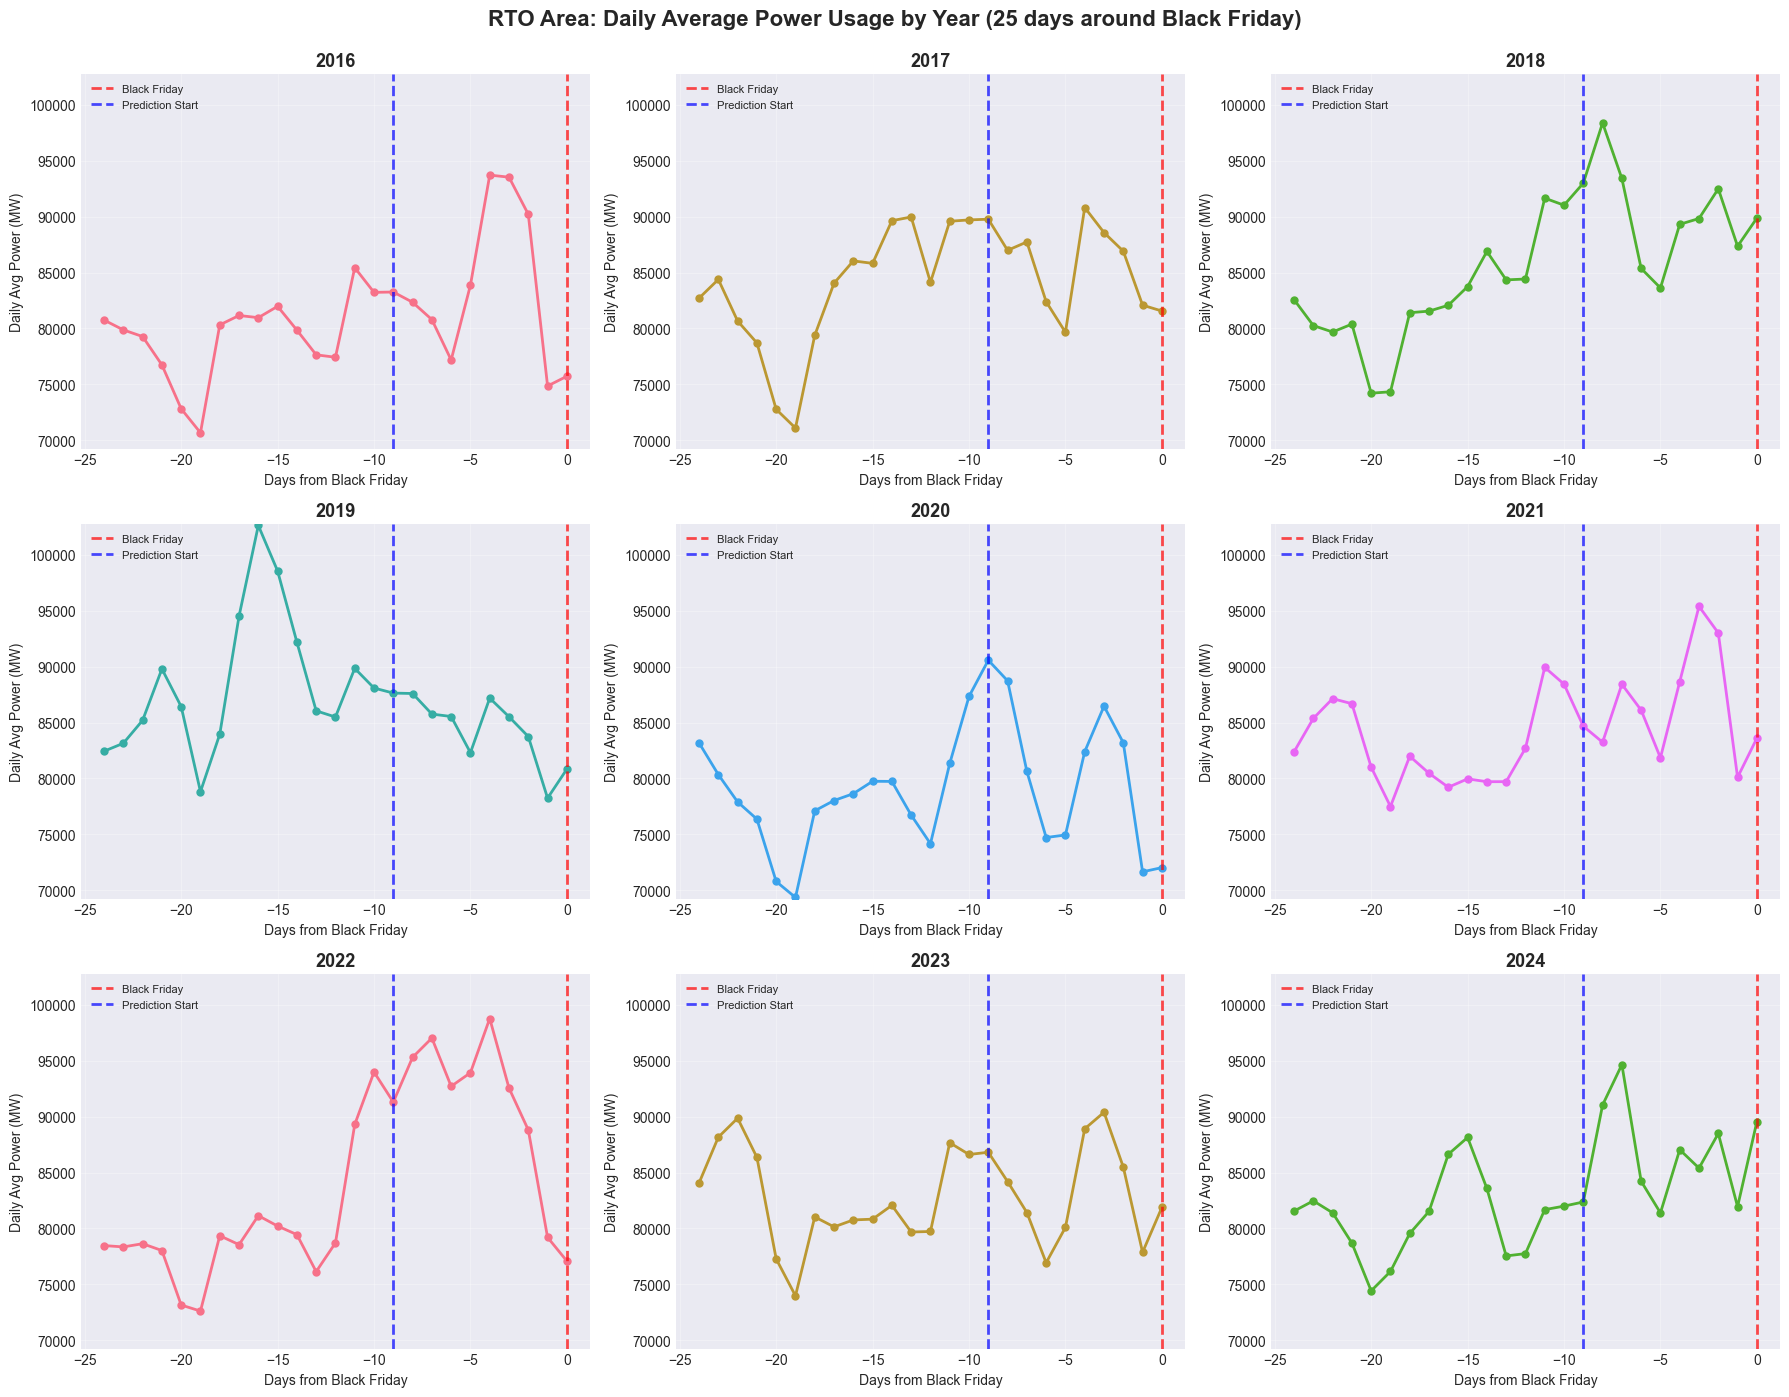


Total data for RTO: 5,406 rows

Data count by year:
year
2016    601
2017    601
2018    601
2019    600
2020    600
2021    601
2022    601
2023    601
2024    600
dtype: int64

Processing: SMECO


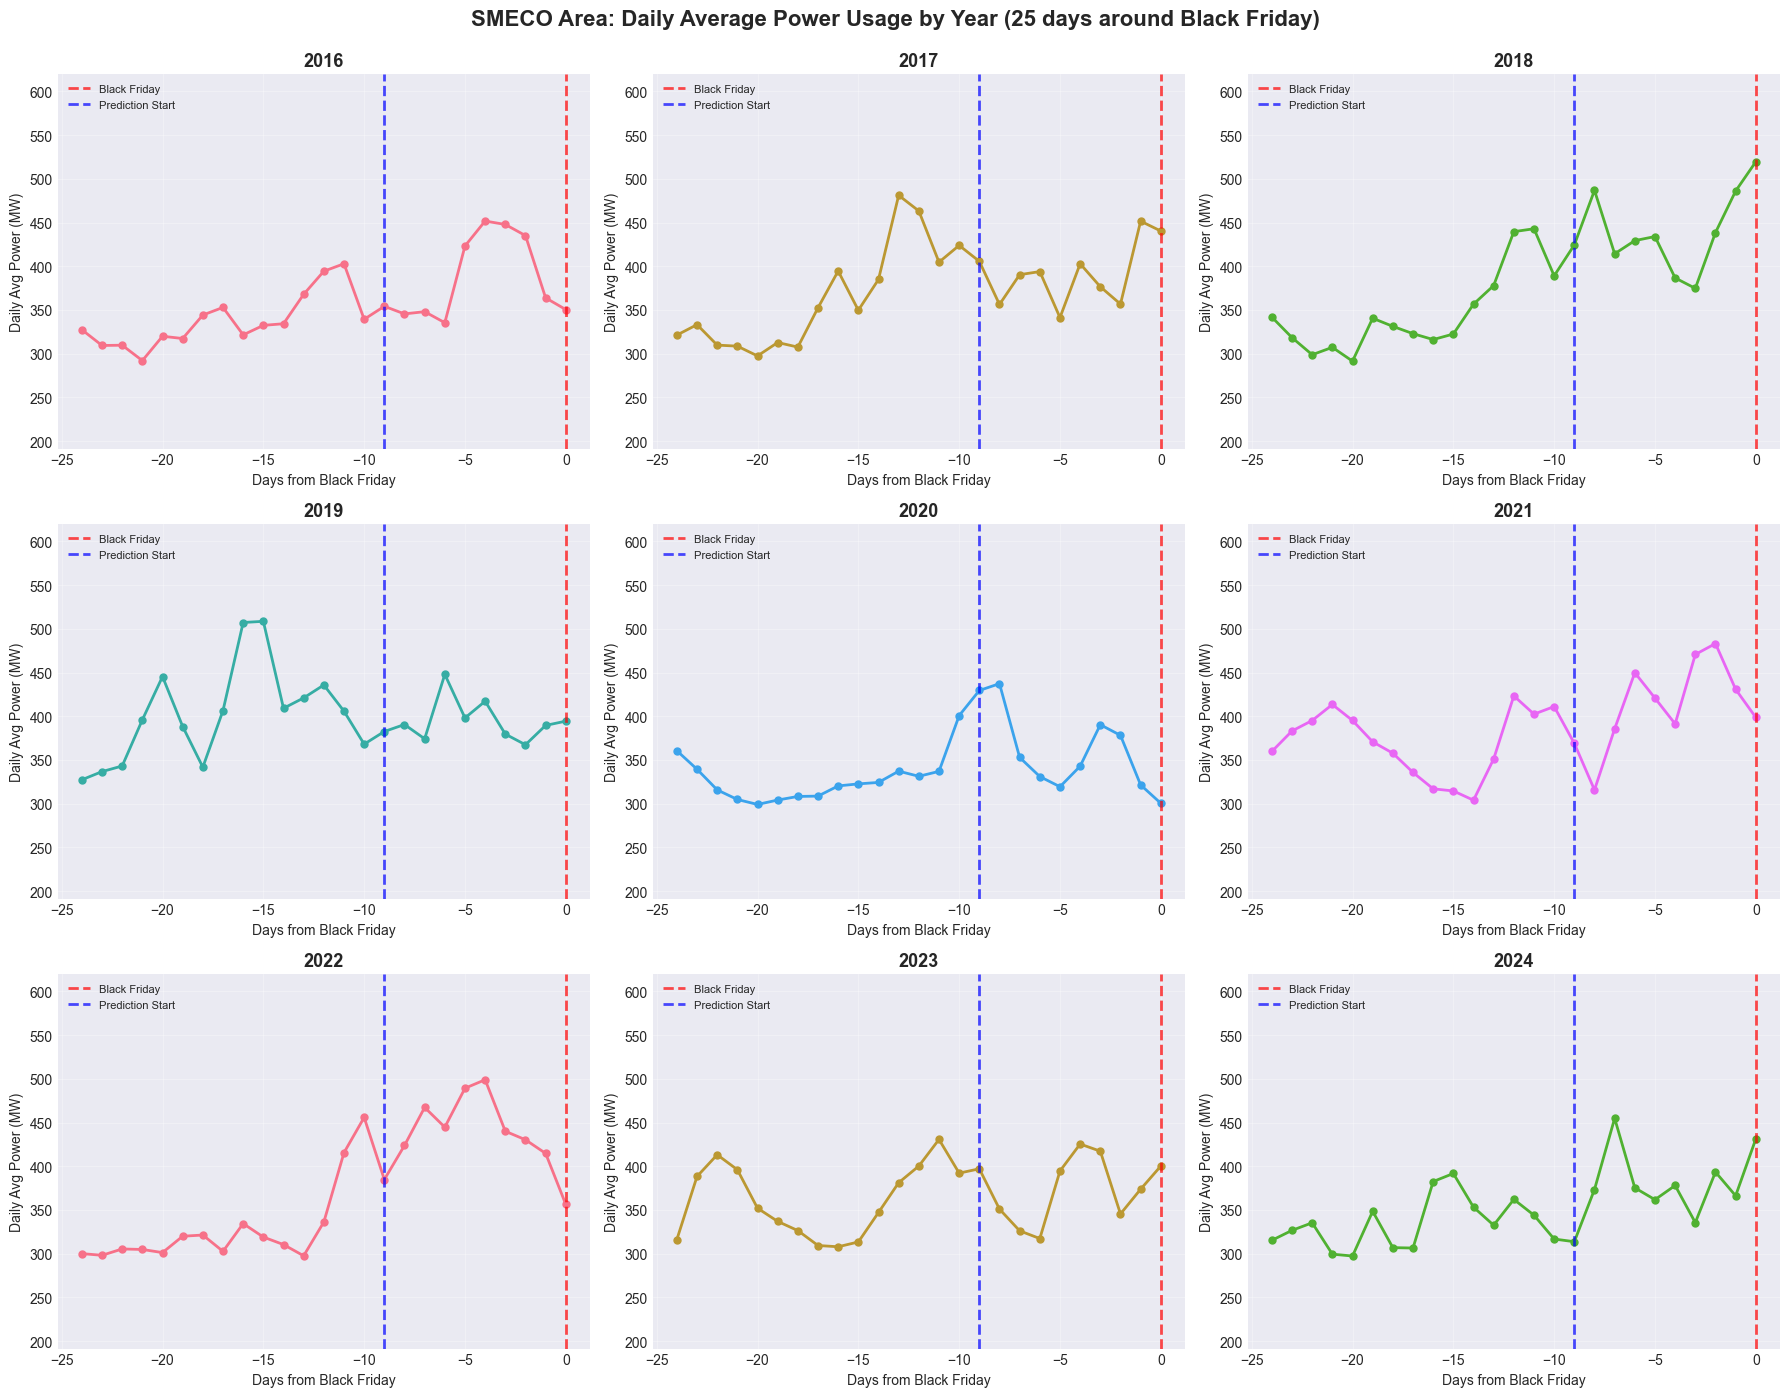


Total data for SMECO: 5,406 rows

Data count by year:
year
2016    601
2017    601
2018    601
2019    600
2020    600
2021    601
2022    601
2023    601
2024    600
dtype: int64

Processing: UGI


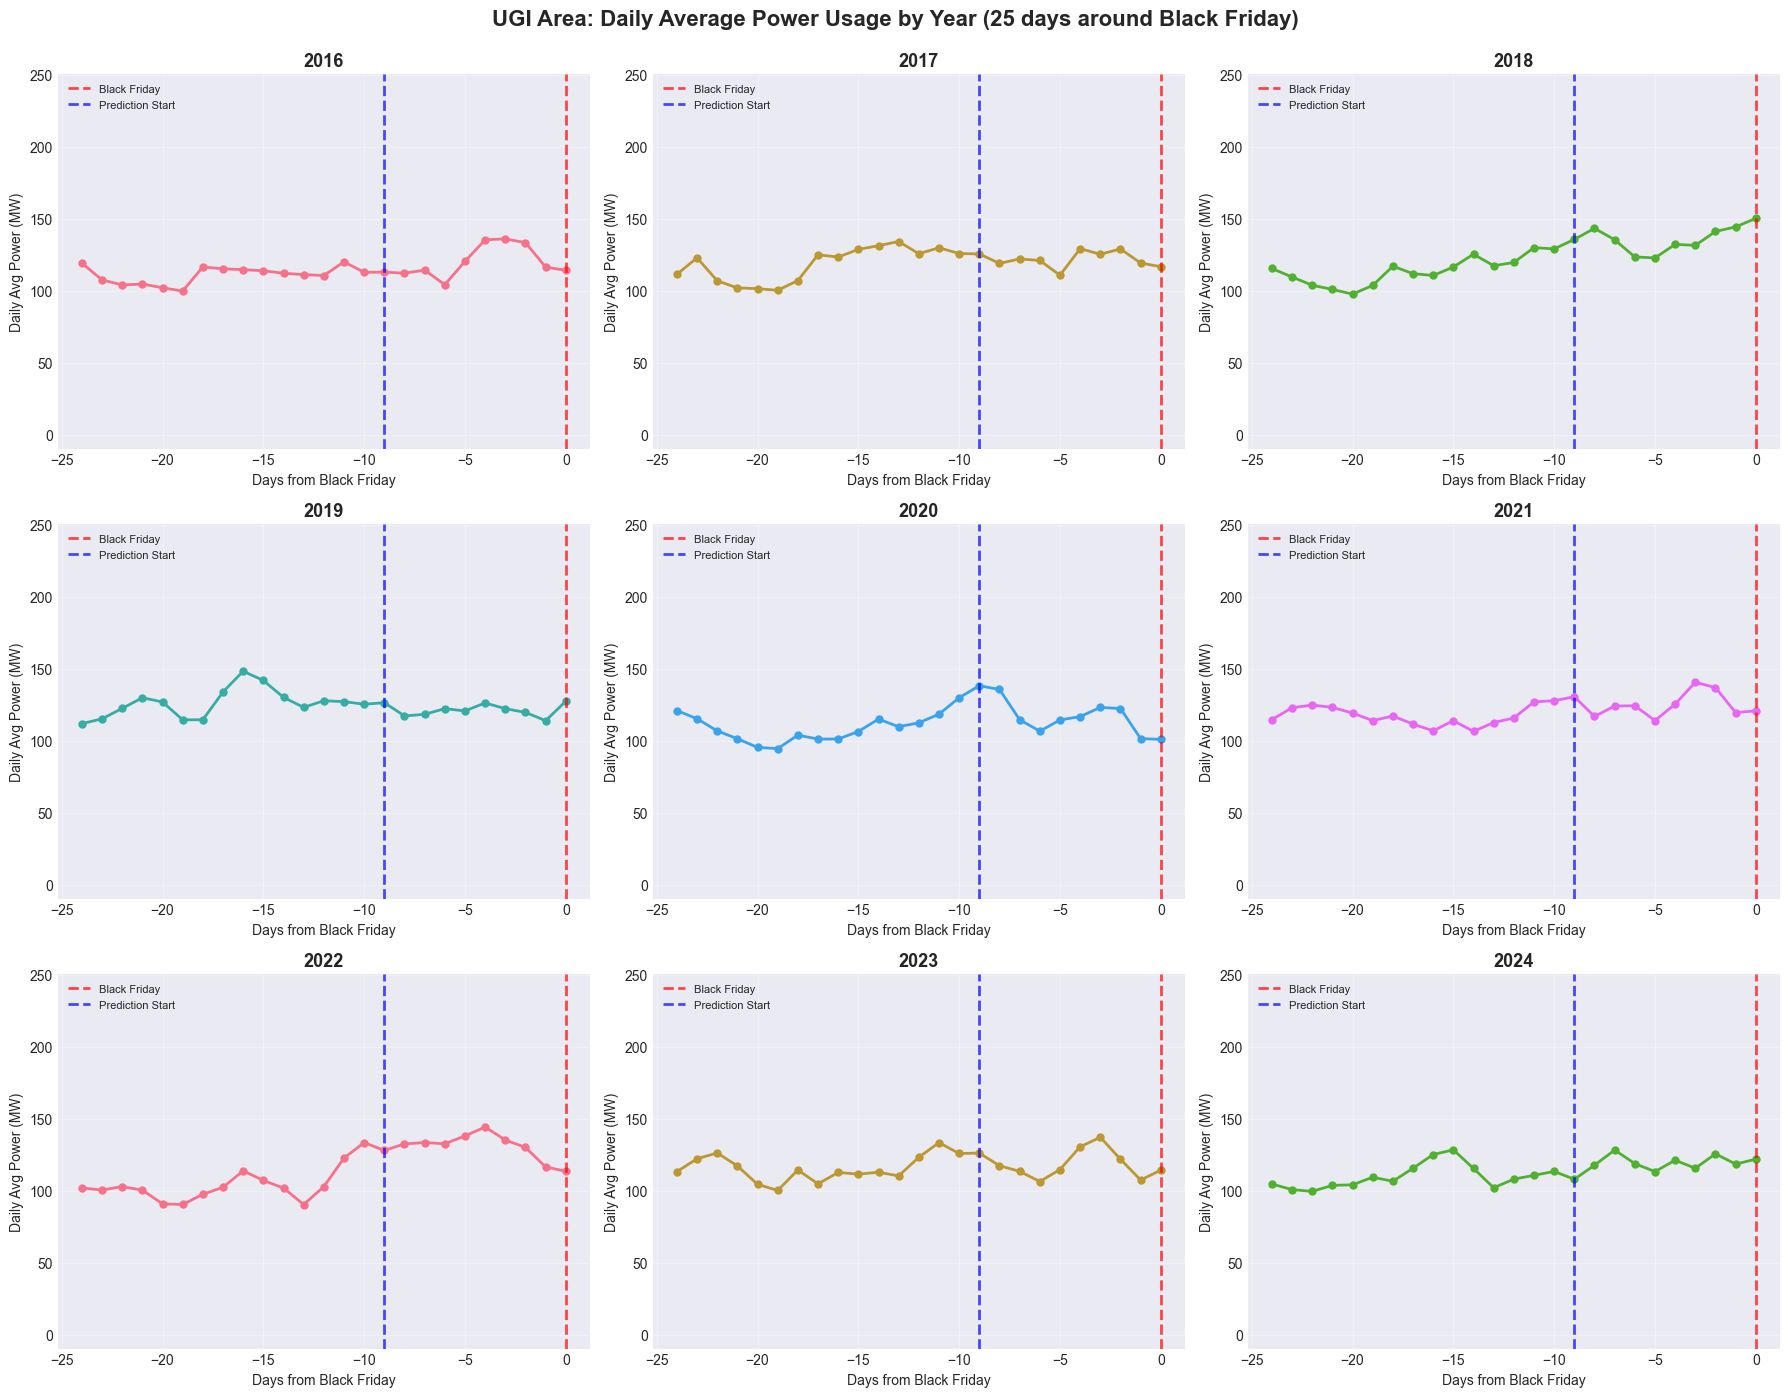


Total data for UGI: 5,406 rows

Data count by year:
year
2016    601
2017    601
2018    601
2019    600
2020    600
2021    601
2022    601
2023    601
2024    600
dtype: int64

Processing: VMEU


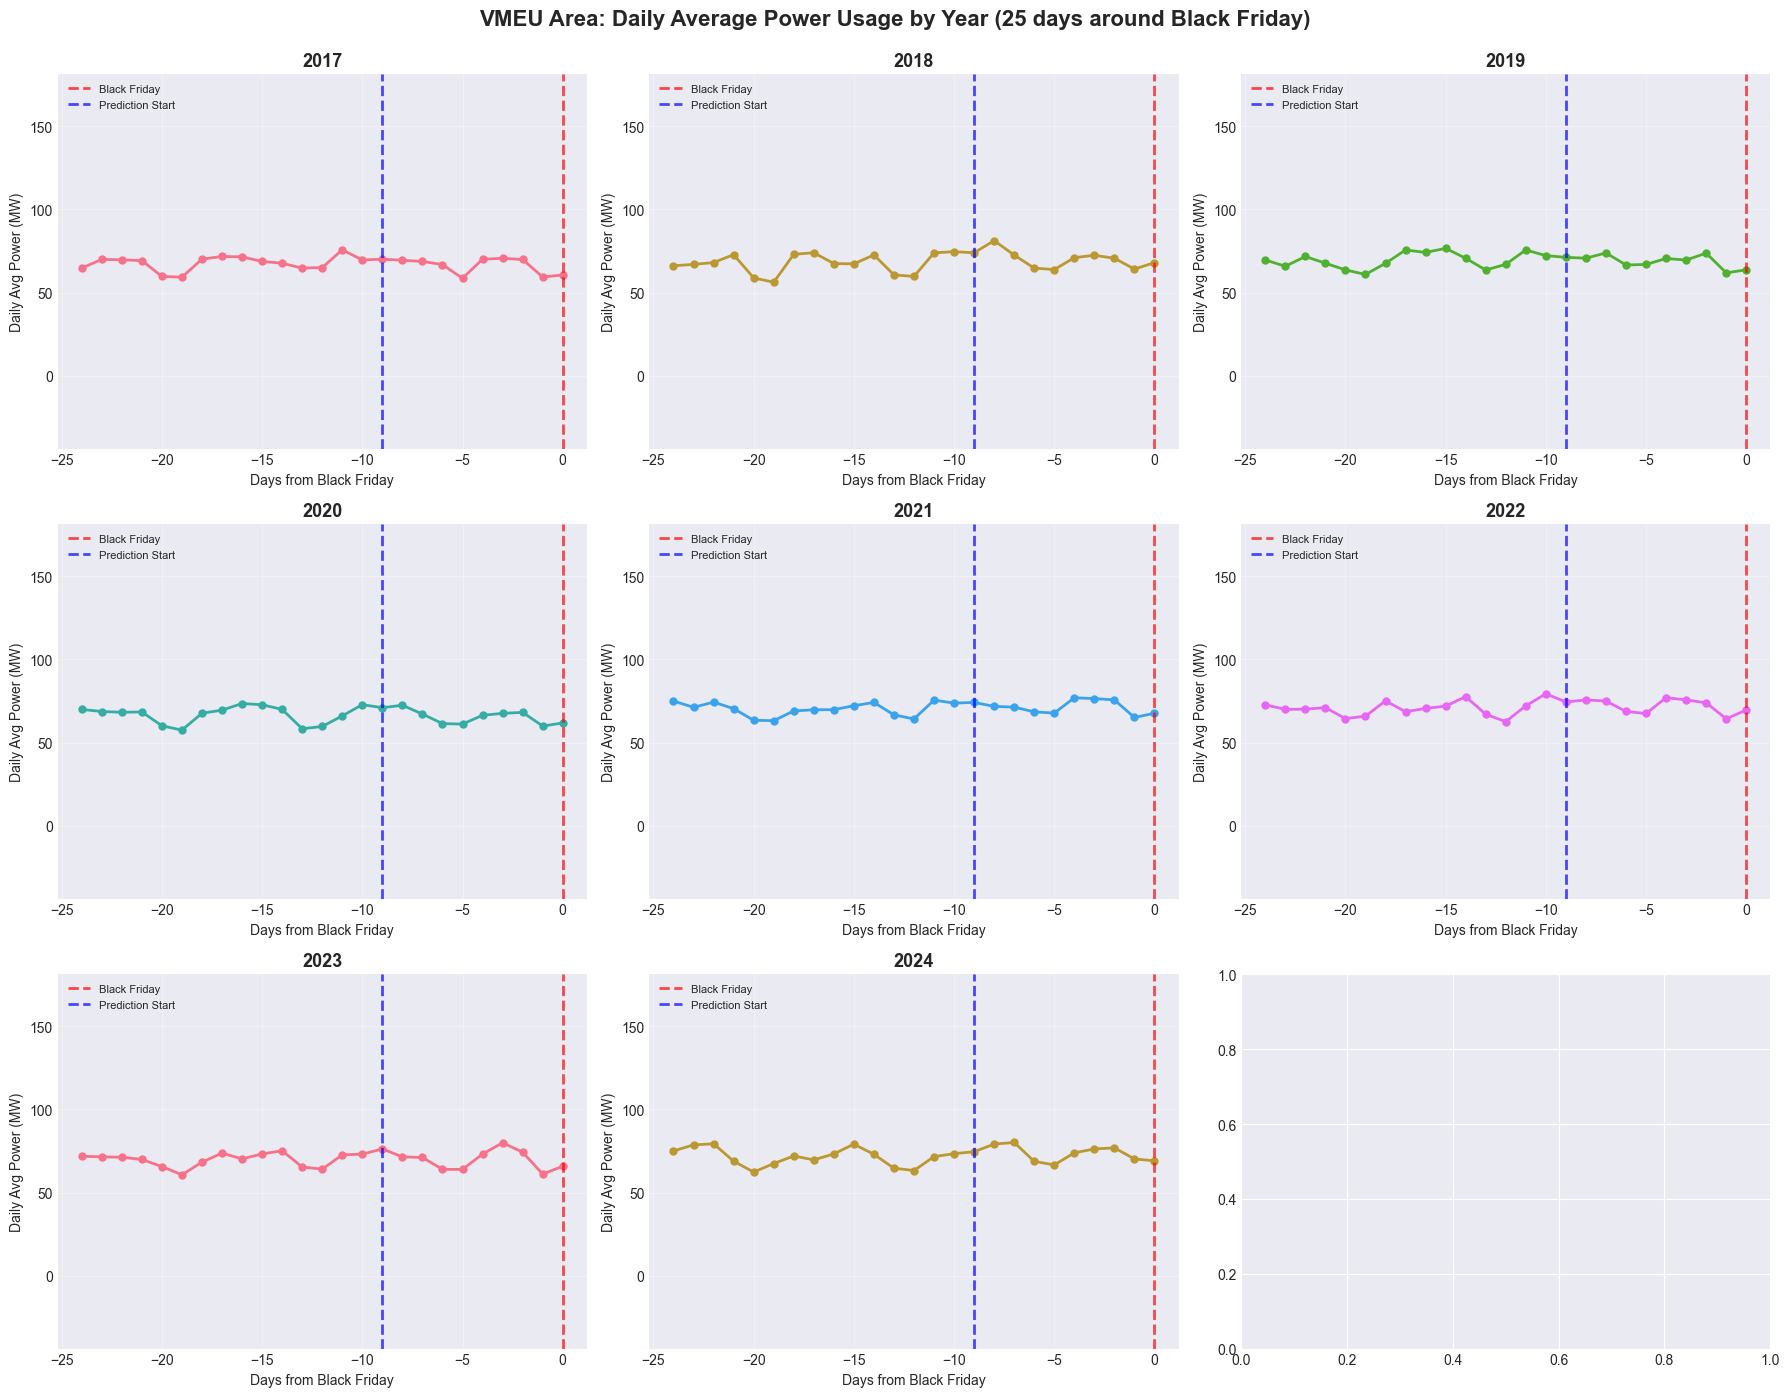


Total data for VMEU: 4,805 rows

Data count by year:
year
2017    601
2018    601
2019    600
2020    600
2021    601
2022    601
2023    601
2024    600
dtype: int64


In [56]:
# Generate plots for all load areas
# Warning: This will generate many plots!
for area in all_load_areas:
    print(f"\n{'='*80}")
    print(f"Processing: {area}")
    print(f"{'='*80}")
    plot_daily_avg_by_year(combined_df, area)